### Cell 1 — Imports + paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# Phase9G Final Figures Notebook
# Goal:
#   Reproduce Card17-style before/after profile figures
#   using final deployable Phase9G:
#       Phase9D-plus + prediction-based core scalar calibration
# ============================================================

import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PROJECT_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")

DATA_DIR = PROJECT_DIR / "data"
SPLIT_DIR = DATA_DIR / "splits"

CHECKPOINT_DIR = PROJECT_DIR / "outputs" / "checkpoints"
ANALYSIS_DIR = PROJECT_DIR / "analysis"

TRAIN_JSON = SPLIT_DIR / "train_pairs_3d.json"
VAL_JSON = SPLIT_DIR / "test_pairs_3d.json"

# ------------------------------------------------------------
# Please check these two checkpoint paths.
# BASE_CKPT should be the frozen base model used by Phase9D/9G.
# PHASE9D_PLUS_CKPT should be the final/best Phase9D-plus checkpoint.
# ------------------------------------------------------------

BASE_CKPT = CHECKPOINT_DIR / "ct2dose_phase5e_strong_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p02_sl0p01_best.pt"

PHASE9D_PLUS_CKPT = CHECKPOINT_DIR / "ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt"

PHASE9G_FINAL_DIR = ANALYSIS_DIR / "ct2dose_phase9g_deployable_core_calibration" / "final_card17_style_figures"
PHASE9G_FINAL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("VAL_JSON:", VAL_JSON)
print("BASE_CKPT exists:", BASE_CKPT.exists(), BASE_CKPT)
print("PHASE9D_PLUS_CKPT exists:", PHASE9D_PLUS_CKPT.exists(), PHASE9D_PLUS_CKPT)
print("Output dir:", PHASE9G_FINAL_DIR)

Device: cuda
PROJECT_DIR: /content/drive/MyDrive/rectified_flow_ct2dose
VAL_JSON: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json
BASE_CKPT exists: True /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase5e_strong_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p02_sl0p01_best.pt
PHASE9D_PLUS_CKPT exists: True /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt
Output dir: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures


### Cell 2 — Config

In [ ]:
# ============================================================
# Final Phase9G settings
# ============================================================

CONFIG = {
    "seed": 42,
    "batch_size": 2,
    "num_workers": 2,

    # Euler sampling steps for base model
    "euler_steps": 30,

    # Phase9G deployable core calibration
    "core_scale": 0.990,
    "core_thr": 0.70,
    "tau": 0.04,

    # Professor/Card17-style percentage error threshold
    "threshold_frac": 0.01,

    # Evaluation amount
    # Use 300 if you want same as earlier professor-style eval.
    "max_eval_batches": 300,

    # Figure samples
    "num_auto_examples": 20,
}

print(json.dumps(CONFIG, indent=2))

{
  "seed": 42,
  "batch_size": 2,
  "num_workers": 2,
  "euler_steps": 30,
  "core_scale": 0.99,
  "core_thr": 0.7,
  "tau": 0.04,
  "threshold_frac": 0.01,
  "max_eval_batches": 300,
  "num_auto_examples": 20
}


### Cell 3 — Dataset

In [ ]:
# ============================================================
# Load dose scale from base checkpoint config
# ============================================================

base_ckpt_raw = torch.load(BASE_CKPT, map_location="cpu")

DOSE_SCALE = float(
    base_ckpt_raw.get("config", {}).get("dose_scale", 1000.0)
)

print("DOSE_SCALE =", DOSE_SCALE)

DOSE_SCALE = 1000.0


In [ ]:
# ============================================================
# Dataset with CT normalization + dose scaling
# ============================================================

class CTDoseNpyDataset(Dataset):
    def __init__(self, json_path, dose_scale=1000.0):
        self.json_path = Path(json_path)
        self.dose_scale = float(dose_scale)

        with open(self.json_path, "r") as f:
            self.records = json.load(f)

        print(f"Loaded {len(self.records)} records from {self.json_path}")
        print("Dataset dose_scale:", self.dose_scale)

    def __len__(self):
        return len(self.records)

    def normalize_ct(self, ct):
        """
        Match the previous training/evaluation CT scale.

        If CT is raw HU, roughly [-1000, 1000], convert to [0, 1]:
            ct_norm = clip((ct + 1024) / 2048, 0, 1)

        If CT is already normalized, keep it unchanged.
        """
        ct = ct.astype(np.float32)

        if ct.min() < -10 or ct.max() > 10:
            ct = (ct + 1024.0) / 2048.0
            ct = np.clip(ct, 0.0, 1.0)

        return ct.astype(np.float32)

    def scale_dose_if_needed(self, dose):
        """
        Match model dose scale.

        Raw stored dose may be around 0.003.
        Training/evaluation dose is around 3.0.
        """
        dose = dose.astype(np.float32)

        if dose.max() < 0.1:
            dose = dose * self.dose_scale

        return dose.astype(np.float32)

    def __getitem__(self, idx):
        rec = self.records[idx]

        ct = np.load(rec["input_path"]).astype(np.float32)
        dose = np.load(rec["output_path"]).astype(np.float32)

        ct = self.normalize_ct(ct)
        dose = self.scale_dose_if_needed(dose)

        if ct.ndim == 3:
            ct = ct[None, ...]
        if dose.ndim == 3:
            dose = dose[None, ...]

        return {
            "ct": torch.from_numpy(ct),
            "dose": torch.from_numpy(dose),
            "case_id": rec.get("case_id", "unknown"),
            "input_path": rec["input_path"],
            "output_path": rec["output_path"],
        }


val_ds = CTDoseNpyDataset(VAL_JSON, dose_scale=DOSE_SCALE)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

batch = next(iter(val_loader))
print("ct:", batch["ct"].shape, batch["ct"].min().item(), batch["ct"].max().item(), batch["ct"].mean().item())
print("dose:", batch["dose"].shape, batch["dose"].min().item(), batch["dose"].max().item(), batch["dose"].mean().item())

Loaded 4000 records from /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json
Dataset dose_scale: 1000.0
ct: torch.Size([2, 1, 32, 32, 32]) 0.0028893351554870605 0.976665735244751 0.31629809737205505
dose: torch.Size([2, 1, 32, 32, 32]) 0.00043892604298889637 3.542872190475464 0.04636553302407265


### Cell 4 — Base model definition

In [ ]:
# ============================================================
# Base rectified-flow model definition
# Must match the training notebook architecture.
# ============================================================

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    """
    Rectified-flow velocity model:
        v_theta(xt, x0, t)

    Input channels:
        xt: current noisy/interpolated dose
        x0: CT
        t_map: scalar time expanded to volume
    """
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        # IMPORTANT: checkpoint uses the name out_conv
        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # t can be [B], [B,1], or [B,1,1,1,1]
        if t.ndim == 1:
            t = t.view(-1, 1, 1, 1, 1)
        elif t.ndim == 2:
            t = t.view(-1, 1, 1, 1, 1)

        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


### Cell 5 — Phase9D-plus model definition

In [ ]:
# ============================================================
# Phase9D-plus / Phase9G refinement head
# Must match the successful Phase9D-plus checkpoint.
# make_structure_features() is defined in the next code cell.
# ============================================================

class MultiplicativeAdditiveRefineHead3D(nn.Module):
    def __init__(
        self,
        in_ch=7,
        base_ch=16,
        log_scale_bound=0.15,
        additive_scale=0.015,
    ):
        super().__init__()

        self.log_scale_bound = float(log_scale_bound)
        self.additive_scale = float(additive_scale)

        self.trunk = nn.Sequential(
            nn.Conv3d(in_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.log_scale_head = nn.Conv3d(base_ch, 1, kernel_size=1)
        self.additive_head = nn.Conv3d(base_ch, 1, kernel_size=1)

    def forward(self, ct, base_pred):
        feat = make_structure_features(ct, base_pred)
        h = self.trunk(feat)

        log_scale = self.log_scale_bound * torch.tanh(self.log_scale_head(h))
        additive = self.additive_scale * torch.tanh(self.additive_head(h))

        refined = base_pred * torch.exp(log_scale) + additive
        refined = torch.clamp(refined, min=0.0)

        return refined, {
            "log_scale": log_scale,
            "additive": additive,
        }


### Cell 6 — Checkpoint loading helpers

In [ ]:
def spatial_gradient_magnitude_3d(x):
    """
    x: [B,1,D,H,W]
    return: [B,1,D,H,W]
    """
    dz = torch.zeros_like(x)
    dy = torch.zeros_like(x)
    dx = torch.zeros_like(x)

    dz[:, :, 1:, :, :] = x[:, :, 1:, :, :] - x[:, :, :-1, :, :]
    dy[:, :, :, 1:, :] = x[:, :, :, 1:, :] - x[:, :, :, :-1, :]
    dx[:, :, :, :, 1:] = x[:, :, :, :, 1:] - x[:, :, :, :, :-1]

    grad = torch.sqrt(dx * dx + dy * dy + dz * dz + 1e-8)
    return grad


def make_structure_features(ct, base_pred):
    """
    All features are deployable:
    only use CT and base prediction, not GT.

    returns feature tensor [B, 7, D, H, W]
    """
    peak = torch.amax(base_pred, dim=(2, 3, 4), keepdim=True).clamp_min(1e-8)
    rel = base_pred / peak

    core = torch.sigmoid((rel - 0.70) / 0.05)
    shoulder = torch.sigmoid((rel - 0.25) / 0.05) * (1.0 - torch.sigmoid((rel - 0.70) / 0.05))
    tail = torch.sigmoid((0.25 - rel) / 0.05)

    grad = spatial_gradient_magnitude_3d(base_pred)
    grad_norm = grad / (torch.amax(grad, dim=(2, 3, 4), keepdim=True).clamp_min(1e-8))

    features = torch.cat(
        [
            ct,
            base_pred,
            rel,
            core,
            shoulder,
            tail,
            grad_norm,
        ],
        dim=1,
    )

    return features

In [ ]:

# ============================================================
# Checkpoint loading
# ============================================================

def load_state_dict_flexible(model, ckpt_path, device, strict_final=False):
    ckpt_path = Path(ckpt_path)
    print("Loading:", ckpt_path)

    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict):
        print("Checkpoint keys:", list(ckpt.keys())[:20])

        if "model_state_dict" in ckpt:
            state = ckpt["model_state_dict"]
        elif "state_dict" in ckpt:
            state = ckpt["state_dict"]
        elif "model" in ckpt:
            state = ckpt["model"]
        else:
            state = ckpt
    else:
        state = ckpt

    model_keys = set(model.state_dict().keys())

    new_state = {}
    for k, v in state.items():
        nk = k.replace("module.", "")

        # Handle base model output layer naming mismatch:
        # checkpoint: out_conv.*
        # current model: out.*
        if nk.startswith("out_conv.") and nk.replace("out_conv.", "out.") in model_keys:
            nk = nk.replace("out_conv.", "out.")

        # Handle opposite case:
        # checkpoint: out.*
        # current model: out_conv.*
        if nk.startswith("out.") and nk.replace("out.", "out_conv.") in model_keys:
            nk = nk.replace("out.", "out_conv.")

        new_state[nk] = v

    missing, unexpected = model.load_state_dict(new_state, strict=False)

    print("Missing keys:", missing[:20], "..." if len(missing) > 20 else "")
    print("Unexpected keys:", unexpected[:20], "..." if len(unexpected) > 20 else "")

    if len(missing) > 0 or len(unexpected) > 0:
        print()
        print("WARNING: Missing/unexpected keys found.")
        print("If many keys appear, the model definition does not match the checkpoint.")

    if strict_final and (len(missing) > 0 or len(unexpected) > 0):
        raise RuntimeError(
            f"Checkpoint loading is not clean.\n"
            f"Missing keys: {missing}\n"
            f"Unexpected keys: {unexpected}"
        )

    return ckpt


# ------------------------------------------------------------
# Load frozen rectified-flow base model.
# IMPORTANT: ConditionalUNetFlow3D must use self.out_conv, because
# the Phase5E checkpoint stores the final layer as out_conv.*
# ------------------------------------------------------------
base_model = ConditionalUNetFlow3D(
    in_ch=3,
    out_ch=1,
    base_ch=24,
).to(device)

base_ckpt = load_state_dict_flexible(

    base_model,

    BASE_CKPT,

    device,

    strict_final=True,

)
base_model.eval()


# ------------------------------------------------------------
# Load Phase9D-plus refinement head.
# IMPORTANT: this class uses make_structure_features(), which returns
# 7 channels. Therefore in_ch must be 7.
# ------------------------------------------------------------
model_9d_plus = MultiplicativeAdditiveRefineHead3D(
    in_ch=7,
    base_ch=16,
    log_scale_bound=0.15,
    additive_scale=0.015,
).to(device)

phase9d_ckpt = load_state_dict_flexible(

    model_9d_plus,

    PHASE9D_PLUS_CKPT,

    device,

    strict_final=True,

)
model_9d_plus.eval()

print("Models loaded.")

# Optional: inspect checkpoint metadata if present.
for name, ckpt in [("base", base_ckpt), ("phase9d_plus", phase9d_ckpt)]:
    if isinstance(ckpt, dict):
        print(f"\n{name} checkpoint metadata:")
        for key in ["epoch", "best_epoch", "best_score", "val_loss", "config"]:
            if key in ckpt:
                val = ckpt[key]
                if key == "config":
                    print("config keys:", list(val.keys())[:20] if isinstance(val, dict) else type(val))
                else:
                    print(key, ":", val)



Loading: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase5e_strong_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p02_sl0p01_best.pt
Checkpoint keys: ['model_state_dict', 'optimizer_state_dict', 'config', 'epoch', 'val_loss']
Missing keys: [] 
Unexpected keys: [] 
Loading: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt
Checkpoint keys: ['model_state_dict', 'base_checkpoint', 'phase9d_plus_config', 'epoch', 'row', 'best_score']
Missing keys: [] 
Unexpected keys: [] 
Models loaded.

base checkpoint metadata:
epoch : 2
val_loss : 2.2047049596949365e-05
config keys: ['phase', 'seed', 'epochs', 'lr', 'base_ch', 'batch_size', 'num_workers', 'dose_scale', 'threshold', 'threshold_mode', 'alpha', 'beta', 'gamma_profile', 'max_dose_weight', 'shoulder_low', 'shoulder_high', 'soft_tau_frac', 'profile_main_low', 'falloff_low_frac', 'falloff_high_frac']

phase9d_plus checkpoint metadata:
epoch 

### Cell 7 — Euler sampling

In [ ]:
# ============================================================
# Euler sampler for rectified-flow base model
# ============================================================

# ============================================================
# Correct Euler sampler for CT -> dose rectified flow
# ============================================================

@torch.no_grad()
def euler_sample_ct2dose(model, ct, steps=10):
    """
    Correct sampler for this CT-to-dose rectified-flow model.

    Training convention is effectively:
        x_t = (1 - t) * CT + t * dose

    Therefore inference should start from CT, not from zero:
        x_0 = CT
        x_{t+dt} = x_t + dt * v_theta(x_t, CT, t)

    Midpoint time t=(i+0.5)/steps gave the best sanity-check result.
    """
    model.eval()

    # IMPORTANT: start from CT, not zeros
    x = ct.clone()

    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full(
            (ct.shape[0],),
            (i + 0.5) / steps,
            device=ct.device,
            dtype=ct.dtype,
        )

        v = model(x, ct, t)
        x = x + dt * v
        x = torch.clamp(x, min=0.0)

    return x

In [ ]:
# ============================================================
# Add train_loader for Phase10C
# ============================================================

train_ds = CTDoseNpyDataset(TRAIN_JSON, dose_scale=DOSE_SCALE)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

batch = next(iter(train_loader))
print("train ct:", batch["ct"].shape, batch["ct"].min().item(), batch["ct"].max().item(), batch["ct"].mean().item())
print("train dose:", batch["dose"].shape, batch["dose"].min().item(), batch["dose"].max().item(), batch["dose"].mean().item())

Loaded 16000 records from /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
Dataset dose_scale: 1000.0
Train samples: 16000
Val samples: 4000
train ct: torch.Size([2, 1, 32, 32, 32]) 0.008441507816314697 1.0 0.405169278383255
train dose: torch.Size([2, 1, 32, 32, 32]) 0.0005479747778736055 4.030111789703369 0.046835221350193024


### Cell 8 — Phase9G deployable calibration

In [ ]:
# ============================================================
# Phase9G deployable core-only scalar calibration
# Does not use GT during inference.
# ============================================================

def apply_core_scalar_calibration_deployable(
    pred,
    core_scale=0.990,
    core_thr=0.70,
    tau=0.04,
):
    """
    pred: [B,1,D,H,W]

    core mask is computed from pred itself:
        rel = pred / pred.max()

    final = pred * (1 + core_mask * (core_scale - 1))
    """
    peak = torch.amax(pred, dim=(2, 3, 4), keepdim=True).clamp_min(1e-8)
    rel = pred / peak

    core_mask = torch.sigmoid((rel - core_thr) / tau)
    scale_field = 1.0 + core_mask * (core_scale - 1.0)

    calibrated = pred * scale_field
    calibrated = torch.clamp(calibrated, min=0.0)

    aux = {
        "core_mask_mean": float(core_mask.mean().detach().cpu()),
        "core_mask_max": float(core_mask.max().detach().cpu()),
        "scale_field_min": float(scale_field.min().detach().cpu()),
        "scale_field_max": float(scale_field.max().detach().cpu()),
    }

    return calibrated, aux


@torch.no_grad()
def predict_phase9g(ct, steps=30):
    base_pred = euler_sample_ct2dose(base_model, ct, steps=steps)

    phase9d_pred, phase9d_aux = model_9d_plus(ct, base_pred)

    phase9g_pred, phase9g_aux = apply_core_scalar_calibration_deployable(
        phase9d_pred,
        core_scale=CONFIG["core_scale"],
        core_thr=CONFIG["core_thr"],
        tau=CONFIG["tau"],
    )

    return {
        "base_pred": base_pred,
        "phase9d_pred": phase9d_pred,
        "phase9g_pred": phase9g_pred,
        "phase9d_aux": phase9d_aux,
        "phase9g_aux": phase9g_aux,
    }

### Cell 9 — Profile extraction + metrics

In [ ]:
# ============================================================
# Profile extraction and metrics
# ============================================================

def to_numpy_3d(x):
    """
    Convert [1,D,H,W] or [D,H,W] tensor to numpy [D,H,W].
    """
    if torch.is_tensor(x):
        x = x.detach().cpu().float().numpy()

    x = np.asarray(x)

    if x.ndim == 4:
        x = x[0]

    return x


def extract_axis_profiles(pred_tensor, gt_tensor):
    """
    Extract central line profiles along x/y/z through GT peak.

    pred_tensor, gt_tensor:
        [1,D,H,W] tensors

    Returns:
        dict with axis -> {"pred": profile, "gt": profile}
    """
    pred = to_numpy_3d(pred_tensor)
    gt = to_numpy_3d(gt_tensor)

    # shape [D,H,W]
    peak_idx = np.unravel_index(np.argmax(gt), gt.shape)
    zc, yc, xc = peak_idx

    profiles = {
        "x": {
            "pred": pred[zc, yc, :],
            "gt": gt[zc, yc, :],
        },
        "y": {
            "pred": pred[zc, :, xc],
            "gt": gt[zc, :, xc],
        },
        "z": {
            "pred": pred[:, yc, xc],
            "gt": gt[:, yc, xc],
        },
    }

    return profiles


def percentage_error_curve(pred_profile, gt_profile, eps=1e-8, threshold_frac=0.01):
    pred = np.asarray(pred_profile).astype(np.float64)
    gt = np.asarray(gt_profile).astype(np.float64)

    gt_peak = max(float(np.max(gt)), eps)
    valid = gt >= threshold_frac * gt_peak

    pct = np.full_like(gt, np.nan, dtype=np.float64)
    pct[valid] = 100.0 * np.abs(pred[valid] - gt[valid]) / (np.abs(gt[valid]) + eps)

    mean_pct = float(np.nanmean(pct))
    max_pct = float(np.nanmax(pct))
    valid_count = int(np.sum(valid))
    threshold = gt_peak * threshold_frac

    return pct, mean_pct, max_pct, valid_count, threshold


def profile_error_metrics_np(pred_profile, gt_profile, threshold_frac=0.01):
    """
    Simple professor-style profile metric:
    valid = gt >= threshold_frac * gt_peak
    """
    pct, mean_pct, max_pct, valid_count, threshold = percentage_error_curve(
        pred_profile,
        gt_profile,
        threshold_frac=threshold_frac,
    )

    abs_err = np.abs(np.asarray(pred_profile) - np.asarray(gt_profile))
    gt = np.asarray(gt_profile)
    gt_peak = max(float(np.max(gt)), 1e-8)
    valid = gt >= threshold_frac * gt_peak

    mean_abs = float(np.mean(abs_err[valid])) if np.sum(valid) > 0 else np.nan

    return {
        "mean_pct": mean_pct,
        "max_pct": max_pct,
        "mean_abs": mean_abs,
        "valid_count": valid_count,
        "threshold": threshold,
    }

In [ ]:
# ============================================================
# Quick sanity check on one batch
# ============================================================
batch = next(iter(val_loader))
ct = batch["ct"].to(device)
gt = batch["dose"].to(device)

with torch.no_grad():
    preds = predict_phase9g(ct, steps=CONFIG["euler_steps"])

print("CONFIG euler_steps:", CONFIG["euler_steps"])

print("ct range:")
print(ct.min().item(), ct.max().item(), ct.mean().item())

print("gt range:")
print(gt.min().item(), gt.max().item(), gt.mean().item())

print("base_pred range:")
print(
    preds["base_pred"].min().item(),
    preds["base_pred"].max().item(),
    preds["base_pred"].mean().item(),
)

print("phase9d_pred range:")
print(
    preds["phase9d_pred"].min().item(),
    preds["phase9d_pred"].max().item(),
    preds["phase9d_pred"].mean().item(),
)

print("phase9g_pred range:")
print(
    preds["phase9g_pred"].min().item(),
    preds["phase9g_pred"].max().item(),
    preds["phase9g_pred"].mean().item(),
)

CONFIG euler_steps: 30
ct range:
0.0028893351554870605 0.976665735244751 0.31629809737205505
gt range:
0.00043892604298889637 3.542872190475464 0.04636553302407265
base_pred range:
0.0 4.157472133636475 0.04613787308335304
phase9d_pred range:
0.0 3.7643799781799316 0.04781623184680939
phase9g_pred range:
0.0 3.726757049560547 0.04781461879611015


In [ ]:
# ============================================================
# Inspect Phase9D-plus checkpoint metadata
# ============================================================

ckpt9d = torch.load(PHASE9D_PLUS_CKPT, map_location="cpu")

print("PHASE9D_PLUS_CKPT:")
print(PHASE9D_PLUS_CKPT)

print("\nKeys:")
print(ckpt9d.keys())

print("\nRecorded base_checkpoint:")
print(ckpt9d.get("base_checkpoint", None))

print("\nPhase9D-plus config:")
print(ckpt9d.get("phase9d_plus_config", None))

print("\nBest epoch:")
print(ckpt9d.get("epoch", None))

print("\nBest score:")
print(ckpt9d.get("best_score", None))

PHASE9D_PLUS_CKPT:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt

Keys:
dict_keys(['model_state_dict', 'base_checkpoint', 'phase9d_plus_config', 'epoch', 'row', 'best_score'])

Recorded base_checkpoint:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase5e_along_falloff_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p01_sl0p005_best.pt

Phase9D-plus config:
{'epochs': 3, 'lr': 6e-05, 'weight_decay': 1e-05, 'batch_size': 2, 'num_workers': 2, 'euler_steps': 10, 'residual_scale': 0.015, 'max_train_batches': 3000, 'eval_max_batches': 300, 'lambda_voxel': 1.0, 'lambda_high': 2.0, 'lambda_main_profile': 1.5, 'lambda_tail_profile': 0.7, 'lambda_core_profile': 1.8, 'lambda_shoulder_profile': 0.9, 'lambda_grad_profile': 0.15, 'lambda_no_worse': 1.0, 'lambda_residual_l1': 0.05, 'lambda_smooth': 0.03, 'log_scale_bound': 0.2, 'additive_scale': 0.012, 'lambda_additive_l1': 0.04, 'lambda_log_scal

In [ ]:
# ============================================================
# Use exact Phase9D-plus metadata
# ============================================================

PHASE9D_PLUS_CKPT = CHECKPOINT_DIR / "ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt"

ckpt9d_meta = torch.load(PHASE9D_PLUS_CKPT, map_location="cpu")

print("PHASE9D_PLUS_CKPT:", PHASE9D_PLUS_CKPT)
print("Keys:", ckpt9d_meta.keys())

recorded_base = ckpt9d_meta["base_checkpoint"]
BASE_CKPT = Path(recorded_base)

if not BASE_CKPT.exists():
    BASE_CKPT = CHECKPOINT_DIR / Path(recorded_base).name

if not BASE_CKPT.exists():
    raise FileNotFoundError(f"Recorded base checkpoint not found: {recorded_base}")

PHASE9D_PLUS_CONFIG = ckpt9d_meta["phase9d_plus_config"]

print("\nUsing BASE_CKPT:")
print(BASE_CKPT)

print("\nPhase9D-plus config:")
for k, v in PHASE9D_PLUS_CONFIG.items():
    print(k, ":", v)

# Use exact euler steps from the successful Phase9D-plus run
CONFIG["euler_steps"] = int(PHASE9D_PLUS_CONFIG.get("euler_steps", 10))

print("\nFinal euler_steps used for reproduction:", CONFIG["euler_steps"])

PHASE9D_PLUS_CKPT: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt
Keys: dict_keys(['model_state_dict', 'base_checkpoint', 'phase9d_plus_config', 'epoch', 'row', 'best_score'])

Using BASE_CKPT:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase5e_along_falloff_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p01_sl0p005_best.pt

Phase9D-plus config:
epochs : 3
lr : 6e-05
weight_decay : 1e-05
batch_size : 2
num_workers : 2
euler_steps : 10
residual_scale : 0.015
max_train_batches : 3000
eval_max_batches : 300
lambda_voxel : 1.0
lambda_high : 2.0
lambda_main_profile : 1.5
lambda_tail_profile : 0.7
lambda_core_profile : 1.8
lambda_shoulder_profile : 0.9
lambda_grad_profile : 0.15
lambda_no_worse : 1.0
lambda_residual_l1 : 0.05
lambda_smooth : 0.03
log_scale_bound : 0.2
additive_scale : 0.012
lambda_additive_l1 : 0.04
lambda_log_scale_l1 : 0.025
lambda_axis_profile : 1.8

Final euler_step

In [ ]:
base_ckpt_meta = torch.load(BASE_CKPT, map_location="cpu")
BASE_CONFIG = base_ckpt_meta.get("config", {})

BASE_CH = int(BASE_CONFIG.get("base_ch", 24))
DOSE_SCALE = float(BASE_CONFIG.get("dose_scale", 1000.0))

print("BASE_CKPT:", BASE_CKPT)
print("BASE_CH:", BASE_CH)
print("DOSE_SCALE:", DOSE_SCALE)

print("\nBase config:")
for k, v in BASE_CONFIG.items():
    print(k, ":", v)

BASE_CKPT: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase5e_along_falloff_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p01_sl0p005_best.pt
BASE_CH: 24
DOSE_SCALE: 1000.0

Base config:
phase : phase5e
run_name : ct2dose_phase5e_along_falloff_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p01_sl0p005
seed : 42
epochs : 3
lr : 5e-06
base_ch : 24
batch_size : 2
num_workers : 2
dose_scale : 1000.0
threshold : 0.15
threshold_mode : absolute
alpha : 0.3
beta : 0.03
gamma_profile : 0.02
max_dose_weight : 3.0
shoulder_low : 0.3
shoulder_high : 0.8
soft_tau_frac : 0.05
profile_main_low : 0.3
lambda_along_falloff : 0.01
lambda_along_slope : 0.005
falloff_low_frac : 0.1
falloff_high_frac : 0.8
eval_threshold : 0.1
eval_threshold_mode : absolute
euler_steps : 30
interpretation_note : Phase 5E starts from Phase 5B+ seed42 and adds an along-beam falloff-aware velocity/profile loss. The goal is to reduce the remaining along-beam main-structure profile error without sacrifici

In [ ]:
base_model = ConditionalUNetFlow3D(
    in_ch=3,
    out_ch=1,
    base_ch=BASE_CH,
).to(device)

base_ckpt = load_state_dict_flexible(
    base_model,
    BASE_CKPT,
    device,
    strict_final=True,
)

base_model.eval()


model_9d_plus = MultiplicativeAdditiveRefineHead3D(
    in_ch=7,
    base_ch=16,
    log_scale_bound=float(PHASE9D_PLUS_CONFIG["log_scale_bound"]),  # 0.2
    additive_scale=float(PHASE9D_PLUS_CONFIG["additive_scale"]),    # 0.012
).to(device)

phase9d_ckpt = load_state_dict_flexible(
    model_9d_plus,
    PHASE9D_PLUS_CKPT,
    device,
    strict_final=True,
)

model_9d_plus.eval()

print("Models loaded cleanly.")

Loading: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase5e_along_falloff_from_phase5bplus_seed42_lr5e6_ep3_g0p02_af0p01_sl0p005_best.pt
Checkpoint keys: ['model_state_dict', 'optimizer_state_dict', 'config', 'epoch', 'val_loss']
Missing keys: [] 
Unexpected keys: [] 
Loading: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase9d_plus_stronger_axis_refinement_seed42_best.pt
Checkpoint keys: ['model_state_dict', 'base_checkpoint', 'phase9d_plus_config', 'epoch', 'row', 'best_score']
Missing keys: [] 
Unexpected keys: [] 
Models loaded cleanly.


In [ ]:
batch = next(iter(val_loader))
ct = batch["ct"].to(device)
gt = batch["dose"].to(device)

with torch.no_grad():
    preds = predict_phase9g(ct, steps=CONFIG["euler_steps"])

print("CONFIG euler_steps:", CONFIG["euler_steps"])

print("ct range:")
print(ct.min().item(), ct.max().item(), ct.mean().item())

print("gt range:")
print(gt.min().item(), gt.max().item(), gt.mean().item())

print("base_pred range:")
print(
    preds["base_pred"].min().item(),
    preds["base_pred"].max().item(),
    preds["base_pred"].mean().item(),
)

print("phase9d_pred range:")
print(
    preds["phase9d_pred"].min().item(),
    preds["phase9d_pred"].max().item(),
    preds["phase9d_pred"].mean().item(),
)

print("phase9g_pred range:")
print(
    preds["phase9g_pred"].min().item(),
    preds["phase9g_pred"].max().item(),
    preds["phase9g_pred"].mean().item(),
)

CONFIG euler_steps: 10
ct range:
0.0028893351554870605 0.976665735244751 0.31629809737205505
gt range:
0.00043892604298889637 3.542872190475464 0.04636553302407265
base_pred range:
0.0 4.070215225219727 0.046507079154253006
phase9d_pred range:
0.0 3.5694754123687744 0.04754103720188141
phase9g_pred range:
0.0 3.5338003635406494 0.04753948003053665


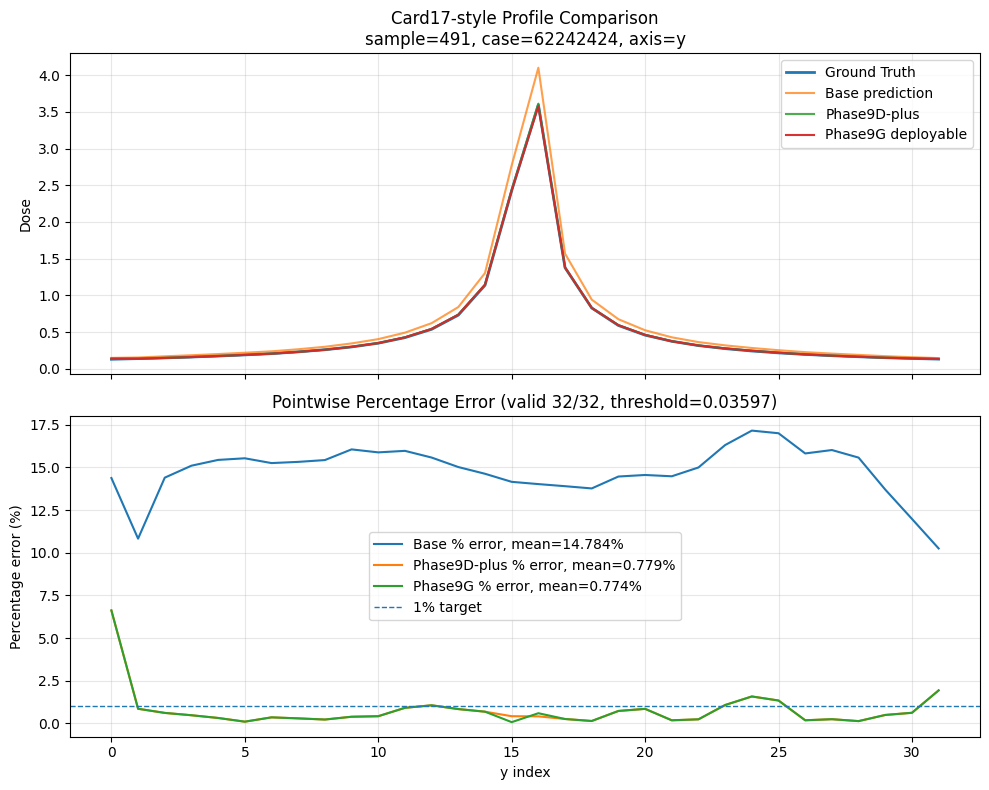

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/sample0491_case62242424_axisy_card17_style_phase9g_before_after.png

Percentage error summary:
Base:       mean=14.7845%, max=17.1619%
Phase9D+:   mean=0.7789%, max=6.6190%
Phase9G:    mean=0.7738%, max=6.6190%


In [ ]:
# ============================================================
# Generate Card17-style before/after figure
# ============================================================

@torch.no_grad()
def generate_card17_style_phase9g_figure(
    loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=PHASE9G_FINAL_DIR,
):
    base_model.eval()
    model_9d_plus.eval()

    global_idx = 0

    for batch_idx, batch in enumerate(loader):
        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)
        case_ids = batch.get("case_id", ["unknown"] * ct.shape[0])

        preds = predict_phase9g(ct, steps=CONFIG["euler_steps"])

        base_pred = preds["base_pred"]
        phase9d_pred = preds["phase9d_pred"]
        phase9g_pred = preds["phase9g_pred"]

        for b in range(ct.shape[0]):
            if global_idx == sample_index_to_plot:
                case_id = case_ids[b] if isinstance(case_ids, list) else str(case_ids[b])

                base_profiles = extract_axis_profiles(base_pred[b], gt[b])
                phase9d_profiles = extract_axis_profiles(phase9d_pred[b], gt[b])
                phase9g_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])

                gt_p = phase9g_profiles[axis_to_plot]["gt"]
                base_p = base_profiles[axis_to_plot]["pred"]
                phase9d_p = phase9d_profiles[axis_to_plot]["pred"]
                phase9g_p = phase9g_profiles[axis_to_plot]["pred"]

                base_pct, base_mean, base_max, valid_count, thr = percentage_error_curve(
                    base_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )
                phase9d_pct, phase9d_mean, phase9d_max, _, _ = percentage_error_curve(
                    phase9d_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )
                phase9g_pct, phase9g_mean, phase9g_max, _, _ = percentage_error_curve(
                    phase9g_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )

                x = np.arange(len(gt_p))

                fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

                axes[0].plot(x, gt_p, label="Ground Truth", linewidth=2)
                axes[0].plot(x, base_p, label="Base prediction", alpha=0.75)
                axes[0].plot(x, phase9d_p, label="Phase9D-plus", alpha=0.85)
                axes[0].plot(x, phase9g_p, label="Phase9G deployable", alpha=0.95)

                axes[0].set_title(
                    f"Card17-style Profile Comparison\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}, axis={axis_to_plot}"
                )
                axes[0].set_ylabel("Dose")
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                axes[1].plot(x, base_pct, label=f"Base % error, mean={base_mean:.3f}%")
                axes[1].plot(x, phase9d_pct, label=f"Phase9D-plus % error, mean={phase9d_mean:.3f}%")
                axes[1].plot(x, phase9g_pct, label=f"Phase9G % error, mean={phase9g_mean:.3f}%")

                axes[1].axhline(1.0, linestyle="--", linewidth=1, label="1% target")

                axes[1].set_title(
                    f"Pointwise Percentage Error "
                    f"(valid {valid_count}/{len(gt_p)}, threshold={thr:.5f})"
                )
                axes[1].set_xlabel(f"{axis_to_plot} index")
                axes[1].set_ylabel("Percentage error (%)")
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                fig.tight_layout()

                out_path = Path(save_dir) / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_axis{axis_to_plot}_card17_style_phase9g_before_after.png"
                )

                fig.savefig(out_path, dpi=220, bbox_inches="tight")
                plt.show()

                print("Saved:", out_path)
                print()
                print("Percentage error summary:")
                print(f"Base:       mean={base_mean:.4f}%, max={base_max:.4f}%")
                print(f"Phase9D+:   mean={phase9d_mean:.4f}%, max={phase9d_max:.4f}%")
                print(f"Phase9G:    mean={phase9g_mean:.4f}%, max={phase9g_max:.4f}%")

                return {
                    "path": out_path,
                    "sample_idx": sample_index_to_plot,
                    "case_id": case_id,
                    "axis": axis_to_plot,
                    "base_mean_pct": base_mean,
                    "phase9d_mean_pct": phase9d_mean,
                    "phase9g_mean_pct": phase9g_mean,
                    "base_max_pct": base_max,
                    "phase9d_max_pct": phase9d_max,
                    "phase9g_max_pct": phase9g_max,
                }

            global_idx += 1

    raise ValueError(f"sample_index_to_plot={sample_index_to_plot} not found.")


# Try the old Card17 sample number first
result_491 = generate_card17_style_phase9g_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
)

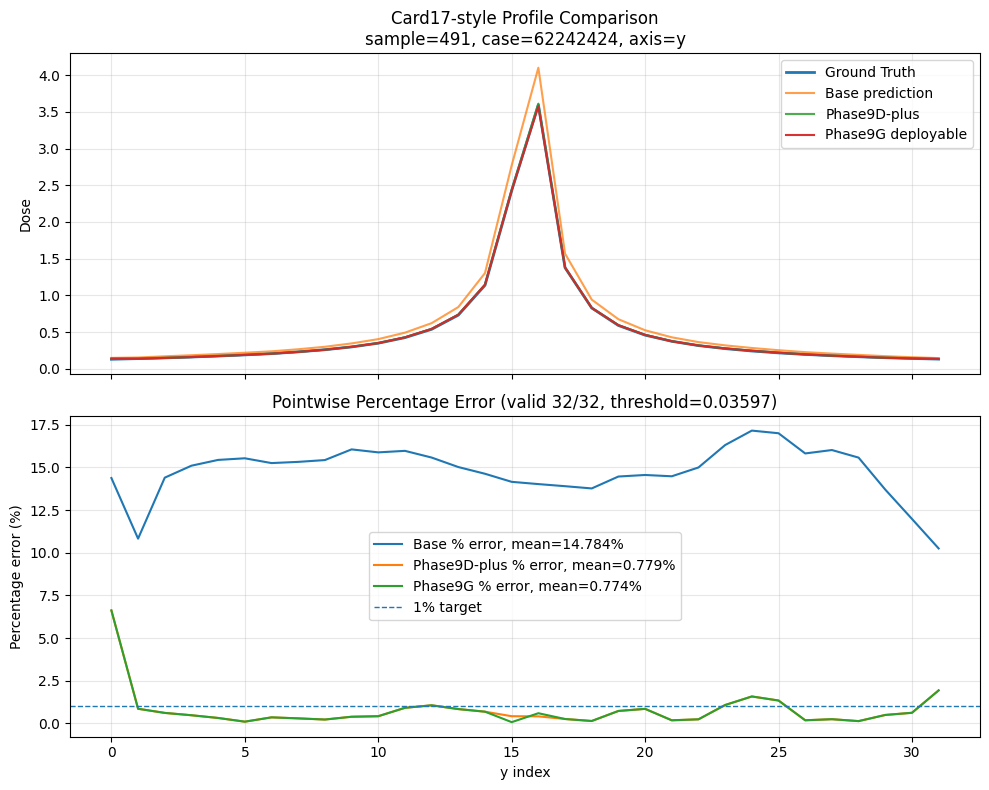

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/sample0491_case62242424_axisy_card17_style_phase9g_before_after.png

Percentage error summary:
Base:       mean=14.7845%, max=17.1619%
Phase9D+:   mean=0.7789%, max=6.6190%
Phase9G:    mean=0.7738%, max=6.6190%
<class 'dict'>
{'path': PosixPath('/content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/sample0491_case62242424_axisy_card17_style_phase9g_before_after.png'), 'sample_idx': 491, 'case_id': '62242424098194756750821789925294112700', 'axis': 'y', 'base_mean_pct': 14.784469656457013, 'phase9d_mean_pct': 0.7789441706103726, 'phase9g_mean_pct': 0.7737995990620838, 'base_max_pct': 17.161887243365435, 'phase9d_max_pct': 6.618986378668697, 'phase9g_max_pct': 6.618986378668697}


In [ ]:
result_491_y = generate_card17_style_phase9g_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
)

print(type(result_491_y))
print(result_491_y)

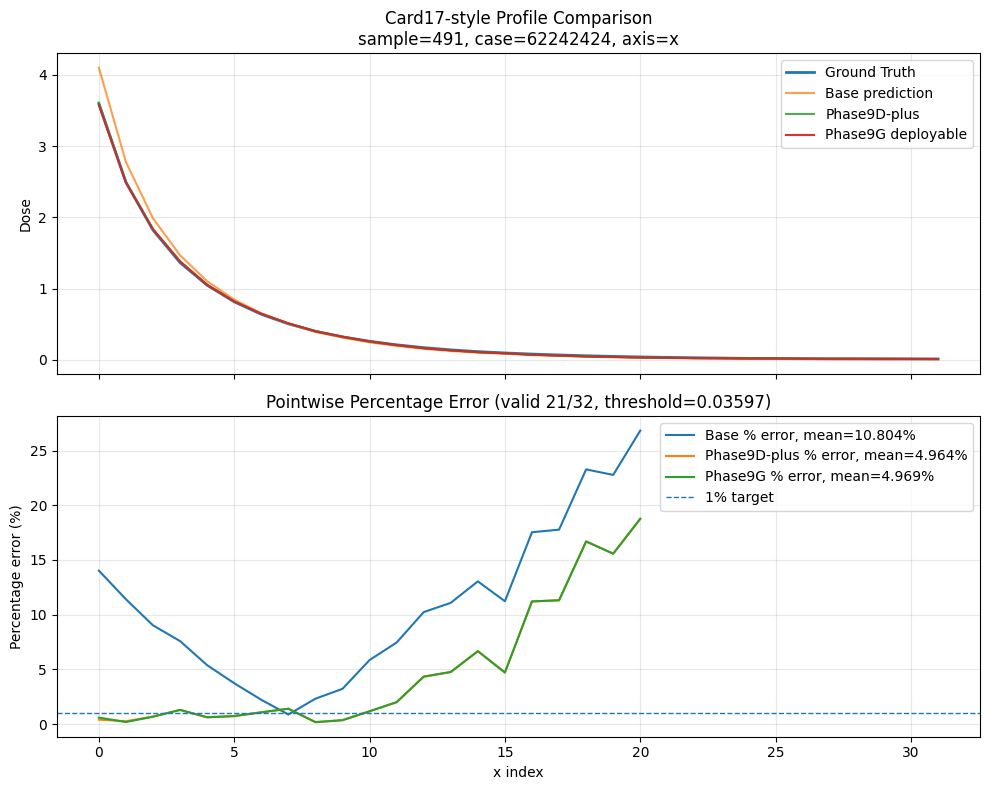

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/sample0491_case62242424_axisx_card17_style_phase9g_before_after.png

Percentage error summary:
Base:       mean=10.8043%, max=26.8212%
Phase9D+:   mean=4.9641%, max=18.7602%
Phase9G:    mean=4.9690%, max=18.7602%
<class 'dict'>
{'path': PosixPath('/content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/sample0491_case62242424_axisx_card17_style_phase9g_before_after.png'), 'sample_idx': 491, 'case_id': '62242424098194756750821789925294112700', 'axis': 'x', 'base_mean_pct': 10.804301157910821, 'phase9d_mean_pct': 4.964146170359458, 'phase9g_mean_pct': 4.969028528393631, 'base_max_pct': 26.821217122700222, 'phase9d_max_pct': 18.7602175397258, 'phase9g_max_pct': 18.7602175397258}


In [ ]:
result_491_x = generate_card17_style_phase9g_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
)

print(type(result_491_x))
print(result_491_x)

In [ ]:
# ============================================================
# Phase10C Pre-flight check
# ============================================================

required_names = [
    "train_loader",
    "val_loader",
    "base_model",
    "model_9d_plus",
    "predict_phase9g",
    "extract_axis_profiles",
    "percentage_error_curve",
    "CONFIG",
    "PHASE9G_FINAL_DIR",
    "CHECKPOINT_DIR",
    "device",
]

missing = []
for name in required_names:
    if name not in globals():
        missing.append(name)

if missing:
    raise RuntimeError(f"Missing required variables/functions: {missing}")

print("Pre-flight check passed.")
print("CONFIG euler_steps:", CONFIG["euler_steps"])
print("CONFIG threshold_frac:", CONFIG.get("threshold_frac", "MISSING"))
print("Device:", device)

Pre-flight check passed.
CONFIG euler_steps: 10
CONFIG threshold_frac: 0.01
Device: cuda


In [ ]:
# ============================================================
# Verified Card17 sample491 comparison table
# Use values returned by generate_card17_style_phase9g_figure()
# ============================================================

CARD17_COMPARE_DIR = PHASE9G_FINAL_DIR / "card17_historical_comparison"
CARD17_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

result_491_y = {
    "base_mean_pct": 14.784469656457013,
    "phase9d_mean_pct": 0.7789441706103726,
    "phase9g_mean_pct": 0.7737995990620838,
}

result_491_x = {
    "base_mean_pct": 10.804301157910821,
    "phase9d_mean_pct": 4.964146170359458,
    "phase9g_mean_pct": 4.969028528393631,
}

sample491_comparison_df = pd.DataFrame([
    {
        "method": "Card17 tuned baseline",
        "source": "historical_card17_csv",
        "along_x_mean_pct": 5.287613,
        "perpendicular_y_mean_pct": 4.050796,
    },
    {
        "method": "Card17 Phase4 mixed weighted",
        "source": "historical_card17_csv",
        "along_x_mean_pct": 2.774812,
        "perpendicular_y_mean_pct": 1.614564,
    },
    {
        "method": "Phase5E along-falloff base",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x["base_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y["base_mean_pct"],
    },
    {
        "method": "Phase9D-plus",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x["phase9d_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y["phase9d_mean_pct"],
    },
    {
        "method": "Phase9G deployable",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x["phase9g_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y["phase9g_mean_pct"],
    },
])

display(sample491_comparison_df)

out_csv = CARD17_COMPARE_DIR / "sample491_card17_vs_phase9g_comparison_table_VERIFIED.csv"
sample491_comparison_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

,method,source,along_x_mean_pct,perpendicular_y_mean_pct
0,Card17 tuned baseline,historical_card17_csv,5.287613,4.050796
1,Card17 Phase4 mixed weighted,historical_card17_csv,2.774812,1.614564
2,Phase5E along-falloff base,current_corrected_pipeline,10.804301,14.784470
3,Phase9D-plus,current_corrected_pipeline,4.964146,0.778944
4,Phase9G deployable,current_corrected_pipeline,4.969029,0.773800


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/card17_historical_comparison/sample491_card17_vs_phase9g_comparison_table_VERIFIED.csv


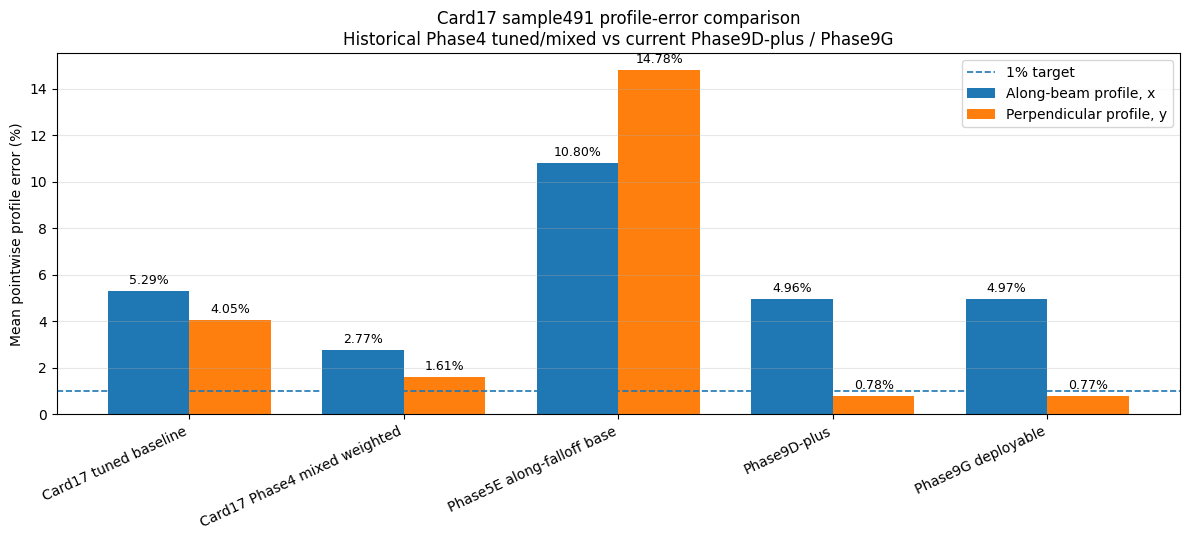

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/card17_historical_comparison/sample491_card17_vs_phase9g_bar_comparison_VERIFIED.png


In [ ]:
# ============================================================
# Verified bar plot
# ============================================================

plot_df = sample491_comparison_df.copy()

method_order = [
    "Card17 tuned baseline",
    "Card17 Phase4 mixed weighted",
    "Phase5E along-falloff base",
    "Phase9D-plus",
    "Phase9G deployable",
]

plot_df["method"] = pd.Categorical(
    plot_df["method"],
    categories=method_order,
    ordered=True,
)
plot_df = plot_df.sort_values("method")

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5.5))

bars1 = ax.bar(
    x - width / 2,
    plot_df["along_x_mean_pct"],
    width,
    label="Along-beam profile, x",
)

bars2 = ax.bar(
    x + width / 2,
    plot_df["perpendicular_y_mean_pct"],
    width,
    label="Perpendicular profile, y",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label="1% target",
)

ax.set_title(
    "Card17 sample491 profile-error comparison\n"
    "Historical Phase4 tuned/mixed vs current Phase9D-plus / Phase9G"
)
ax.set_ylabel("Mean pointwise profile error (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["method"], rotation=25, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.tight_layout()

out_png = CARD17_COMPARE_DIR / "sample491_card17_vs_phase9g_bar_comparison_VERIFIED.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

### Cell 1 — Phase10A helper functions

In [ ]:
# ============================================================
# Phase10A helper: x-axis oracle correction
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def smooth_1d_torch(x, kernel_size=5):
    """
    Edge-replicated moving average for a 1D torch tensor.
    """
    if kernel_size <= 1:
        return x

    pad = kernel_size // 2

    x_pad = F.pad(
        x[None, None, :],
        (pad, pad),
        mode="replicate",
    )

    kernel = torch.ones(
        1,
        1,
        kernel_size,
        device=x.device,
        dtype=x.dtype,
    ) / float(kernel_size)

    y = F.conv1d(x_pad, kernel)

    return y[0, 0]


@torch.no_grad()
def make_phase10a_xscale_oracle_batch(
    phase9g_pred,
    gt,
    clip_low=0.85,
    clip_high=1.15,
    smooth_kernel=5,
    threshold_frac=0.01,
):
    """
    Phase10A oracle x-scale correction.

    Input:
        phase9g_pred: [B, 1, D, H, W]
        gt:           [B, 1, D, H, W]

    Output:
        phase10a_pred: [B, 1, D, H, W]
        scale_batch:   [B, D]

    Important:
        This uses GT to estimate x-dependent scale.
        Therefore this is NOT deployable.
        It is only a diagnostic / headroom test.

    Correction:
        phase10a[x, y, z] = phase9g[x, y, z] * scale_x[x]

    The scale_x is estimated from the central x profile:
        gt_x / phase9g_x

    Then smoothed and clipped.
    """
    assert phase9g_pred.ndim == 5, phase9g_pred.shape
    assert gt.ndim == 5, gt.shape
    assert phase9g_pred.shape == gt.shape, (phase9g_pred.shape, gt.shape)

    B, C, D, H, W = phase9g_pred.shape
    assert C == 1

    cy = H // 2
    cz = W // 2

    corrected_list = []
    scale_list = []

    for b in range(B):
        pred_b = phase9g_pred[b:b + 1].clone()
        gt_b = gt[b:b + 1].clone()

        pred_x = pred_b[0, 0, :, cy, cz]
        gt_x = gt_b[0, 0, :, cy, cz]

        threshold = threshold_frac * torch.max(gt_x)
        valid = gt_x > threshold

        raw_scale = torch.ones_like(gt_x)

        raw_scale[valid] = gt_x[valid] / torch.clamp(
            pred_x[valid],
            min=1e-8,
        )

        smooth_scale = smooth_1d_torch(
            raw_scale,
            kernel_size=smooth_kernel,
        )

        smooth_scale = torch.clamp(
            smooth_scale,
            min=clip_low,
            max=clip_high,
        )

        corrected_b = pred_b * smooth_scale.view(1, 1, D, 1, 1)
        corrected_b = torch.clamp(corrected_b, min=0.0)

        corrected_list.append(corrected_b)
        scale_list.append(smooth_scale)

    phase10a_pred = torch.cat(corrected_list, dim=0)
    scale_batch = torch.stack(scale_list, dim=0)

    return phase10a_pred, scale_batch

### Cell 2 — 完整新版函数：生成 Phase9G + Phase10A 图

In [ ]:
# ============================================================
# Generate Card17-style before/after figure with Phase10A oracle
# ============================================================

@torch.no_grad()
def generate_card17_style_phase10a_figure(
    loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=None,
    phase10a_clip_low=0.85,
    phase10a_clip_high=1.15,
    phase10a_smooth_kernel=5,
):
    """
    Generate Card17-style profile figure with:
        Ground Truth
        Phase5E base
        Phase9D-plus
        Phase9G deployable
        Phase10A x-scale oracle

    Important:
        Phase10A uses GT to estimate x-dependent scale.
        It is a diagnostic / oracle upper-bound, not deployable.

    This function intentionally reuses the existing extract_axis_profiles()
    and percentage_error_curve() functions so that the profile line is
    consistent with your verified Card17-style Phase9G figures.
    """
    if save_dir is None:
        save_dir = PHASE9G_FINAL_DIR / "phase10a_along_beam_oracle_diagnostic"

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    base_model.eval()
    model_9d_plus.eval()

    global_idx = 0

    for batch_idx, batch in enumerate(loader):
        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)
        case_ids = batch.get("case_id", ["unknown"] * ct.shape[0])

        preds = predict_phase9g(ct, steps=CONFIG["euler_steps"])

        base_pred = preds["base_pred"]
        phase9d_pred = preds["phase9d_pred"]
        phase9g_pred = preds["phase9g_pred"]

        phase10a_pred, phase10a_scale_x = make_phase10a_xscale_oracle_batch(
            phase9g_pred=phase9g_pred,
            gt=gt,
            clip_low=phase10a_clip_low,
            clip_high=phase10a_clip_high,
            smooth_kernel=phase10a_smooth_kernel,
            threshold_frac=CONFIG["threshold_frac"],
        )

        for b in range(ct.shape[0]):
            if global_idx == sample_index_to_plot:
                if isinstance(case_ids, list):
                    case_id = case_ids[b]
                else:
                    case_id = str(case_ids[b])

                # ------------------------------------------------------------
                # Use the SAME profile extraction method as the verified figure
                # ------------------------------------------------------------
                base_profiles = extract_axis_profiles(base_pred[b], gt[b])
                phase9d_profiles = extract_axis_profiles(phase9d_pred[b], gt[b])
                phase9g_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
                phase10a_profiles = extract_axis_profiles(phase10a_pred[b], gt[b])

                gt_p = phase9g_profiles[axis_to_plot]["gt"]

                base_p = base_profiles[axis_to_plot]["pred"]
                phase9d_p = phase9d_profiles[axis_to_plot]["pred"]
                phase9g_p = phase9g_profiles[axis_to_plot]["pred"]
                phase10a_p = phase10a_profiles[axis_to_plot]["pred"]

                base_pct, base_mean, base_max, valid_count, thr = percentage_error_curve(
                    base_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )

                phase9d_pct, phase9d_mean, phase9d_max, _, _ = percentage_error_curve(
                    phase9d_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )

                phase9g_pct, phase9g_mean, phase9g_max, _, _ = percentage_error_curve(
                    phase9g_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )

                phase10a_pct, phase10a_mean, phase10a_max, _, _ = percentage_error_curve(
                    phase10a_p,
                    gt_p,
                    threshold_frac=CONFIG["threshold_frac"],
                )

                x = np.arange(len(gt_p))

                # ------------------------------------------------------------
                # Plot
                # ------------------------------------------------------------
                fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

                axes[0].plot(x, gt_p, label="Ground Truth", linewidth=2)
                axes[0].plot(x, base_p, label="Phase5E base", alpha=0.75)
                axes[0].plot(x, phase9d_p, label="Phase9D-plus", alpha=0.85)
                axes[0].plot(x, phase9g_p, label="Phase9G deployable", alpha=0.95)
                axes[0].plot(
                    x,
                    phase10a_p,
                    label="Phase10A x-scale oracle",
                    linestyle="--",
                    alpha=0.95,
                )

                axes[0].set_title(
                    f"Card17-style Profile Comparison with Phase10A Oracle\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}, axis={axis_to_plot}"
                )
                axes[0].set_ylabel("Dose")
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                axes[1].plot(
                    x,
                    base_pct,
                    label=f"Phase5E base % error, mean={base_mean:.3f}%",
                )
                axes[1].plot(
                    x,
                    phase9d_pct,
                    label=f"Phase9D-plus % error, mean={phase9d_mean:.3f}%",
                )
                axes[1].plot(
                    x,
                    phase9g_pct,
                    label=f"Phase9G % error, mean={phase9g_mean:.3f}%",
                )
                axes[1].plot(
                    x,
                    phase10a_pct,
                    label=f"Phase10A oracle % error, mean={phase10a_mean:.3f}%",
                    linestyle="--",
                )

                axes[1].axhline(
                    1.0,
                    linestyle="--",
                    linewidth=1,
                    label="1% target",
                )

                axes[1].set_title(
                    f"Pointwise Percentage Error "
                    f"(valid {valid_count}/{len(gt_p)}, threshold={thr:.5f})"
                )
                axes[1].set_xlabel(f"{axis_to_plot} index")
                axes[1].set_ylabel("Percentage error (%)")
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                fig.tight_layout()

                out_path = save_dir / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_axis{axis_to_plot}_card17_style_phase10a_oracle.png"
                )

                fig.savefig(out_path, dpi=220, bbox_inches="tight")
                plt.show()

                # ------------------------------------------------------------
                # Also save x-scale plot for diagnosis
                # ------------------------------------------------------------
                scale_x_np = phase10a_scale_x[b].detach().cpu().numpy()
                scale_plot_path = save_dir / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_phase10a_xscale.png"
                )

                fig2, ax2 = plt.subplots(figsize=(8, 3.5))
                ax2.plot(scale_x_np, label="Phase10A oracle x-scale")
                ax2.axhline(1.0, linestyle="--", linewidth=1, label="scale=1")
                ax2.axhline(phase10a_clip_low, linestyle=":", linewidth=1, label="clip bounds")
                ax2.axhline(phase10a_clip_high, linestyle=":", linewidth=1)
                ax2.set_title(
                    f"Phase10A x-dependent oracle scale\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}"
                )
                ax2.set_xlabel("x index")
                ax2.set_ylabel("scale")
                ax2.grid(True, alpha=0.3)
                ax2.legend()
                fig2.tight_layout()
                fig2.savefig(scale_plot_path, dpi=220, bbox_inches="tight")
                plt.show()

                print("Saved:", out_path)
                print("Saved scale plot:", scale_plot_path)
                print()
                print("Percentage error summary:")
                print(f"Phase5E base: mean={base_mean:.4f}%, max={base_max:.4f}%")
                print(f"Phase9D+:     mean={phase9d_mean:.4f}%, max={phase9d_max:.4f}%")
                print(f"Phase9G:      mean={phase9g_mean:.4f}%, max={phase9g_max:.4f}%")
                print(f"Phase10A:     mean={phase10a_mean:.4f}%, max={phase10a_max:.4f}%")

                return {
                    "path": out_path,
                    "scale_plot_path": scale_plot_path,
                    "sample_idx": sample_index_to_plot,
                    "case_id": case_id,
                    "axis": axis_to_plot,
                    "base_mean_pct": base_mean,
                    "phase9d_mean_pct": phase9d_mean,
                    "phase9g_mean_pct": phase9g_mean,
                    "phase10a_mean_pct": phase10a_mean,
                    "base_max_pct": base_max,
                    "phase9d_max_pct": phase9d_max,
                    "phase9g_max_pct": phase9g_max,
                    "phase10a_max_pct": phase10a_max,
                    "valid_count": valid_count,
                    "threshold": thr,
                    "phase10a_clip_low": phase10a_clip_low,
                    "phase10a_clip_high": phase10a_clip_high,
                    "phase10a_smooth_kernel": phase10a_smooth_kernel,
                    "scale_min": float(np.min(scale_x_np)),
                    "scale_max": float(np.max(scale_x_np)),
                    "scale_mean": float(np.mean(scale_x_np)),
                }

            global_idx += 1

    raise ValueError(f"sample_index_to_plot={sample_index_to_plot} not found.")

### Cell 3 — 先跑 sample491 的 x / y，并验证 Phase9G 数值一致

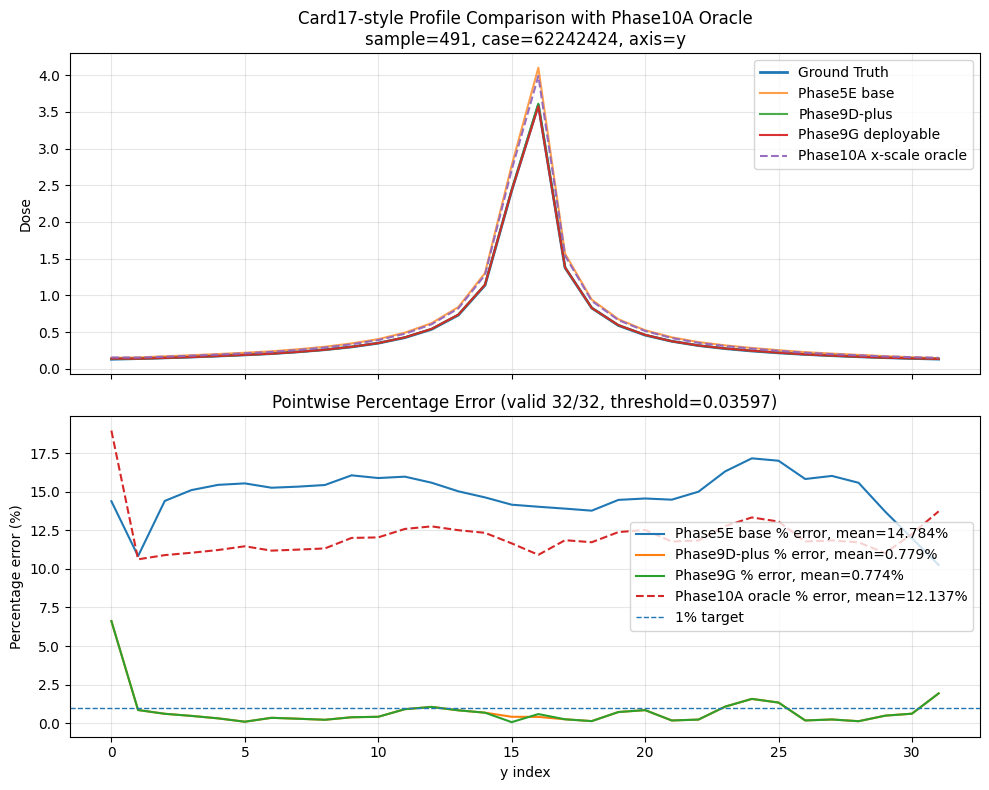

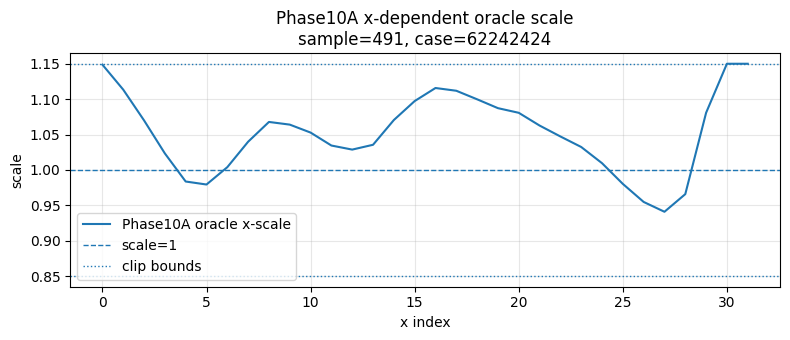

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample0491_case62242424_axisy_card17_style_phase10a_oracle.png
Saved scale plot: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample0491_case62242424_phase10a_xscale.png

Percentage error summary:
Phase5E base: mean=14.7845%, max=17.1619%
Phase9D+:     mean=0.7789%, max=6.6190%
Phase9G:      mean=0.7738%, max=6.6190%
Phase10A:     mean=12.1369%, max=18.9588%
result_491_y_10a:
{'path': PosixPath('/content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample0491_case62242424_axisy_card17_style_phase10a_oracle.png'), 'scale_plot_path': PosixPath('/content/drive/MyDrive/rectified_flow_ct2dose/analy

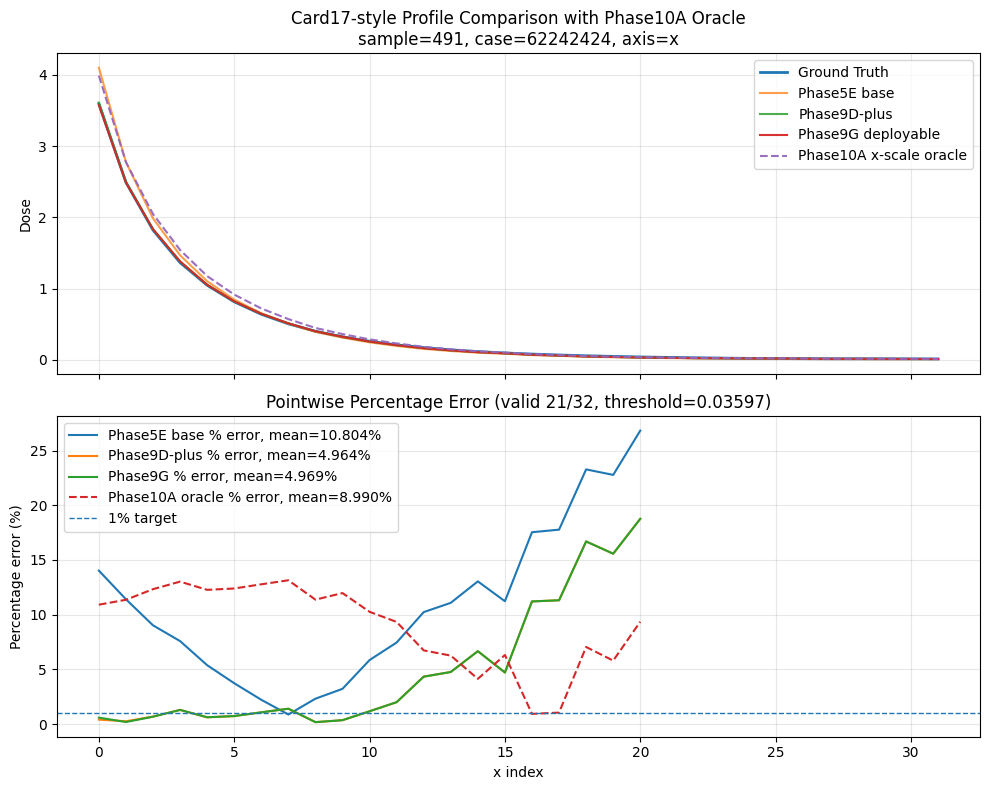

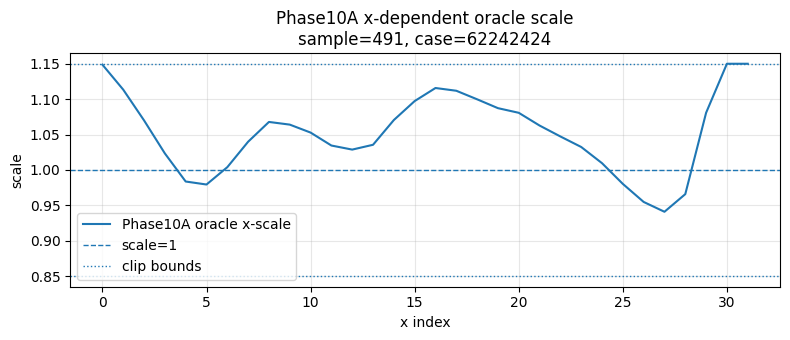

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample0491_case62242424_axisx_card17_style_phase10a_oracle.png
Saved scale plot: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample0491_case62242424_phase10a_xscale.png

Percentage error summary:
Phase5E base: mean=10.8043%, max=26.8212%
Phase9D+:     mean=4.9641%, max=18.7602%
Phase9G:      mean=4.9690%, max=18.7602%
Phase10A:     mean=8.9902%, max=13.1437%
result_491_x_10a:
{'path': PosixPath('/content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample0491_case62242424_axisx_card17_style_phase10a_oracle.png'), 'scale_plot_path': PosixPath('/content/drive/MyDrive/rectified_flow_ct2dose/anal

In [ ]:
# ============================================================
# Run verified Phase10A on Card17 sample491
# ============================================================

PHASE10A_DIR = PHASE9G_FINAL_DIR / "phase10a_along_beam_oracle_diagnostic"
PHASE10A_DIR.mkdir(parents=True, exist_ok=True)

result_491_y_10a = generate_card17_style_phase10a_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=PHASE10A_DIR,
    phase10a_clip_low=0.85,
    phase10a_clip_high=1.15,
    phase10a_smooth_kernel=5,
)

print("result_491_y_10a:")
print(result_491_y_10a)

result_491_x_10a = generate_card17_style_phase10a_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10A_DIR,
    phase10a_clip_low=0.85,
    phase10a_clip_high=1.15,
    phase10a_smooth_kernel=5,
)

print("result_491_x_10a:")
print(result_491_x_10a)

### Cell 4 — 生成可信 Phase10A 对照表

In [ ]:
# ============================================================
# Verified comparison table:
# Card17 historical vs Phase5E / Phase9D / Phase9G / Phase10A
# ============================================================

phase10a_verified_df = pd.DataFrame([
    {
        "method": "Card17 tuned baseline",
        "source": "historical_card17_csv",
        "along_x_mean_pct": 5.287613,
        "perpendicular_y_mean_pct": 4.050796,
    },
    {
        "method": "Card17 Phase4 mixed weighted",
        "source": "historical_card17_csv",
        "along_x_mean_pct": 2.774812,
        "perpendicular_y_mean_pct": 1.614564,
    },
    {
        "method": "Phase5E along-falloff base",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_10a["base_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10a["base_mean_pct"],
    },
    {
        "method": "Phase9D-plus",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_10a["phase9d_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10a["phase9d_mean_pct"],
    },
    {
        "method": "Phase9G deployable",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_10a["phase9g_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10a["phase9g_mean_pct"],
    },
    {
        "method": "Phase10A x-scale oracle",
        "source": "oracle_headroom_diagnostic",
        "along_x_mean_pct": result_491_x_10a["phase10a_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10a["phase10a_mean_pct"],
    },
])

# Helpful deltas relative to Card17 mixed
card17_mixed_along = 2.774812
card17_mixed_perp = 1.614564

phase10a_verified_df["delta_vs_card17_mixed_along_x"] = (
    phase10a_verified_df["along_x_mean_pct"] - card17_mixed_along
)

phase10a_verified_df["delta_vs_card17_mixed_perpendicular_y"] = (
    phase10a_verified_df["perpendicular_y_mean_pct"] - card17_mixed_perp
)

display(phase10a_verified_df)

out_csv = PHASE10A_DIR / "sample491_card17_phase9g_phase10a_comparison_VERIFIED.csv"
phase10a_verified_df.to_csv(out_csv, index=False)

print("Saved:", out_csv)

,method,source,along_x_mean_pct,perpendicular_y_mean_pct,delta_vs_card17_mixed_along_x,delta_vs_card17_mixed_perpendicular_y
0,Card17 tuned baseline,historical_card17_csv,5.287613,4.050796,2.512801,2.436232
1,Card17 Phase4 mixed weighted,historical_card17_csv,2.774812,1.614564,0.000000,0.000000
2,Phase5E along-falloff base,current_corrected_pipeline,10.804301,14.784470,8.029489,13.169906
3,Phase9D-plus,current_corrected_pipeline,4.964146,0.778944,2.189334,-0.835620
4,Phase9G deployable,current_corrected_pipeline,4.969029,0.773800,2.194217,-0.840764
5,Phase10A x-scale oracle,oracle_headroom_diagnostic,8.990186,12.136907,6.215374,10.522343


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10a_along_beam_oracle_diagnostic/sample491_card17_phase9g_phase10a_comparison_VERIFIED.csv


### Cell 1 — 搜索 Phase4 mixed checkpoint

In [ ]:
# ============================================================
# Phase10B: search Phase4 mixed weighted checkpoint
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PHASE10B_DIR = PHASE9G_FINAL_DIR / "phase10b_phase4_phase9g_hybrid_diagnostic"
PHASE10B_DIR.mkdir(parents=True, exist_ok=True)

print("PHASE10B_DIR:", PHASE10B_DIR)

# Search likely Phase4 mixed checkpoints
candidates = []

for p in CHECKPOINT_DIR.glob("*.pt"):
    name = p.name.lower()
    if (
        ("phase4" in name and "mixed" in name)
        or ("beam_aware_mixed" in name)
        or ("mixed_weighted" in name)
    ):
        candidates.append(p)

print("Found candidates:")
for i, p in enumerate(candidates):
    print(i, p.name)

if len(candidates) == 0:
    raise FileNotFoundError(
        "No Phase4 mixed checkpoint found. "
        "Please check CHECKPOINT_DIR or manually set PHASE4_MIXED_CKPT."
    )

PHASE10B_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10b_phase4_phase9g_hybrid_diagnostic
Found candidates:
0 phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_latest.pt
1 phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt
2 phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p20_mw3_latest.pt
3 phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p20_mw3_best.pt
4 ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw2_best.pt
5 ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw2_latest.pt
6 ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt
7 ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_latest.pt
8 ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_best.pt
9 ct2dose_phase4_bone_aware_mixed_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_bf2_latest.pt
10 ct2dose_phase4_beam_aware_m

### Cell 2 — 选择 Phase4 checkpoint

In [ ]:
# ============================================================
# Select the Card17-matching Phase4 mixed weighted checkpoint
# ============================================================

PHASE4_MIXED_CKPT = candidates[3]

print("Using PHASE4_MIXED_CKPT:")
print(PHASE4_MIXED_CKPT)

phase4_ckpt_meta = torch.load(PHASE4_MIXED_CKPT, map_location="cpu")

print("\nCheckpoint keys:")
print(phase4_ckpt_meta.keys())

phase4_cfg = phase4_ckpt_meta.get("config", {})

print("\nPhase4 config:")
for k, v in phase4_cfg.items():
    print(k, ":", v)

PHASE4_BASE_CH = int(phase4_cfg.get("base_ch", 24))
PHASE4_EULER_STEPS = int(phase4_cfg.get("euler_steps", CONFIG["euler_steps"]))

print("\nPHASE4_BASE_CH:", PHASE4_BASE_CH)
print("PHASE4_EULER_STEPS:", PHASE4_EULER_STEPS)

Using PHASE4_MIXED_CKPT:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p20_mw3_best.pt

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'run_name', 'threshold', 'threshold_mode', 'alpha', 'max_weight', 'lr', 'base_ch', 'best_val_loss'])

Phase4 config:

PHASE4_BASE_CH: 24
PHASE4_EULER_STEPS: 10


In [ ]:
# ============================================================
# Load selected Phase4 mixed weighted model
# ============================================================

phase4_mixed_model = ConditionalUNetFlow3D(
    in_ch=3,
    out_ch=1,
    base_ch=PHASE4_BASE_CH,
).to(device)

phase4_ckpt = load_state_dict_flexible(
    phase4_mixed_model,
    PHASE4_MIXED_CKPT,
    device,
    strict_final=True,
)

phase4_mixed_model.eval()

print("Phase4 mixed model loaded cleanly.")

Loading: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p20_mw3_best.pt
Checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'run_name', 'threshold', 'threshold_mode', 'alpha', 'max_weight', 'lr', 'base_ch', 'best_val_loss']
Missing keys: [] 
Unexpected keys: [] 
Phase4 mixed model loaded cleanly.


In [ ]:
# ============================================================
# Phase4 mixed rerun sanity check on sample491
# ============================================================

CARD17_SAMPLE_IDX = 491

CARD17_TUNED_ALONG_X = 5.287613
CARD17_TUNED_PERP_Y = 4.050796

CARD17_MIXED_ALONG_X = 2.774812
CARD17_MIXED_PERP_Y = 1.614564


def get_single_sample_from_loader(loader, sample_index):
    seen = 0

    for batch in loader:
        bs = batch["ct"].shape[0]

        if seen <= sample_index < seen + bs:
            local_idx = sample_index - seen

            out = {}
            for k, v in batch.items():
                if torch.is_tensor(v):
                    out[k] = v[local_idx:local_idx + 1]
                elif isinstance(v, (list, tuple)):
                    out[k] = [v[local_idx]]
                else:
                    out[k] = v

            return out

        seen += bs

    raise IndexError(f"sample_index={sample_index} not found.")


def compute_axis_mean_pct_from_tensors(pred_tensor, gt_tensor, axis):
    """
    Use the same verified extract_axis_profiles() + percentage_error_curve()
    as generate_card17_style_phase9g_figure().
    """
    profiles = extract_axis_profiles(pred_tensor[0], gt_tensor[0])

    gt_p = profiles[axis]["gt"]
    pred_p = profiles[axis]["pred"]

    pct, mean_pct, max_pct, valid_count, thr = percentage_error_curve(
        pred_p,
        gt_p,
        threshold_frac=CONFIG["threshold_frac"],
    )

    return {
        "mean_pct": mean_pct,
        "max_pct": max_pct,
        "valid_count": valid_count,
        "threshold": thr,
        "pct_curve": pct,
        "gt_profile": gt_p,
        "pred_profile": pred_p,
    }


@torch.no_grad()
def predict_phase4_mixed(ct, steps=None):
    if steps is None:
        steps = PHASE4_EULER_STEPS

    pred = euler_sample_ct2dose(
        phase4_mixed_model,
        ct,
        steps=steps,
    )

    return pred


@torch.no_grad()
def get_sample491_predictions_for_hybrid():
    sample_batch = get_single_sample_from_loader(
        val_loader,
        CARD17_SAMPLE_IDX,
    )

    ct = sample_batch["ct"].to(device)
    gt = sample_batch["dose"].to(device)

    case_ids = sample_batch.get("case_id", ["unknown"])
    if isinstance(case_ids, (list, tuple)):
        case_id = case_ids[0]
    else:
        case_id = str(case_ids)

    preds9 = predict_phase9g(
        ct,
        steps=CONFIG["euler_steps"],
    )

    phase5e_pred = preds9["base_pred"]
    phase9d_pred = preds9["phase9d_pred"]
    phase9g_pred = preds9["phase9g_pred"]

    phase4_pred = predict_phase4_mixed(
        ct,
        steps=PHASE4_EULER_STEPS,
    )

    print("Sample491 case_id:", case_id)
    print("Sample491 sanity ranges:")
    for name, vol in [
        ("gt", gt),
        ("phase4_mixed", phase4_pred),
        ("phase5e_base", phase5e_pred),
        ("phase9d", phase9d_pred),
        ("phase9g", phase9g_pred),
    ]:
        print(
            name,
            "min/max/mean:",
            vol.min().item(),
            vol.max().item(),
            vol.mean().item(),
        )

    return {
        "case_id": case_id,
        "ct": ct,
        "gt": gt,
        "phase4_mixed": phase4_pred,
        "phase5e_base": phase5e_pred,
        "phase9d": phase9d_pred,
        "phase9g": phase9g_pred,
    }


sample491_preds = get_sample491_predictions_for_hybrid()
gt = sample491_preds["gt"]

print("\nVerified current Phase9G:")
for axis in ["x", "y"]:
    m = compute_axis_mean_pct_from_tensors(
        sample491_preds["phase9g"],
        gt,
        axis=axis,
    )
    print("Phase9G", axis, "mean:", m["mean_pct"], "max:", m["max_pct"])

print("\nPhase4 mixed checkpoint rerun:")
for axis in ["x", "y"]:
    m = compute_axis_mean_pct_from_tensors(
        sample491_preds["phase4_mixed"],
        gt,
        axis=axis,
    )
    print("Phase4 mixed", axis, "mean:", m["mean_pct"], "max:", m["max_pct"])

print("\nHistorical Card17 mixed reference:")
print("along x:", CARD17_MIXED_ALONG_X)
print("perp y:", CARD17_MIXED_PERP_Y)

Sample491 case_id: 62242424098194756750821789925294112700
Sample491 sanity ranges:
gt min/max/mean: 0.0004320277366787195 3.596792697906494 0.04712176322937012
phase4_mixed min/max/mean: 0.0 4.066383361816406 0.047583919018507004
phase5e_base min/max/mean: 0.0 4.101186275482178 0.04781346023082733
phase9d min/max/mean: 0.0002954000956378877 3.6114611625671387 0.048388369381427765
phase9g min/max/mean: 0.0002954000956378877 3.575366497039795 0.0483863390982151

Verified current Phase9G:
Phase9G x mean: 4.964738159726474 max: 18.76895439012394
Phase9G y mean: 0.7734285320008866 max: 6.620870269360466

Phase4 mixed checkpoint rerun:
Phase4 mixed x mean: 9.490900088282023 max: 27.081655093654682
Phase4 mixed y mean: 10.813740485909833 max: 13.088613932655832

Historical Card17 mixed reference:
along x: 2.774812
perp y: 1.614564


In [ ]:
# ============================================================
# Phase4 mixed sampler diagnostic against Card17 historical sample491
# ============================================================

@torch.no_grad()
def euler_sample_phase4_variant(
    model,
    ct,
    steps=10,
    init_mode="ct",
    t_end=1.0,
    t_mode="mid",
    sign="+",
    clamp_each_step=True,
):
    model.eval()

    if init_mode == "ct":
        x = ct.clone()
    elif init_mode == "zero":
        x = torch.zeros_like(ct)
    else:
        raise ValueError(f"Unknown init_mode: {init_mode}")

    dt = float(t_end) / float(steps)

    for i in range(steps):
        if t_mode == "left":
            t_value = t_end * (i / steps)
        elif t_mode == "mid":
            t_value = t_end * ((i + 0.5) / steps)
        elif t_mode == "right":
            t_value = t_end * ((i + 1.0) / steps)
        elif t_mode == "reverse_mid":
            t_value = t_end * (1.0 - (i + 0.5) / steps)
        else:
            raise ValueError(f"Unknown t_mode: {t_mode}")

        t = torch.full(
            (ct.shape[0],),
            float(t_value),
            device=ct.device,
            dtype=ct.dtype,
        )

        v = model(x, ct, t)

        if sign == "+":
            x = x + dt * v
        elif sign == "-":
            x = x - dt * v
        else:
            raise ValueError(f"Unknown sign: {sign}")

        if clamp_each_step:
            x = torch.clamp(x, min=0.0)

    return torch.clamp(x, min=0.0)


# Use the same sample491 batch already loaded
ct = sample491_preds["ct"]
gt = sample491_preds["gt"]

rows = []

for init_mode in ["ct", "zero"]:
    for t_end in [1.0, 0.5, 0.3, 0.15, 0.10, 0.05, 0.02]:
        for t_mode in ["left", "mid", "right", "reverse_mid"]:
            for sign in ["+", "-"]:
                pred = euler_sample_phase4_variant(
                    phase4_mixed_model,
                    ct,
                    steps=10,
                    init_mode=init_mode,
                    t_end=t_end,
                    t_mode=t_mode,
                    sign=sign,
                    clamp_each_step=True,
                )

                mx = compute_axis_mean_pct_from_tensors(pred, gt, axis="x")
                my = compute_axis_mean_pct_from_tensors(pred, gt, axis="y")

                # Distance to historical Card17 mixed weighted values
                dist_to_card17 = (
                    abs(mx["mean_pct"] - CARD17_MIXED_ALONG_X)
                    + abs(my["mean_pct"] - CARD17_MIXED_PERP_Y)
                )

                rows.append({
                    "init_mode": init_mode,
                    "t_end": t_end,
                    "t_mode": t_mode,
                    "sign": sign,
                    "x_mean_pct": mx["mean_pct"],
                    "y_mean_pct": my["mean_pct"],
                    "x_max_pct": mx["max_pct"],
                    "y_max_pct": my["max_pct"],
                    "pred_min": pred.min().item(),
                    "pred_max": pred.max().item(),
                    "pred_mean": pred.mean().item(),
                    "dist_to_card17_mixed": dist_to_card17,
                })

phase4_sampler_diag_df = pd.DataFrame(rows).sort_values("dist_to_card17_mixed")
display(phase4_sampler_diag_df.head(20))

diag_csv = PHASE10B_DIR / "phase4_mixed_sampler_diagnostic_sample491.csv"
phase4_sampler_diag_df.to_csv(diag_csv, index=False)

print("Saved:", diag_csv)

print("\nHistorical Card17 mixed reference:")
print("x:", CARD17_MIXED_ALONG_X)
print("y:", CARD17_MIXED_PERP_Y)

,init_mode,t_end,t_mode,sign,x_mean_pct,y_mean_pct,x_max_pct,y_max_pct,pred_min,pred_max,pred_mean,dist_to_card17_mixed
6,ct,1.00,reverse_mid,+,7.319003,7.881221,12.419161,20.752917,0.0,3.548500,0.054741,10.810848
4,ct,1.00,right,+,6.178763,10.797838,19.842008,13.250967,0.0,3.971080,0.048940,12.587225
2,ct,1.00,mid,+,9.490900,10.813740,27.081655,13.088614,0.0,4.066383,0.047584,15.915265
0,ct,1.00,left,+,12.350021,10.825133,31.868181,15.515362,0.0,4.154848,0.046524,18.785778
79,zero,0.30,reverse_mid,-,80.211246,51.970353,216.060492,100.000000,0.0,0.283834,0.114006,127.792223
77,zero,0.30,right,-,80.295983,52.083667,215.725600,100.000000,0.0,0.283796,0.113940,127.990274
75,zero,0.30,mid,-,80.297202,52.094922,215.979208,100.000000,0.0,0.283866,0.114018,128.002748
73,zero,0.30,left,-,80.302361,52.115027,216.165866,100.000000,0.0,0.283854,0.114094,128.028012
87,zero,0.15,reverse_mid,-,66.458568,74.734672,100.000000,100.000000,0.0,0.142301,0.057524,136.803864
81,zero,0.15,left,-,66.529058,74.822047,100.000000,100.000000,0.0,0.142303,0.057521,136.961729


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/phase10b_phase4_phase9g_hybrid_diagnostic/phase4_mixed_sampler_diagnostic_sample491.csv

Historical Card17 mixed reference:
x: 2.774812
y: 1.614564


In [ ]:
# ============================================================
# Phase10C: Direction-aware bounded refinement
# ============================================================

from pathlib import Path
import time
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PHASE10C_NAME = "ct2dose_phase10c_direction_aware_bounded_refinement"

PHASE10C_DIR = PHASE9G_FINAL_DIR / PHASE10C_NAME
PHASE10C_DIR.mkdir(parents=True, exist_ok=True)

PHASE10C_CKPT_DIR = CHECKPOINT_DIR
PHASE10C_CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Smoke-test config first.
# If it runs and looks promising, increase:
#   epochs: 3
#   max_train_batches: 1200
#   eval_max_batches: 300
# ------------------------------------------------------------

PHASE10C_CONFIG = {
    "seed": 42,

    # smoke-test training
    "epochs": 2,
    "lr": 5e-5,
    "weight_decay": 1e-5,
    "max_train_batches": 1000,
    "eval_max_batches": 200,

    # Phase9G inference base
    "euler_steps": int(CONFIG["euler_steps"]),

    # bounded correction
    "delta_scale": 0.010,
    "core_protect_strength": 0.75,
    "tail_protect_strength": 0.35,

    # region/profile thresholds
    "threshold_frac": float(CONFIG.get("threshold_frac", 0.01)),
    "main_frac": 0.30,
    "core_frac": 0.70,
    "shoulder_low": 0.30,
    "shoulder_high": 0.80,

    # losses
    "lambda_voxel": 0.6,
    "lambda_along": 4.0,
    "lambda_along_slope": 1.5,
    "lambda_perp_no_worse": 5.0,
    "lambda_core_no_worse": 3.0,
    "lambda_residual_l1": 0.08,
    "lambda_smooth": 0.06,

    # no-worse margins
    "perp_margin_abs": 0.0005,
    "core_margin_abs": 0.0005,

    # model
    "base_ch": 16,

    # Card17 reference for sample491
    "card17_mixed_along_x": 2.774812,
    "card17_mixed_perp_y": 1.614564,
}

torch.manual_seed(PHASE10C_CONFIG["seed"])
np.random.seed(PHASE10C_CONFIG["seed"])

print("PHASE10C_DIR:", PHASE10C_DIR)
print(json.dumps(PHASE10C_CONFIG, indent=2))

PHASE10C_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10c_direction_aware_bounded_refinement
{
  "seed": 42,
  "epochs": 2,
  "lr": 5e-05,
  "weight_decay": 1e-05,
  "max_train_batches": 1000,
  "eval_max_batches": 200,
  "euler_steps": 10,
  "delta_scale": 0.01,
  "core_protect_strength": 0.75,
  "tail_protect_strength": 0.35,
  "threshold_frac": 0.01,
  "main_frac": 0.3,
  "core_frac": 0.7,
  "shoulder_low": 0.3,
  "shoulder_high": 0.8,
  "lambda_voxel": 0.6,
  "lambda_along": 4.0,
  "lambda_along_slope": 1.5,
  "lambda_perp_no_worse": 5.0,
  "lambda_core_no_worse": 3.0,
  "lambda_residual_l1": 0.08,
  "lambda_smooth": 0.06,
  "perp_margin_abs": 0.0005,
  "core_margin_abs": 0.0005,
  "base_ch": 16,
  "card17_mixed_along_x": 2.774812,
  "card17_mixed_perp_y": 1.614564
}


In [ ]:
# ============================================================
# Phase10C feature builder
# ============================================================

def make_coord_channels_like(x):
    """
    x shape: [B, 1, D, H, W]
    returns:
        x_depth: [B,1,D,H,W]
        radial:  [B,1,D,H,W]
    """
    B, C, D, H, W = x.shape
    device = x.device
    dtype = x.dtype

    xd = torch.linspace(0.0, 1.0, D, device=device, dtype=dtype).view(1, 1, D, 1, 1)
    yy = torch.linspace(-1.0, 1.0, H, device=device, dtype=dtype).view(1, 1, 1, H, 1)
    zz = torch.linspace(-1.0, 1.0, W, device=device, dtype=dtype).view(1, 1, 1, 1, W)

    x_depth = xd.expand(B, 1, D, H, W)

    radial = torch.sqrt(yy ** 2 + zz ** 2)
    radial = radial / torch.clamp(radial.max(), min=1e-6)
    radial = radial.expand(B, 1, D, H, W)

    return x_depth, radial


def gradient_x(v):
    """
    Finite difference along D / x direction.
    v: [B,1,D,H,W]
    """
    gx = torch.zeros_like(v)

    if v.shape[2] > 2:
        gx[:, :, 1:-1] = 0.5 * (v[:, :, 2:] - v[:, :, :-2])
        gx[:, :, 0] = v[:, :, 1] - v[:, :, 0]
        gx[:, :, -1] = v[:, :, -1] - v[:, :, -2]

    return gx


def gradient_mag_3d(v):
    gx = torch.zeros_like(v)
    gy = torch.zeros_like(v)
    gz = torch.zeros_like(v)

    if v.shape[2] > 2:
        gx[:, :, 1:-1] = 0.5 * (v[:, :, 2:] - v[:, :, :-2])

    if v.shape[3] > 2:
        gy[:, :, :, 1:-1] = 0.5 * (v[:, :, :, 2:] - v[:, :, :, :-2])

    if v.shape[4] > 2:
        gz[:, :, :, :, 1:-1] = 0.5 * (v[:, :, :, :, 2:] - v[:, :, :, :, :-2])

    return torch.sqrt(gx ** 2 + gy ** 2 + gz ** 2 + 1e-12)


def make_dose_region_features(pred, eps=1e-6):
    """
    pred: [B,1,D,H,W]
    returns:
        relative dose, main/core/shoulder/tail masks
    """
    B = pred.shape[0]
    maxv = pred.flatten(1).max(dim=1).values.view(B, 1, 1, 1, 1)
    rel = pred / torch.clamp(maxv, min=eps)

    main_mask = (rel > PHASE10C_CONFIG["main_frac"]).float()
    core_mask = (rel > PHASE10C_CONFIG["core_frac"]).float()

    shoulder_mask = (
        (rel > PHASE10C_CONFIG["shoulder_low"])
        & (rel <= PHASE10C_CONFIG["shoulder_high"])
    ).float()

    tail_mask = (
        (rel > 0.01)
        & (rel <= PHASE10C_CONFIG["main_frac"])
    ).float()

    return rel, main_mask, core_mask, shoulder_mask, tail_mask


def make_phase10c_features(ct, phase9g_pred):
    """
    Feature channels:
      0  ct
      1  phase9g_pred
      2  relative dose
      3  x_depth
      4  radial
      5  main_mask
      6  core_mask
      7  shoulder_mask
      8  tail_mask
      9  grad_x_pred
      10 grad_mag_pred
    """
    x_depth, radial = make_coord_channels_like(phase9g_pred)
    rel, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(phase9g_pred)

    gx = gradient_x(phase9g_pred)
    gmag = gradient_mag_3d(phase9g_pred)

    feat = torch.cat(
        [
            ct,
            phase9g_pred,
            rel,
            x_depth,
            radial,
            main_mask,
            core_mask,
            shoulder_mask,
            tail_mask,
            gx,
            gmag,
        ],
        dim=1,
    )

    return feat

In [ ]:
# ============================================================
# Phase10C model
# ============================================================

class DirectionAwareBoundedRefineHead3D(nn.Module):
    def __init__(self, in_ch=11, base_ch=16, delta_scale=0.010):
        super().__init__()

        self.delta_scale = float(delta_scale)

        self.trunk = nn.Sequential(
            nn.Conv3d(in_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.delta_head = nn.Conv3d(base_ch, 1, kernel_size=1)

    def forward(self, ct, phase9g_pred):
        feat = make_phase10c_features(ct, phase9g_pred)
        h = self.trunk(feat)

        raw_delta = self.delta_head(h)
        delta = self.delta_scale * torch.tanh(raw_delta)

        rel, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(phase9g_pred)

        # ------------------------------------------------------------
        # Region-aware correction mask:
        # - keep high-dose core protected
        # - avoid changing very low-dose tail too much
        # - allow bounded changes mostly in meaningful dose regions
        # ------------------------------------------------------------

        correction_mask = torch.ones_like(phase9g_pred)

        correction_mask = correction_mask * (
            1.0 - PHASE10C_CONFIG["core_protect_strength"] * core_mask
        )

        correction_mask = correction_mask * (
            1.0 - PHASE10C_CONFIG["tail_protect_strength"] * tail_mask
        )

        meaningful_region = torch.clamp(
            main_mask + 0.40 * shoulder_mask + 0.15 * tail_mask,
            min=0.0,
            max=1.0,
        )

        correction_mask = correction_mask * meaningful_region

        bounded_delta = correction_mask * delta

        refined = phase9g_pred + bounded_delta
        refined = torch.clamp(refined, min=0.0)

        return refined, {
            "delta": bounded_delta,
            "raw_delta": raw_delta,
            "correction_mask": correction_mask,
        }


phase10c_model = DirectionAwareBoundedRefineHead3D(
    in_ch=11,
    base_ch=PHASE10C_CONFIG["base_ch"],
    delta_scale=PHASE10C_CONFIG["delta_scale"],
).to(device)

optimizer10c = torch.optim.AdamW(
    phase10c_model.parameters(),
    lr=PHASE10C_CONFIG["lr"],
    weight_decay=PHASE10C_CONFIG["weight_decay"],
)

print(phase10c_model)

DirectionAwareBoundedRefineHead3D(
  (trunk): Sequential(
    (0): Conv3d(11, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (2): SiLU()
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): SiLU()
    (6): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (7): GroupNorm(4, 16, eps=1e-05, affine=True)
    (8): SiLU()
    (9): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (10): GroupNorm(4, 16, eps=1e-05, affine=True)
    (11): SiLU()
  )
  (delta_head): Conv3d(16, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
)


In [ ]:
# ============================================================
# Phase10C losses
# ============================================================

def central_profiles_torch(v):
    """
    v: [B,1,D,H,W]
    returns:
        x profile [B,D]
        y profile [B,H]
        z profile [B,W]
    """
    B, C, D, H, W = v.shape
    cx, cy, cz = D // 2, H // 2, W // 2

    px = v[:, 0, :, cy, cz]
    py = v[:, 0, cx, :, cz]
    pz = v[:, 0, cx, cy, :]

    return px, py, pz


def masked_profile_l1(pred_p, gt_p, threshold_frac=0.01):
    """
    pred_p, gt_p: [B,L]
    """
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    err = torch.abs(pred_p - gt_p) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def profile_slope_l1(pred_p, gt_p, threshold_frac=0.01):
    """
    Slope loss along profile.
    """
    dp = pred_p[:, 1:] - pred_p[:, :-1]
    dg = gt_p[:, 1:] - gt_p[:, :-1]

    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv

    mask = ((gt_p[:, 1:] > thr) | (gt_p[:, :-1] > thr)).float()

    err = torch.abs(dp - dg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def no_worse_profile_loss(new_p, old_p, gt_p, margin_abs=0.0005, threshold_frac=0.01):
    """
    Penalize new profile if it becomes worse than old profile.
    """
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    old_err = torch.abs(old_p - gt_p)
    new_err = torch.abs(new_p - gt_p)

    penalty = F.relu(new_err - old_err - margin_abs) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def smoothness_loss_3d(delta):
    gx = torch.abs(delta[:, :, 1:] - delta[:, :, :-1]).mean()
    gy = torch.abs(delta[:, :, :, 1:] - delta[:, :, :, :-1]).mean()
    gz = torch.abs(delta[:, :, :, :, 1:] - delta[:, :, :, :, :-1]).mean()
    return gx + gy + gz


def phase10c_loss(refined, phase9g_pred, gt, aux):
    """
    Main objective:
      improve along-beam x
      preserve perpendicular y/z
      preserve high-dose core
      keep residual small and smooth
    """
    voxel_l1 = torch.mean(torch.abs(refined - gt))

    new_x, new_y, new_z = central_profiles_torch(refined)
    old_x, old_y, old_z = central_profiles_torch(phase9g_pred)
    gt_x, gt_y, gt_z = central_profiles_torch(gt)

    along_loss = masked_profile_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10C_CONFIG["threshold_frac"],
    )

    along_slope = profile_slope_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10C_CONFIG["threshold_frac"],
    )

    perp_noworse_y = no_worse_profile_loss(
        new_y,
        old_y,
        gt_y,
        margin_abs=PHASE10C_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE10C_CONFIG["threshold_frac"],
    )

    perp_noworse_z = no_worse_profile_loss(
        new_z,
        old_z,
        gt_z,
        margin_abs=PHASE10C_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE10C_CONFIG["threshold_frac"],
    )

    perp_noworse = 0.5 * (perp_noworse_y + perp_noworse_z)

    rel_gt, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(gt)

    old_core_err = torch.abs(phase9g_pred - gt)
    new_core_err = torch.abs(refined - gt)

    core_penalty = F.relu(
        new_core_err - old_core_err - PHASE10C_CONFIG["core_margin_abs"]
    ) * core_mask

    core_noworse = core_penalty.sum() / torch.clamp(core_mask.sum(), min=1.0)

    residual_l1 = torch.mean(torch.abs(aux["delta"]))
    smooth = smoothness_loss_3d(aux["delta"])

    total = (
        PHASE10C_CONFIG["lambda_voxel"] * voxel_l1
        + PHASE10C_CONFIG["lambda_along"] * along_loss
        + PHASE10C_CONFIG["lambda_along_slope"] * along_slope
        + PHASE10C_CONFIG["lambda_perp_no_worse"] * perp_noworse
        + PHASE10C_CONFIG["lambda_core_no_worse"] * core_noworse
        + PHASE10C_CONFIG["lambda_residual_l1"] * residual_l1
        + PHASE10C_CONFIG["lambda_smooth"] * smooth
    )

    return total, {
        "total": total.detach().item(),
        "voxel_l1": voxel_l1.detach().item(),
        "along_loss": along_loss.detach().item(),
        "along_slope": along_slope.detach().item(),
        "perp_noworse": perp_noworse.detach().item(),
        "core_noworse": core_noworse.detach().item(),
        "residual_l1": residual_l1.detach().item(),
        "smooth": smooth.detach().item(),
    }

In [ ]:
# ============================================================
# Phase10C prediction wrapper
# ============================================================

@torch.no_grad()
def predict_phase10c(ct, steps=None):
    if steps is None:
        steps = PHASE10C_CONFIG["euler_steps"]

    base_model.eval()
    model_9d_plus.eval()
    phase10c_model.eval()

    preds9 = predict_phase9g(ct, steps=steps)

    phase9g_pred = preds9["phase9g_pred"]

    refined, aux = phase10c_model(
        ct,
        phase9g_pred,
    )

    preds9["phase10c_pred"] = refined
    preds9["phase10c_aux"] = aux

    return preds9

In [ ]:
# ============================================================
# Phase10C train / eval loops
# ============================================================

def average_stats(stats_list):
    if len(stats_list) == 0:
        return {}

    keys = stats_list[0].keys()
    return {
        k: float(np.mean([s[k] for s in stats_list]))
        for k in keys
    }


def run_phase10c_train_epoch(epoch):
    phase10c_model.train()
    base_model.eval()
    model_9d_plus.eval()

    stats_list = []
    t0 = time.time()

    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= PHASE10C_CONFIG["max_train_batches"]:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        with torch.no_grad():
            preds9 = predict_phase9g(
                ct,
                steps=PHASE10C_CONFIG["euler_steps"],
            )
            phase9g_pred = preds9["phase9g_pred"]

        refined, aux = phase10c_model(ct, phase9g_pred)

        loss, stats = phase10c_loss(
            refined,
            phase9g_pred,
            gt,
            aux,
        )

        optimizer10c.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(phase10c_model.parameters(), max_norm=1.0)
        optimizer10c.step()

        stats_list.append(stats)

        if (batch_idx + 1) % 50 == 0:
            avg = average_stats(stats_list[-50:])
            print(
                f"epoch {epoch} batch {batch_idx+1} | "
                f"loss={avg['total']:.6f} | "
                f"along={avg['along_loss']:.6f} | "
                f"slope={avg['along_slope']:.6f} | "
                f"perpNW={avg['perp_noworse']:.6f} | "
                f"coreNW={avg['core_noworse']:.6f} | "
                f"res={avg['residual_l1']:.6f}"
            )

    out = average_stats(stats_list)
    out["elapsed_min"] = (time.time() - t0) / 60.0

    return out


@torch.no_grad()
def evaluate_phase10c_profile_metrics(loader, max_batches=80):
    phase10c_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        preds9 = predict_phase9g(
            ct,
            steps=PHASE10C_CONFIG["euler_steps"],
        )

        phase9g_pred = preds9["phase9g_pred"]

        refined, aux = phase10c_model(ct, phase9g_pred)

        B = ct.shape[0]

        for b in range(B):
            p9_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
            p10_profiles = extract_axis_profiles(refined[b], gt[b])

            for axis in ["x", "y", "z"]:
                gt_p = p9_profiles[axis]["gt"]

                p9_p = p9_profiles[axis]["pred"]
                p10_p = p10_profiles[axis]["pred"]

                _, p9_mean, p9_max, valid_count, thr = percentage_error_curve(
                    p9_p,
                    gt_p,
                    threshold_frac=PHASE10C_CONFIG["threshold_frac"],
                )

                _, p10_mean, p10_max, _, _ = percentage_error_curve(
                    p10_p,
                    gt_p,
                    threshold_frac=PHASE10C_CONFIG["threshold_frac"],
                )

                rows.append({
                    "batch_idx": batch_idx,
                    "sample_local_idx": b,
                    "axis": axis,
                    "phase9g_mean_pct": p9_mean,
                    "phase10c_mean_pct": p10_mean,
                    "phase9g_max_pct": p9_max,
                    "phase10c_max_pct": p10_max,
                    "delta_mean_pct": p10_mean - p9_mean,
                    "valid_count": valid_count,
                    "threshold": thr,
                })

        if (batch_idx + 1) % 20 == 0:
            print(f"eval processed batches: {batch_idx+1}")

    casewise_df = pd.DataFrame(rows)

    summary_df = (
        casewise_df
        .groupby("axis")
        .agg(
            phase9g_mean_pct=("phase9g_mean_pct", "mean"),
            phase10c_mean_pct=("phase10c_mean_pct", "mean"),
            delta_mean_pct=("delta_mean_pct", "mean"),
            phase9g_max_pct=("phase9g_max_pct", "mean"),
            phase10c_max_pct=("phase10c_max_pct", "mean"),
        )
        .reset_index()
    )

    return casewise_df, summary_df

In [ ]:
# ============================================================
# Train Phase10C
# ============================================================

training_rows = []
best_score = float("inf")
best_epoch = None

best_ckpt_path = PHASE10C_CKPT_DIR / f"{PHASE10C_NAME}_seed42_best.pt"
latest_ckpt_path = PHASE10C_CKPT_DIR / f"{PHASE10C_NAME}_seed42_latest.pt"

for epoch in range(1, PHASE10C_CONFIG["epochs"] + 1):
    print("=" * 100)
    print(f"Phase10C Epoch {epoch}/{PHASE10C_CONFIG['epochs']}")

    train_stats = run_phase10c_train_epoch(epoch)

    val_casewise, val_summary = evaluate_phase10c_profile_metrics(
        val_loader,
        max_batches=PHASE10C_CONFIG["eval_max_batches"],
    )

    display(val_summary)

    x_row = val_summary[val_summary["axis"] == "x"].iloc[0]
    y_row = val_summary[val_summary["axis"] == "y"].iloc[0]
    z_row = val_summary[val_summary["axis"] == "z"].iloc[0]

    # Score:
    #   reward lower x error
    #   heavily penalize y/z worsening
    score = (
        x_row["phase10c_mean_pct"]
        + 3.0 * max(0.0, y_row["phase10c_mean_pct"] - y_row["phase9g_mean_pct"])
        + 3.0 * max(0.0, z_row["phase10c_mean_pct"] - z_row["phase9g_mean_pct"])
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_stats.items()},
        "score": float(score),
    }

    for _, r in val_summary.iterrows():
        axis = r["axis"]
        row[f"val_{axis}_phase9g_mean_pct"] = r["phase9g_mean_pct"]
        row[f"val_{axis}_phase10c_mean_pct"] = r["phase10c_mean_pct"]
        row[f"val_{axis}_delta_mean_pct"] = r["delta_mean_pct"]

    training_rows.append(row)

    log_df = pd.DataFrame(training_rows)
    display(log_df.tail(1))

    torch.save(
        {
            "model_state_dict": phase10c_model.state_dict(),
            "optimizer_state_dict": optimizer10c.state_dict(),
            "config": PHASE10C_CONFIG,
            "epoch": epoch,
            "row": row,
        },
        latest_ckpt_path,
    )

    if score < best_score:
        best_score = float(score)
        best_epoch = epoch

        torch.save(
            {
                "model_state_dict": phase10c_model.state_dict(),
                "optimizer_state_dict": optimizer10c.state_dict(),
                "config": PHASE10C_CONFIG,
                "epoch": epoch,
                "row": row,
                "best_score": best_score,
            },
            best_ckpt_path,
        )

        print(f"New best saved: epoch={epoch}, score={best_score:.6f}")

training_log_df = pd.DataFrame(training_rows)

training_log_csv = PHASE10C_DIR / f"{PHASE10C_NAME}_training_log.csv"
training_log_df.to_csv(training_log_csv, index=False)

print("Finished Phase10C.")
print("Best epoch:", best_epoch)
print("Best score:", best_score)
print("Saved:", training_log_csv)
print("Best ckpt:", best_ckpt_path)

Phase10C Epoch 1/2
epoch 1 batch 50 | loss=0.018190 | along=0.003122 | slope=0.002347 | perpNW=0.000044 | coreNW=0.000043 | res=0.000093
epoch 1 batch 100 | loss=0.018681 | along=0.003265 | slope=0.002432 | perpNW=0.000022 | coreNW=0.000004 | res=0.000079
epoch 1 batch 150 | loss=0.017512 | along=0.003095 | slope=0.002208 | perpNW=0.000008 | coreNW=0.000000 | res=0.000075
epoch 1 batch 200 | loss=0.017673 | along=0.003077 | slope=0.002289 | perpNW=0.000006 | coreNW=0.000000 | res=0.000077
epoch 1 batch 250 | loss=0.018394 | along=0.003229 | slope=0.002431 | perpNW=0.000005 | coreNW=0.000000 | res=0.000092
epoch 1 batch 300 | loss=0.017728 | along=0.003097 | slope=0.002293 | perpNW=0.000005 | coreNW=0.000003 | res=0.000097
epoch 1 batch 350 | loss=0.018149 | along=0.003148 | slope=0.002435 | perpNW=0.000011 | coreNW=0.000000 | res=0.000111
epoch 1 batch 400 | loss=0.017995 | along=0.003130 | slope=0.002369 | perpNW=0.000009 | coreNW=0.000000 | res=0.000120
epoch 1 batch 450 | loss=0.018

,axis,phase9g_mean_pct,phase10c_mean_pct,delta_mean_pct,phase9g_max_pct,phase10c_max_pct
0,x,7.462334,7.259507,-0.202827,23.419526,23.126968
1,y,2.406719,2.414218,0.007498,9.430084,9.482246
2,z,2.367126,2.341072,-0.026054,8.582602,8.513428


,epoch,train_total,train_voxel_l1,train_along_loss,train_along_slope,train_perp_noworse,train_core_noworse,train_residual_l1,train_smooth,train_elapsed_min,score,val_x_phase9g_mean_pct,val_x_phase10c_mean_pct,val_x_delta_mean_pct,val_y_phase9g_mean_pct,val_y_phase10c_mean_pct,val_y_delta_mean_pct,val_z_phase9g_mean_pct,val_z_phase10c_mean_pct,val_z_delta_mean_pct
0,1,0.017676,0.003016,0.003072,0.002334,0.00001,0.000003,0.000135,0.000123,11.062747,7.282002,7.462334,7.259507,-0.202827,2.406719,2.414218,0.007498,2.367126,2.341072,-0.026054


New best saved: epoch=1, score=7.282002
Phase10C Epoch 2/2
epoch 2 batch 50 | loss=0.017288 | along=0.002960 | slope=0.002384 | perpNW=0.000010 | coreNW=0.000000 | res=0.000200
epoch 2 batch 100 | loss=0.018189 | along=0.003158 | slope=0.002416 | perpNW=0.000006 | coreNW=0.000000 | res=0.000228
epoch 2 batch 150 | loss=0.018621 | along=0.003249 | slope=0.002527 | perpNW=0.000007 | coreNW=0.000000 | res=0.000222
epoch 2 batch 200 | loss=0.018173 | along=0.003149 | slope=0.002472 | perpNW=0.000013 | coreNW=0.000000 | res=0.000210
epoch 2 batch 250 | loss=0.016194 | along=0.002816 | slope=0.002087 | perpNW=0.000010 | coreNW=0.000000 | res=0.000223
epoch 2 batch 300 | loss=0.016132 | along=0.002771 | slope=0.002155 | perpNW=0.000006 | coreNW=0.000000 | res=0.000223
epoch 2 batch 350 | loss=0.016602 | along=0.002862 | slope=0.002214 | perpNW=0.000011 | coreNW=0.000000 | res=0.000214
epoch 2 batch 400 | loss=0.016683 | along=0.002857 | slope=0.002263 | perpNW=0.000010 | coreNW=0.000000 | res

,axis,phase9g_mean_pct,phase10c_mean_pct,delta_mean_pct,phase9g_max_pct,phase10c_max_pct
0,x,7.462334,7.230962,-0.231372,23.419526,23.115813
1,y,2.406719,2.402173,-0.004546,9.430084,9.443891
2,z,2.367126,2.321953,-0.045173,8.582602,8.441874


,epoch,train_total,train_voxel_l1,train_along_loss,train_along_slope,train_perp_noworse,train_core_noworse,train_residual_l1,train_smooth,train_elapsed_min,score,val_x_phase9g_mean_pct,val_x_phase10c_mean_pct,val_x_delta_mean_pct,val_y_phase9g_mean_pct,val_y_phase10c_mean_pct,val_y_delta_mean_pct,val_z_phase9g_mean_pct,val_z_phase10c_mean_pct,val_z_delta_mean_pct
1,2,0.017202,0.002971,0.002975,0.002296,0.00001,0.0,0.000227,0.000144,13.772406,7.230962,7.462334,7.230962,-0.231372,2.406719,2.402173,-0.004546,2.367126,2.321953,-0.045173


New best saved: epoch=2, score=7.230962
Finished Phase10C.
Best epoch: 2
Best score: 7.230961722577177
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10c_direction_aware_bounded_refinement/ct2dose_phase10c_direction_aware_bounded_refinement_training_log.csv
Best ckpt: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase10c_direction_aware_bounded_refinement_seed42_best.pt


In [ ]:
# ============================================================
# Load best Phase10C checkpoint before final evaluation
# ============================================================

best_ckpt = torch.load(best_ckpt_path, map_location=device)

phase10c_model.load_state_dict(best_ckpt["model_state_dict"], strict=True)
phase10c_model.eval()

print("Loaded best Phase10C checkpoint:")
print(best_ckpt_path)
print("Best epoch:", best_ckpt.get("epoch"))
print("Best score:", best_ckpt.get("best_score"))

Loaded best Phase10C checkpoint:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase10c_direction_aware_bounded_refinement_seed42_best.pt
Best epoch: 2
Best score: 7.230961722577177


In [ ]:
# ============================================================
# Generate Card17-style Phase10C figure
# ============================================================

@torch.no_grad()
def generate_card17_style_phase10c_figure(
    loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10C_DIR,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    phase10c_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    global_idx = 0

    for batch_idx, batch in enumerate(loader):
        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)
        case_ids = batch.get("case_id", ["unknown"] * ct.shape[0])

        preds = predict_phase10c(ct, steps=PHASE10C_CONFIG["euler_steps"])

        base_pred = preds["base_pred"]
        phase9d_pred = preds["phase9d_pred"]
        phase9g_pred = preds["phase9g_pred"]
        phase10c_pred = preds["phase10c_pred"]

        for b in range(ct.shape[0]):
            if global_idx == sample_index_to_plot:
                if isinstance(case_ids, list):
                    case_id = case_ids[b]
                else:
                    case_id = str(case_ids[b])

                base_profiles = extract_axis_profiles(base_pred[b], gt[b])
                phase9d_profiles = extract_axis_profiles(phase9d_pred[b], gt[b])
                phase9g_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
                phase10c_profiles = extract_axis_profiles(phase10c_pred[b], gt[b])

                gt_p = phase9g_profiles[axis_to_plot]["gt"]

                base_p = base_profiles[axis_to_plot]["pred"]
                phase9d_p = phase9d_profiles[axis_to_plot]["pred"]
                phase9g_p = phase9g_profiles[axis_to_plot]["pred"]
                phase10c_p = phase10c_profiles[axis_to_plot]["pred"]

                base_pct, base_mean, base_max, valid_count, thr = percentage_error_curve(
                    base_p,
                    gt_p,
                    threshold_frac=PHASE10C_CONFIG["threshold_frac"],
                )

                phase9d_pct, phase9d_mean, phase9d_max, _, _ = percentage_error_curve(
                    phase9d_p,
                    gt_p,
                    threshold_frac=PHASE10C_CONFIG["threshold_frac"],
                )

                phase9g_pct, phase9g_mean, phase9g_max, _, _ = percentage_error_curve(
                    phase9g_p,
                    gt_p,
                    threshold_frac=PHASE10C_CONFIG["threshold_frac"],
                )

                phase10c_pct, phase10c_mean, phase10c_max, _, _ = percentage_error_curve(
                    phase10c_p,
                    gt_p,
                    threshold_frac=PHASE10C_CONFIG["threshold_frac"],
                )

                x = np.arange(len(gt_p))

                fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

                axes[0].plot(x, gt_p, label="Ground Truth", linewidth=2)
                axes[0].plot(x, base_p, label="Phase5E base", alpha=0.65)
                axes[0].plot(x, phase9d_p, label="Phase9D-plus", alpha=0.75)
                axes[0].plot(x, phase9g_p, label="Phase9G", alpha=0.85)
                axes[0].plot(x, phase10c_p, label="Phase10C", linewidth=2)

                axes[0].set_title(
                    f"Phase10C Direction-aware Refinement\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}, axis={axis_to_plot}"
                )
                axes[0].set_ylabel("Dose")
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                axes[1].plot(x, base_pct, label=f"Phase5E base, mean={base_mean:.3f}%")
                axes[1].plot(x, phase9d_pct, label=f"Phase9D-plus, mean={phase9d_mean:.3f}%")
                axes[1].plot(x, phase9g_pct, label=f"Phase9G, mean={phase9g_mean:.3f}%")
                axes[1].plot(x, phase10c_pct, label=f"Phase10C, mean={phase10c_mean:.3f}%", linewidth=2)

                axes[1].axhline(1.0, linestyle="--", linewidth=1, label="1% target")

                if axis_to_plot == "x":
                    axes[1].axhline(
                        PHASE10C_CONFIG["card17_mixed_along_x"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed x reference",
                    )

                if axis_to_plot == "y":
                    axes[1].axhline(
                        PHASE10C_CONFIG["card17_mixed_perp_y"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed y reference",
                    )

                axes[1].set_title(
                    f"Pointwise Percentage Error "
                    f"(valid {valid_count}/{len(gt_p)}, threshold={thr:.5f})"
                )
                axes[1].set_xlabel(f"{axis_to_plot} index")
                axes[1].set_ylabel("Percentage error (%)")
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                fig.tight_layout()

                out_path = save_dir / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_axis{axis_to_plot}_phase10c_card17_style.png"
                )

                fig.savefig(out_path, dpi=220, bbox_inches="tight")
                plt.show()

                print("Saved:", out_path)
                print("Summary:")
                print(f"Base:     mean={base_mean:.4f}%, max={base_max:.4f}%")
                print(f"Phase9D:  mean={phase9d_mean:.4f}%, max={phase9d_max:.4f}%")
                print(f"Phase9G:  mean={phase9g_mean:.4f}%, max={phase9g_max:.4f}%")
                print(f"Phase10C: mean={phase10c_mean:.4f}%, max={phase10c_max:.4f}%")

                return {
                    "path": out_path,
                    "sample_idx": sample_index_to_plot,
                    "case_id": case_id,
                    "axis": axis_to_plot,
                    "base_mean_pct": base_mean,
                    "phase9d_mean_pct": phase9d_mean,
                    "phase9g_mean_pct": phase9g_mean,
                    "phase10c_mean_pct": phase10c_mean,
                    "base_max_pct": base_max,
                    "phase9d_max_pct": phase9d_max,
                    "phase9g_max_pct": phase9g_max,
                    "phase10c_max_pct": phase10c_max,
                }

            global_idx += 1

    raise ValueError(f"sample_index_to_plot={sample_index_to_plot} not found.")

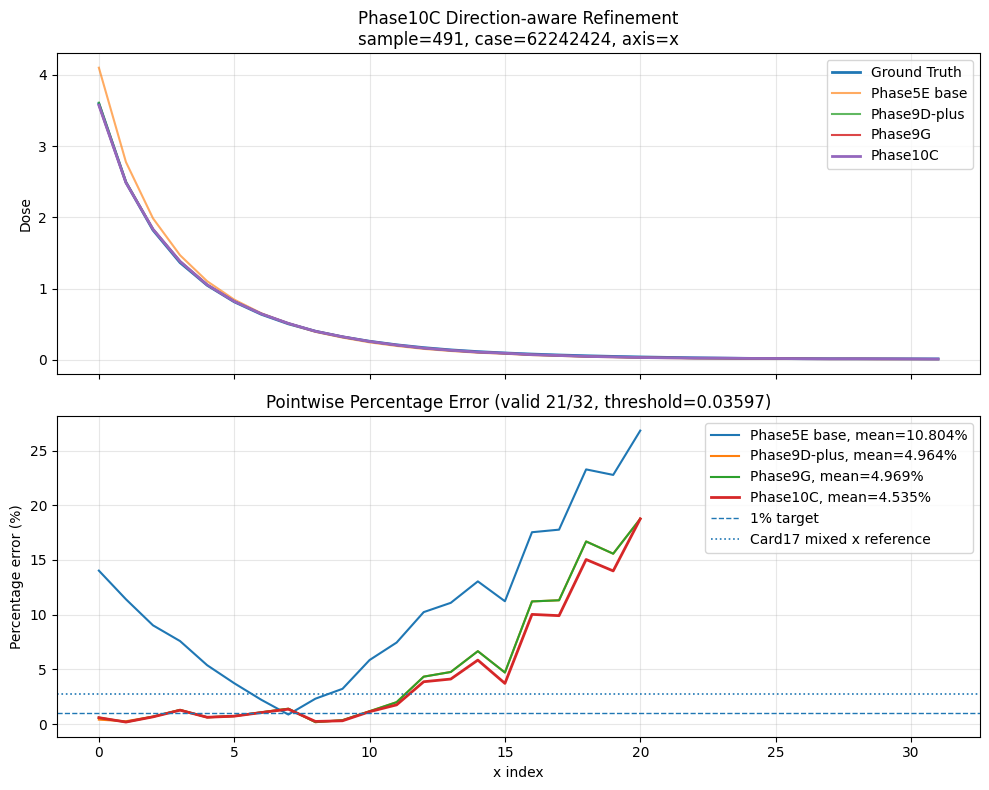

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10c_direction_aware_bounded_refinement/sample0491_case62242424_axisx_phase10c_card17_style.png
Summary:
Base:     mean=10.8043%, max=26.8212%
Phase9D:  mean=4.9641%, max=18.7602%
Phase9G:  mean=4.9690%, max=18.7602%
Phase10C: mean=4.5348%, max=18.7602%


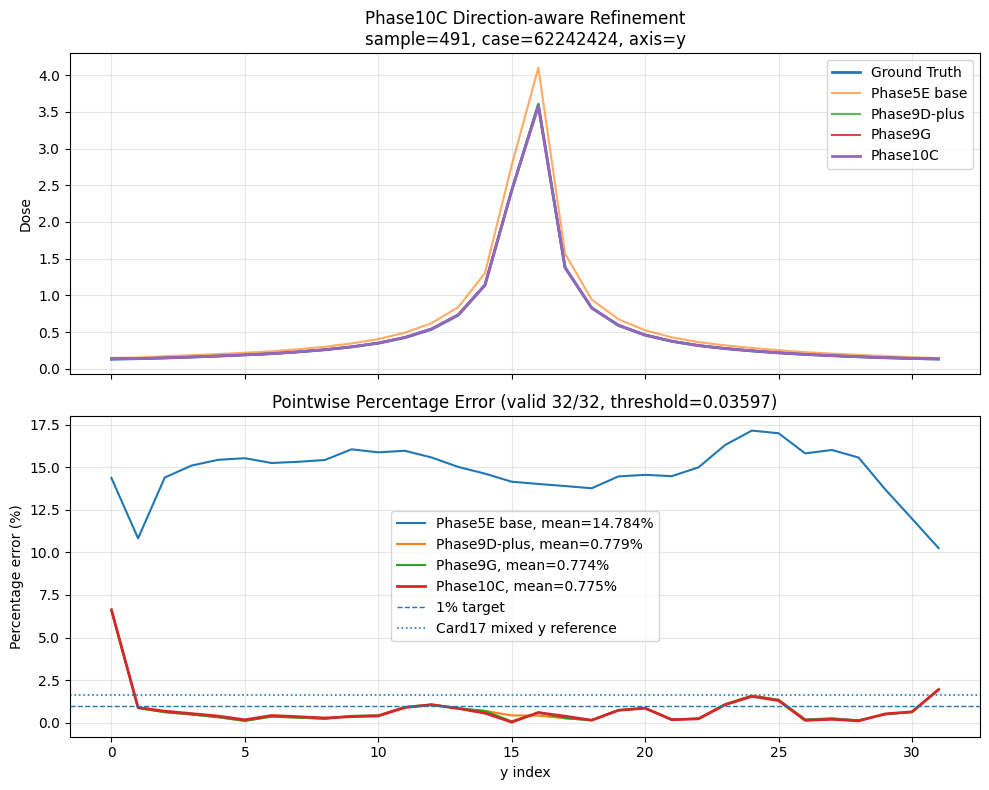

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10c_direction_aware_bounded_refinement/sample0491_case62242424_axisy_phase10c_card17_style.png
Summary:
Base:     mean=14.7845%, max=17.1619%
Phase9D:  mean=0.7789%, max=6.6190%
Phase9G:  mean=0.7738%, max=6.6190%
Phase10C: mean=0.7750%, max=6.6308%


,method,source,along_x_mean_pct,perpendicular_y_mean_pct,delta_vs_card17_mixed_along_x,delta_vs_card17_mixed_perp_y
0,Card17 Phase4 mixed weighted,historical_card17_csv,2.774812,1.614564,0.000000,0.000000
1,Phase9G deployable,current_corrected_pipeline,4.969029,0.773800,2.194217,-0.840764
2,Phase10C direction-aware,phase10c_smoke_test,4.534781,0.774983,1.759969,-0.839581


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10c_direction_aware_bounded_refinement/sample491_phase10c_vs_card17_summary.csv


In [ ]:
# ============================================================
# Run sample491 x/y evaluation
# ============================================================

result_491_x_10c = generate_card17_style_phase10c_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10C_DIR,
)

result_491_y_10c = generate_card17_style_phase10c_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=PHASE10C_DIR,
)

phase10c_sample491_df = pd.DataFrame([
    {
        "method": "Card17 Phase4 mixed weighted",
        "source": "historical_card17_csv",
        "along_x_mean_pct": PHASE10C_CONFIG["card17_mixed_along_x"],
        "perpendicular_y_mean_pct": PHASE10C_CONFIG["card17_mixed_perp_y"],
    },
    {
        "method": "Phase9G deployable",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_10c["phase9g_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10c["phase9g_mean_pct"],
    },
    {
        "method": "Phase10C direction-aware",
        "source": "phase10c_smoke_test",
        "along_x_mean_pct": result_491_x_10c["phase10c_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10c["phase10c_mean_pct"],
    },
])

phase10c_sample491_df["delta_vs_card17_mixed_along_x"] = (
    phase10c_sample491_df["along_x_mean_pct"]
    - PHASE10C_CONFIG["card17_mixed_along_x"]
)

phase10c_sample491_df["delta_vs_card17_mixed_perp_y"] = (
    phase10c_sample491_df["perpendicular_y_mean_pct"]
    - PHASE10C_CONFIG["card17_mixed_perp_y"]
)

display(phase10c_sample491_df)

phase10c_sample491_csv = PHASE10C_DIR / "sample491_phase10c_vs_card17_summary.csv"
phase10c_sample491_df.to_csv(phase10c_sample491_csv, index=False)

print("Saved:", phase10c_sample491_csv)

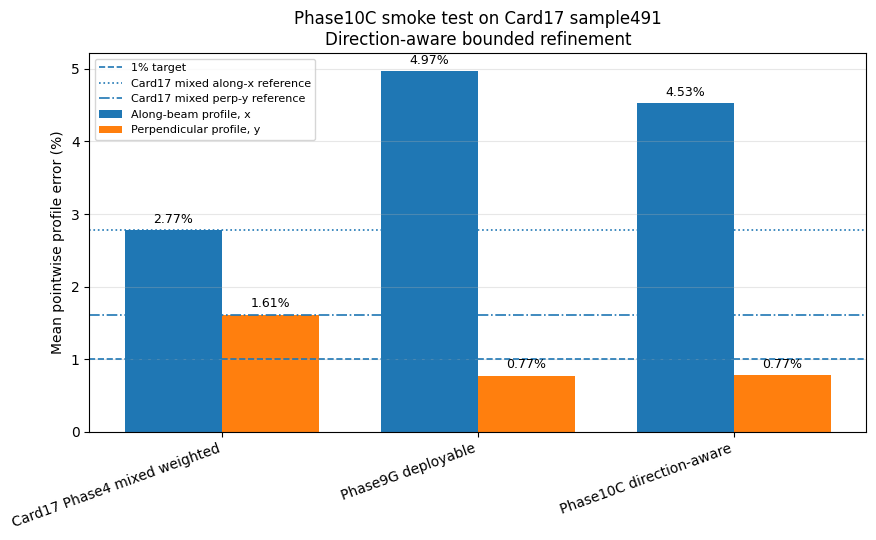

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10c_direction_aware_bounded_refinement/sample491_phase10c_bar_comparison.png


In [ ]:
# ============================================================
# Plot Phase10C sample491 comparison
# ============================================================

plot_df = phase10c_sample491_df.copy()

method_order = [
    "Card17 Phase4 mixed weighted",
    "Phase9G deployable",
    "Phase10C direction-aware",
]

plot_df["method"] = pd.Categorical(
    plot_df["method"],
    categories=method_order,
    ordered=True,
)

plot_df = plot_df.sort_values("method")

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))

bars1 = ax.bar(
    x - width / 2,
    plot_df["along_x_mean_pct"],
    width,
    label="Along-beam profile, x",
)

bars2 = ax.bar(
    x + width / 2,
    plot_df["perpendicular_y_mean_pct"],
    width,
    label="Perpendicular profile, y",
)

ax.axhline(1.0, linestyle="--", linewidth=1.2, label="1% target")

ax.axhline(
    PHASE10C_CONFIG["card17_mixed_along_x"],
    linestyle=":",
    linewidth=1.2,
    label="Card17 mixed along-x reference",
)

ax.axhline(
    PHASE10C_CONFIG["card17_mixed_perp_y"],
    linestyle="-.",
    linewidth=1.2,
    label="Card17 mixed perp-y reference",
)

ax.set_title(
    "Phase10C smoke test on Card17 sample491\n"
    "Direction-aware bounded refinement"
)
ax.set_ylabel("Mean pointwise profile error (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["method"], rotation=20, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.tight_layout()

phase10c_bar_png = PHASE10C_DIR / "sample491_phase10c_bar_comparison.png"
fig.savefig(phase10c_bar_png, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", phase10c_bar_png)

In [ ]:
# ============================================================
# Generate Phase10C Trello summary
# ============================================================

def _get_metric(df, method, col):
    return float(df.loc[df["method"] == method, col].iloc[0])


p9g_x = _get_metric(phase10c_sample491_df, "Phase9G deployable", "along_x_mean_pct")
p9g_y = _get_metric(phase10c_sample491_df, "Phase9G deployable", "perpendicular_y_mean_pct")

p10_x = _get_metric(phase10c_sample491_df, "Phase10C direction-aware", "along_x_mean_pct")
p10_y = _get_metric(phase10c_sample491_df, "Phase10C direction-aware", "perpendicular_y_mean_pct")

card17_x = PHASE10C_CONFIG["card17_mixed_along_x"]
card17_y = PHASE10C_CONFIG["card17_mixed_perp_y"]

text = f"""
Phase10C direction-aware bounded refinement smoke test

Goal:
- Preserve Phase9G's perpendicular/core advantage.
- Improve the remaining along-beam x-profile error.
- Avoid the failure mode of Phase10A, where global x-scale correction destroyed the 3D structure.

Design:
- Input: CT + Phase9G prediction + direction-aware features.
- Added features: x-depth, radial distance, relative dose, dose-region masks, x-gradient, gradient magnitude.
- Output: small bounded residual added to Phase9G.
- Loss: along-beam profile + along-beam slope + perpendicular no-worse + core no-worse + smooth/residual regularization.

Card17 historical reference:
- Phase4 mixed weighted along x: {card17_x:.3f}%
- Phase4 mixed weighted perpendicular y: {card17_y:.3f}%

Phase9G:
- along x: {p9g_x:.3f}%
- perpendicular y: {p9g_y:.3f}%

Phase10C:
- along x: {p10_x:.3f}%
- perpendicular y: {p10_y:.3f}%

Interpretation:
- If Phase10C lowers along x while keeping perpendicular y near Phase9G, then direction-aware bounded refinement is promising.
- If along x does not improve or perpendicular y degrades, then a stronger explicit along-beam branch or better region-aware gating is needed.
"""

print(text)

summary_txt = PHASE10C_DIR / "phase10c_trello_summary.txt"
with open(summary_txt, "w") as f:
    f.write(text)

print("Saved:", summary_txt)


Phase10C direction-aware bounded refinement smoke test

Goal:
- Preserve Phase9G's perpendicular/core advantage.
- Improve the remaining along-beam x-profile error.
- Avoid the failure mode of Phase10A, where global x-scale correction destroyed the 3D structure.

Design:
- Input: CT + Phase9G prediction + direction-aware features.
- Added features: x-depth, radial distance, relative dose, dose-region masks, x-gradient, gradient magnitude.
- Output: small bounded residual added to Phase9G.
- Loss: along-beam profile + along-beam slope + perpendicular no-worse + core no-worse + smooth/residual regularization.

Card17 historical reference:
- Phase4 mixed weighted along x: 2.775%
- Phase4 mixed weighted perpendicular y: 1.615%

Phase9G:
- along x: 4.969%
- perpendicular y: 0.774%

Phase10C:
- along x: 4.535%
- perpendicular y: 0.775%

Interpretation:
- If Phase10C lowers along x while keeping perpendicular y near Phase9G, then direction-aware bounded refinement is promising.
- If along x 

In [ ]:
# ============================================================
# Phase10D: Falloff-aware direction-aware bounded refinement
# Based on Phase10C, but adds falloff/log-profile constraints
# ============================================================

PHASE10D_NAME = "ct2dose_phase10d_falloff_aware_direction_refinement"

PHASE10D_DIR = PHASE9G_FINAL_DIR / PHASE10D_NAME
PHASE10D_DIR.mkdir(parents=True, exist_ok=True)

PHASE10D_CKPT_DIR = CHECKPOINT_DIR
PHASE10D_CKPT_DIR.mkdir(parents=True, exist_ok=True)

PHASE10D_CONFIG = {
    "seed": 42,

    # smoke/intermediate run
    "epochs": 2,
    "lr": 4e-5,
    "weight_decay": 1e-5,
    "max_train_batches": 800,
    "eval_max_batches": 200,

    # base inference
    "euler_steps": int(CONFIG["euler_steps"]),

    # bounded correction: keep conservative
    "delta_scale": 0.008,
    "core_protect_strength": 0.80,
    "tail_protect_strength": 0.25,

    # profile thresholds
    "threshold_frac": float(CONFIG.get("threshold_frac", 0.01)),
    "main_frac": 0.30,
    "core_frac": 0.70,
    "shoulder_low": 0.30,
    "shoulder_high": 0.80,

    # falloff definition on 1D x-profile relative GT
    # falloff region: where gt_x is between 5% and 45% of peak
    "falloff_low_frac": 0.05,
    "falloff_high_frac": 0.45,

    # losses
    "lambda_voxel": 0.4,
    "lambda_along": 2.0,
    "lambda_along_slope": 1.0,
    "lambda_along_log": 2.5,
    "lambda_falloff_log": 4.0,
    "lambda_falloff_no_worse": 4.0,
    "lambda_perp_no_worse": 6.0,
    "lambda_core_no_worse": 3.0,
    "lambda_residual_l1": 0.10,
    "lambda_smooth": 0.08,

    # no-worse margins
    "perp_margin_abs": 0.0004,
    "core_margin_abs": 0.0004,
    "falloff_margin_log": 0.015,

    # model
    "base_ch": 16,

    # references
    "card17_mixed_along_x": 2.774812,
    "card17_mixed_perp_y": 1.614564,
}

torch.manual_seed(PHASE10D_CONFIG["seed"])
np.random.seed(PHASE10D_CONFIG["seed"])

print("PHASE10D_DIR:", PHASE10D_DIR)
print(json.dumps(PHASE10D_CONFIG, indent=2))

PHASE10D_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10d_falloff_aware_direction_refinement
{
  "seed": 42,
  "epochs": 2,
  "lr": 4e-05,
  "weight_decay": 1e-05,
  "max_train_batches": 800,
  "eval_max_batches": 200,
  "euler_steps": 10,
  "delta_scale": 0.008,
  "core_protect_strength": 0.8,
  "tail_protect_strength": 0.25,
  "threshold_frac": 0.01,
  "main_frac": 0.3,
  "core_frac": 0.7,
  "shoulder_low": 0.3,
  "shoulder_high": 0.8,
  "falloff_low_frac": 0.05,
  "falloff_high_frac": 0.45,
  "lambda_voxel": 0.4,
  "lambda_along": 2.0,
  "lambda_along_slope": 1.0,
  "lambda_along_log": 2.5,
  "lambda_falloff_log": 4.0,
  "lambda_falloff_no_worse": 4.0,
  "lambda_perp_no_worse": 6.0,
  "lambda_core_no_worse": 3.0,
  "lambda_residual_l1": 0.1,
  "lambda_smooth": 0.08,
  "perp_margin_abs": 0.0004,
  "core_margin_abs": 0.0004,
  "falloff_margin_log": 0.015,
  "base_ch": 16,
  "card17_mixed

In [ ]:
# ============================================================
# Phase10D model
# Reuses make_phase10c_features(), make_dose_region_features()
# ============================================================

class FalloffAwareBoundedRefineHead3D(nn.Module):
    def __init__(self, in_ch=11, base_ch=16, delta_scale=0.008):
        super().__init__()

        self.delta_scale = float(delta_scale)

        self.trunk = nn.Sequential(
            nn.Conv3d(in_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.delta_head = nn.Conv3d(base_ch, 1, kernel_size=1)

    def forward(self, ct, phase9g_pred):
        feat = make_phase10c_features(ct, phase9g_pred)
        h = self.trunk(feat)

        raw_delta = self.delta_head(h)
        delta = self.delta_scale * torch.tanh(raw_delta)

        rel, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(phase9g_pred)

        correction_mask = torch.ones_like(phase9g_pred)

        # Stronger core protection than Phase10C
        correction_mask = correction_mask * (
            1.0 - PHASE10D_CONFIG["core_protect_strength"] * core_mask
        )

        # Tail can move slightly, but not too freely
        correction_mask = correction_mask * (
            1.0 - PHASE10D_CONFIG["tail_protect_strength"] * tail_mask
        )

        # Allow correction in main + shoulder + controlled tail
        meaningful_region = torch.clamp(
            main_mask + 0.55 * shoulder_mask + 0.25 * tail_mask,
            min=0.0,
            max=1.0,
        )

        correction_mask = correction_mask * meaningful_region

        bounded_delta = correction_mask * delta

        refined = phase9g_pred + bounded_delta
        refined = torch.clamp(refined, min=0.0)

        return refined, {
            "delta": bounded_delta,
            "raw_delta": raw_delta,
            "correction_mask": correction_mask,
        }


phase10d_model = FalloffAwareBoundedRefineHead3D(
    in_ch=11,
    base_ch=PHASE10D_CONFIG["base_ch"],
    delta_scale=PHASE10D_CONFIG["delta_scale"],
).to(device)

optimizer10d = torch.optim.AdamW(
    phase10d_model.parameters(),
    lr=PHASE10D_CONFIG["lr"],
    weight_decay=PHASE10D_CONFIG["weight_decay"],
)

print(phase10d_model)

FalloffAwareBoundedRefineHead3D(
  (trunk): Sequential(
    (0): Conv3d(11, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (2): SiLU()
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): SiLU()
    (6): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (7): GroupNorm(4, 16, eps=1e-05, affine=True)
    (8): SiLU()
    (9): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (10): GroupNorm(4, 16, eps=1e-05, affine=True)
    (11): SiLU()
  )
  (delta_head): Conv3d(16, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
)


In [ ]:
# ============================================================
# Phase10D losses
# ============================================================

def central_profiles_torch(v):
    B, C, D, H, W = v.shape
    cx, cy, cz = D // 2, H // 2, W // 2

    px = v[:, 0, :, cy, cz]
    py = v[:, 0, cx, :, cz]
    pz = v[:, 0, cx, cy, :]

    return px, py, pz


def masked_profile_l1(pred_p, gt_p, threshold_frac=0.01):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    err = torch.abs(pred_p - gt_p) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def profile_slope_l1(pred_p, gt_p, threshold_frac=0.01):
    dp = pred_p[:, 1:] - pred_p[:, :-1]
    dg = gt_p[:, 1:] - gt_p[:, :-1]

    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = ((gt_p[:, 1:] > thr) | (gt_p[:, :-1] > thr)).float()

    err = torch.abs(dp - dg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def no_worse_profile_loss(new_p, old_p, gt_p, margin_abs=0.0004, threshold_frac=0.01):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    old_err = torch.abs(old_p - gt_p)
    new_err = torch.abs(new_p - gt_p)

    penalty = F.relu(new_err - old_err - margin_abs) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def log_profile_l1(pred_p, gt_p, threshold_frac=0.01, eps=1e-4):
    """
    Relative-error-like loss for profile.
    More suitable for falloff region than plain L1.
    """
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    lp = torch.log(torch.clamp(pred_p, min=eps))
    lg = torch.log(torch.clamp(gt_p, min=eps))

    err = torch.abs(lp - lg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def falloff_mask_from_gt_profile(gt_p):
    """
    Falloff region on x-profile:
    gt between low_frac and high_frac of peak.
    """
    maxv = gt_p.max(dim=1, keepdim=True).values
    rel = gt_p / torch.clamp(maxv, min=1e-8)

    mask = (
        (rel >= PHASE10D_CONFIG["falloff_low_frac"])
        & (rel <= PHASE10D_CONFIG["falloff_high_frac"])
    ).float()

    return mask


def falloff_log_loss(pred_x, gt_x, eps=1e-4):
    mask = falloff_mask_from_gt_profile(gt_x)

    lp = torch.log(torch.clamp(pred_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    err = torch.abs(lp - lg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def falloff_no_worse_log_loss(new_x, old_x, gt_x, eps=1e-4):
    """
    Penalize if new log-profile error is worse than Phase9G
    specifically in falloff region.
    """
    mask = falloff_mask_from_gt_profile(gt_x)

    ln = torch.log(torch.clamp(new_x, min=eps))
    lo = torch.log(torch.clamp(old_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    new_err = torch.abs(ln - lg)
    old_err = torch.abs(lo - lg)

    penalty = F.relu(
        new_err - old_err - PHASE10D_CONFIG["falloff_margin_log"]
    ) * mask

    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def smoothness_loss_3d(delta):
    gx = torch.abs(delta[:, :, 1:] - delta[:, :, :-1]).mean()
    gy = torch.abs(delta[:, :, :, 1:] - delta[:, :, :, :-1]).mean()
    gz = torch.abs(delta[:, :, :, :, 1:] - delta[:, :, :, :, :-1]).mean()
    return gx + gy + gz


def phase10d_loss(refined, phase9g_pred, gt, aux):
    voxel_l1 = torch.mean(torch.abs(refined - gt))

    new_x, new_y, new_z = central_profiles_torch(refined)
    old_x, old_y, old_z = central_profiles_torch(phase9g_pred)
    gt_x, gt_y, gt_z = central_profiles_torch(gt)

    along_loss = masked_profile_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10D_CONFIG["threshold_frac"],
    )

    along_slope = profile_slope_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10D_CONFIG["threshold_frac"],
    )

    along_log = log_profile_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10D_CONFIG["threshold_frac"],
    )

    falloff_log = falloff_log_loss(new_x, gt_x)

    falloff_noworse = falloff_no_worse_log_loss(
        new_x,
        old_x,
        gt_x,
    )

    perp_noworse_y = no_worse_profile_loss(
        new_y,
        old_y,
        gt_y,
        margin_abs=PHASE10D_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE10D_CONFIG["threshold_frac"],
    )

    perp_noworse_z = no_worse_profile_loss(
        new_z,
        old_z,
        gt_z,
        margin_abs=PHASE10D_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE10D_CONFIG["threshold_frac"],
    )

    perp_noworse = 0.5 * (perp_noworse_y + perp_noworse_z)

    rel_gt, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(gt)

    old_core_err = torch.abs(phase9g_pred - gt)
    new_core_err = torch.abs(refined - gt)

    core_penalty = F.relu(
        new_core_err - old_core_err - PHASE10D_CONFIG["core_margin_abs"]
    ) * core_mask

    core_noworse = core_penalty.sum() / torch.clamp(core_mask.sum(), min=1.0)

    residual_l1 = torch.mean(torch.abs(aux["delta"]))
    smooth = smoothness_loss_3d(aux["delta"])

    total = (
        PHASE10D_CONFIG["lambda_voxel"] * voxel_l1
        + PHASE10D_CONFIG["lambda_along"] * along_loss
        + PHASE10D_CONFIG["lambda_along_slope"] * along_slope
        + PHASE10D_CONFIG["lambda_along_log"] * along_log
        + PHASE10D_CONFIG["lambda_falloff_log"] * falloff_log
        + PHASE10D_CONFIG["lambda_falloff_no_worse"] * falloff_noworse
        + PHASE10D_CONFIG["lambda_perp_no_worse"] * perp_noworse
        + PHASE10D_CONFIG["lambda_core_no_worse"] * core_noworse
        + PHASE10D_CONFIG["lambda_residual_l1"] * residual_l1
        + PHASE10D_CONFIG["lambda_smooth"] * smooth
    )

    return total, {
        "total": total.detach().item(),
        "voxel_l1": voxel_l1.detach().item(),
        "along_loss": along_loss.detach().item(),
        "along_slope": along_slope.detach().item(),
        "along_log": along_log.detach().item(),
        "falloff_log": falloff_log.detach().item(),
        "falloff_noworse": falloff_noworse.detach().item(),
        "perp_noworse": perp_noworse.detach().item(),
        "core_noworse": core_noworse.detach().item(),
        "residual_l1": residual_l1.detach().item(),
        "smooth": smooth.detach().item(),
    }

In [ ]:
# ============================================================
# Phase10D prediction wrapper
# ============================================================

@torch.no_grad()
def predict_phase10d(ct, steps=None):
    if steps is None:
        steps = PHASE10D_CONFIG["euler_steps"]

    base_model.eval()
    model_9d_plus.eval()
    phase10d_model.eval()

    preds9 = predict_phase9g(ct, steps=steps)

    phase9g_pred = preds9["phase9g_pred"]

    refined, aux = phase10d_model(
        ct,
        phase9g_pred,
    )

    preds9["phase10d_pred"] = refined
    preds9["phase10d_aux"] = aux

    return preds9

In [ ]:
# ============================================================
# Phase10D train / eval loops
# ============================================================

def average_stats(stats_list):
    if len(stats_list) == 0:
        return {}

    keys = stats_list[0].keys()
    return {k: float(np.mean([s[k] for s in stats_list])) for k in keys}


def run_phase10d_train_epoch(epoch):
    phase10d_model.train()
    base_model.eval()
    model_9d_plus.eval()

    stats_list = []
    t0 = time.time()

    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= PHASE10D_CONFIG["max_train_batches"]:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        with torch.no_grad():
            preds9 = predict_phase9g(
                ct,
                steps=PHASE10D_CONFIG["euler_steps"],
            )
            phase9g_pred = preds9["phase9g_pred"]

        refined, aux = phase10d_model(ct, phase9g_pred)

        loss, stats = phase10d_loss(
            refined,
            phase9g_pred,
            gt,
            aux,
        )

        optimizer10d.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(phase10d_model.parameters(), max_norm=1.0)
        optimizer10d.step()

        stats_list.append(stats)

        if (batch_idx + 1) % 50 == 0:
            avg = average_stats(stats_list[-50:])
            print(
                f"epoch {epoch} batch {batch_idx+1} | "
                f"loss={avg['total']:.6f} | "
                f"along={avg['along_loss']:.6f} | "
                f"log={avg['along_log']:.6f} | "
                f"falloff={avg['falloff_log']:.6f} | "
                f"perpNW={avg['perp_noworse']:.6f} | "
                f"res={avg['residual_l1']:.6f}"
            )

    out = average_stats(stats_list)
    out["elapsed_min"] = (time.time() - t0) / 60.0

    return out


@torch.no_grad()
def evaluate_phase10d_profile_metrics(loader, max_batches=200):
    phase10d_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        preds9 = predict_phase9g(
            ct,
            steps=PHASE10D_CONFIG["euler_steps"],
        )

        phase9g_pred = preds9["phase9g_pred"]
        refined, aux = phase10d_model(ct, phase9g_pred)

        B = ct.shape[0]

        for b in range(B):
            p9_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
            p10_profiles = extract_axis_profiles(refined[b], gt[b])

            for axis in ["x", "y", "z"]:
                gt_p = p9_profiles[axis]["gt"]

                p9_p = p9_profiles[axis]["pred"]
                p10_p = p10_profiles[axis]["pred"]

                _, p9_mean, p9_max, valid_count, thr = percentage_error_curve(
                    p9_p,
                    gt_p,
                    threshold_frac=PHASE10D_CONFIG["threshold_frac"],
                )

                _, p10_mean, p10_max, _, _ = percentage_error_curve(
                    p10_p,
                    gt_p,
                    threshold_frac=PHASE10D_CONFIG["threshold_frac"],
                )

                rows.append({
                    "batch_idx": batch_idx,
                    "sample_local_idx": b,
                    "axis": axis,
                    "phase9g_mean_pct": p9_mean,
                    "phase10d_mean_pct": p10_mean,
                    "phase9g_max_pct": p9_max,
                    "phase10d_max_pct": p10_max,
                    "delta_mean_pct": p10_mean - p9_mean,
                    "valid_count": valid_count,
                    "threshold": thr,
                })

        if (batch_idx + 1) % 20 == 0:
            print(f"eval processed batches: {batch_idx+1}")

    casewise_df = pd.DataFrame(rows)

    summary_df = (
        casewise_df
        .groupby("axis")
        .agg(
            phase9g_mean_pct=("phase9g_mean_pct", "mean"),
            phase10d_mean_pct=("phase10d_mean_pct", "mean"),
            delta_mean_pct=("delta_mean_pct", "mean"),
            phase9g_max_pct=("phase9g_max_pct", "mean"),
            phase10d_max_pct=("phase10d_max_pct", "mean"),
        )
        .reset_index()
    )

    return casewise_df, summary_df

In [ ]:
# ============================================================
# Train Phase10D
# ============================================================

training_rows_10d = []
best_score_10d = float("inf")
best_epoch_10d = None

best_ckpt_path_10d = PHASE10D_CKPT_DIR / f"{PHASE10D_NAME}_seed42_best.pt"
latest_ckpt_path_10d = PHASE10D_CKPT_DIR / f"{PHASE10D_NAME}_seed42_latest.pt"

for epoch in range(1, PHASE10D_CONFIG["epochs"] + 1):
    print("=" * 100)
    print(f"Phase10D Epoch {epoch}/{PHASE10D_CONFIG['epochs']}")

    train_stats = run_phase10d_train_epoch(epoch)

    val_casewise, val_summary = evaluate_phase10d_profile_metrics(
        val_loader,
        max_batches=PHASE10D_CONFIG["eval_max_batches"],
    )

    display(val_summary)

    x_row = val_summary[val_summary["axis"] == "x"].iloc[0]
    y_row = val_summary[val_summary["axis"] == "y"].iloc[0]
    z_row = val_summary[val_summary["axis"] == "z"].iloc[0]

    # Selection:
    # Prefer lower x, strongly penalize y/z degradation.
    score = (
        x_row["phase10d_mean_pct"]
        + 4.0 * max(0.0, y_row["phase10d_mean_pct"] - y_row["phase9g_mean_pct"])
        + 4.0 * max(0.0, z_row["phase10d_mean_pct"] - z_row["phase9g_mean_pct"])
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_stats.items()},
        "score": float(score),
    }

    for _, r in val_summary.iterrows():
        axis = r["axis"]
        row[f"val_{axis}_phase9g_mean_pct"] = r["phase9g_mean_pct"]
        row[f"val_{axis}_phase10d_mean_pct"] = r["phase10d_mean_pct"]
        row[f"val_{axis}_delta_mean_pct"] = r["delta_mean_pct"]

    training_rows_10d.append(row)

    log_df_10d = pd.DataFrame(training_rows_10d)
    display(log_df_10d.tail(1))

    torch.save(
        {
            "model_state_dict": phase10d_model.state_dict(),
            "optimizer_state_dict": optimizer10d.state_dict(),
            "config": PHASE10D_CONFIG,
            "epoch": epoch,
            "row": row,
        },
        latest_ckpt_path_10d,
    )

    if score < best_score_10d:
        best_score_10d = float(score)
        best_epoch_10d = epoch

        torch.save(
            {
                "model_state_dict": phase10d_model.state_dict(),
                "optimizer_state_dict": optimizer10d.state_dict(),
                "config": PHASE10D_CONFIG,
                "epoch": epoch,
                "row": row,
                "best_score": best_score_10d,
            },
            best_ckpt_path_10d,
        )

        print(f"New best saved: epoch={epoch}, score={best_score_10d:.6f}")

training_log_df_10d = pd.DataFrame(training_rows_10d)

training_log_csv_10d = PHASE10D_DIR / f"{PHASE10D_NAME}_training_log.csv"
training_log_df_10d.to_csv(training_log_csv_10d, index=False)

print("Finished Phase10D.")
print("Best epoch:", best_epoch_10d)
print("Best score:", best_score_10d)
print("Saved:", training_log_csv_10d)
print("Best ckpt:", best_ckpt_path_10d)

Phase10D Epoch 1/2
epoch 1 batch 50 | loss=0.749378 | along=0.003117 | log=0.110834 | falloff=0.115259 | perpNW=0.000080 | res=0.000187
epoch 1 batch 100 | loss=0.737125 | along=0.003249 | log=0.113316 | falloff=0.110654 | perpNW=0.000066 | res=0.000177
epoch 1 batch 150 | loss=0.699340 | along=0.003047 | log=0.101746 | falloff=0.108495 | perpNW=0.000048 | res=0.000175
epoch 1 batch 200 | loss=0.750492 | along=0.003029 | log=0.111250 | falloff=0.115303 | perpNW=0.000045 | res=0.000186
epoch 1 batch 250 | loss=0.772906 | along=0.003198 | log=0.113427 | falloff=0.119236 | perpNW=0.000060 | res=0.000213
epoch 1 batch 300 | loss=0.784836 | along=0.003074 | log=0.114174 | falloff=0.121689 | perpNW=0.000073 | res=0.000235
epoch 1 batch 350 | loss=0.780924 | along=0.003114 | log=0.115404 | falloff=0.119954 | perpNW=0.000080 | res=0.000199
epoch 1 batch 400 | loss=0.848104 | along=0.003118 | log=0.117541 | falloff=0.135299 | perpNW=0.000069 | res=0.000204
epoch 1 batch 450 | loss=0.732610 | al

,axis,phase9g_mean_pct,phase10d_mean_pct,delta_mean_pct,phase9g_max_pct,phase10d_max_pct
0,x,7.462334,7.182766,-0.279568,23.419526,23.056390
1,y,2.406719,2.413225,0.006505,9.430084,9.532969
2,z,2.367126,2.314298,-0.052828,8.582602,8.396644


,epoch,train_total,train_voxel_l1,train_along_loss,train_along_slope,train_along_log,train_falloff_log,train_falloff_noworse,train_perp_noworse,train_core_noworse,...,score,val_x_phase9g_mean_pct,val_x_phase10d_mean_pct,val_x_delta_mean_pct,val_y_phase9g_mean_pct,val_y_phase10d_mean_pct,val_y_delta_mean_pct,val_z_phase9g_mean_pct,val_z_phase10d_mean_pct,val_z_delta_mean_pct
0,1,0.758337,0.003019,0.003072,0.002354,0.111036,0.117086,0.00056,0.000066,0.000007,...,7.208787,7.462334,7.182766,-0.279568,2.406719,2.413225,0.006505,2.367126,2.314298,-0.052828


New best saved: epoch=1, score=7.208787
Phase10D Epoch 2/2
epoch 2 batch 50 | loss=0.809209 | along=0.002945 | log=0.116632 | falloff=0.126519 | perpNW=0.000053 | res=0.000214
epoch 2 batch 100 | loss=0.778942 | along=0.003143 | log=0.117019 | falloff=0.118398 | perpNW=0.000050 | res=0.000245
epoch 2 batch 150 | loss=0.741809 | along=0.003233 | log=0.110130 | falloff=0.113138 | perpNW=0.000060 | res=0.000221
epoch 2 batch 200 | loss=0.737040 | along=0.003149 | log=0.105326 | falloff=0.115307 | perpNW=0.000053 | res=0.000203
epoch 2 batch 250 | loss=0.690420 | along=0.002800 | log=0.095664 | falloff=0.109496 | perpNW=0.000066 | res=0.000233
epoch 2 batch 300 | loss=0.716885 | along=0.002766 | log=0.104796 | falloff=0.110535 | perpNW=0.000053 | res=0.000238
epoch 2 batch 350 | loss=0.751161 | along=0.002854 | log=0.107094 | falloff=0.117758 | perpNW=0.000059 | res=0.000230
epoch 2 batch 400 | loss=0.727004 | along=0.002849 | log=0.108560 | falloff=0.110435 | perpNW=0.000062 | res=0.00024

,axis,phase9g_mean_pct,phase10d_mean_pct,delta_mean_pct,phase9g_max_pct,phase10d_max_pct
0,x,7.462334,7.265478,-0.196856,23.419526,23.202528
1,y,2.406719,2.401764,-0.004955,9.430084,9.484322
2,z,2.367126,2.290303,-0.076824,8.582602,8.345878


,epoch,train_total,train_voxel_l1,train_along_loss,train_along_slope,train_along_log,train_falloff_log,train_falloff_noworse,train_perp_noworse,train_core_noworse,...,score,val_x_phase9g_mean_pct,val_x_phase10d_mean_pct,val_x_delta_mean_pct,val_y_phase9g_mean_pct,val_y_phase10d_mean_pct,val_y_delta_mean_pct,val_z_phase9g_mean_pct,val_z_phase10d_mean_pct,val_z_delta_mean_pct
1,2,0.749974,0.002981,0.002952,0.002285,0.108781,0.116309,0.00076,0.000053,0.000001,...,7.265478,7.462334,7.265478,-0.196856,2.406719,2.401764,-0.004955,2.367126,2.290303,-0.076824


Finished Phase10D.
Best epoch: 1
Best score: 7.208786965866782
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10d_falloff_aware_direction_refinement/ct2dose_phase10d_falloff_aware_direction_refinement_training_log.csv
Best ckpt: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase10d_falloff_aware_direction_refinement_seed42_best.pt


In [ ]:
# ============================================================
# Load best Phase10D checkpoint
# ============================================================

best_ckpt_10d = torch.load(best_ckpt_path_10d, map_location=device)

phase10d_model.load_state_dict(best_ckpt_10d["model_state_dict"], strict=True)
phase10d_model.eval()

print("Loaded best Phase10D checkpoint:")
print(best_ckpt_path_10d)
print("Best epoch:", best_ckpt_10d.get("epoch"))
print("Best score:", best_ckpt_10d.get("best_score"))

Loaded best Phase10D checkpoint:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase10d_falloff_aware_direction_refinement_seed42_best.pt
Best epoch: 1
Best score: 7.208786965866782


In [ ]:
# ============================================================
# Generate Card17-style Phase10D figure
# ============================================================

@torch.no_grad()
def generate_card17_style_phase10d_figure(
    loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10D_DIR,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    phase10d_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    global_idx = 0

    for batch_idx, batch in enumerate(loader):
        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)
        case_ids = batch.get("case_id", ["unknown"] * ct.shape[0])

        preds9 = predict_phase9g(ct, steps=PHASE10D_CONFIG["euler_steps"])

        base_pred = preds9["base_pred"]
        phase9d_pred = preds9["phase9d_pred"]
        phase9g_pred = preds9["phase9g_pred"]

        phase10d_pred, aux = phase10d_model(ct, phase9g_pred)

        for b in range(ct.shape[0]):
            if global_idx == sample_index_to_plot:
                case_id = case_ids[b] if isinstance(case_ids, list) else str(case_ids[b])

                base_profiles = extract_axis_profiles(base_pred[b], gt[b])
                phase9d_profiles = extract_axis_profiles(phase9d_pred[b], gt[b])
                phase9g_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
                phase10d_profiles = extract_axis_profiles(phase10d_pred[b], gt[b])

                gt_p = phase9g_profiles[axis_to_plot]["gt"]

                base_p = base_profiles[axis_to_plot]["pred"]
                phase9d_p = phase9d_profiles[axis_to_plot]["pred"]
                phase9g_p = phase9g_profiles[axis_to_plot]["pred"]
                phase10d_p = phase10d_profiles[axis_to_plot]["pred"]

                base_pct, base_mean, base_max, valid_count, thr = percentage_error_curve(
                    base_p,
                    gt_p,
                    threshold_frac=PHASE10D_CONFIG["threshold_frac"],
                )

                phase9d_pct, phase9d_mean, phase9d_max, _, _ = percentage_error_curve(
                    phase9d_p,
                    gt_p,
                    threshold_frac=PHASE10D_CONFIG["threshold_frac"],
                )

                phase9g_pct, phase9g_mean, phase9g_max, _, _ = percentage_error_curve(
                    phase9g_p,
                    gt_p,
                    threshold_frac=PHASE10D_CONFIG["threshold_frac"],
                )

                phase10d_pct, phase10d_mean, phase10d_max, _, _ = percentage_error_curve(
                    phase10d_p,
                    gt_p,
                    threshold_frac=PHASE10D_CONFIG["threshold_frac"],
                )

                x = np.arange(len(gt_p))

                fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

                axes[0].plot(x, gt_p, label="Ground Truth", linewidth=2)
                axes[0].plot(x, base_p, label="Phase5E base", alpha=0.65)
                axes[0].plot(x, phase9d_p, label="Phase9D-plus", alpha=0.75)
                axes[0].plot(x, phase9g_p, label="Phase9G", alpha=0.85)
                axes[0].plot(x, phase10d_p, label="Phase10D", linewidth=2)

                axes[0].set_title(
                    f"Phase10D Falloff-aware Direction Refinement\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}, axis={axis_to_plot}"
                )
                axes[0].set_ylabel("Dose")
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                axes[1].plot(x, base_pct, label=f"Phase5E base, mean={base_mean:.3f}%")
                axes[1].plot(x, phase9d_pct, label=f"Phase9D-plus, mean={phase9d_mean:.3f}%")
                axes[1].plot(x, phase9g_pct, label=f"Phase9G, mean={phase9g_mean:.3f}%")
                axes[1].plot(x, phase10d_pct, label=f"Phase10D, mean={phase10d_mean:.3f}%", linewidth=2)

                axes[1].axhline(1.0, linestyle="--", linewidth=1, label="1% target")

                if axis_to_plot == "x":
                    axes[1].axhline(
                        PHASE10D_CONFIG["card17_mixed_along_x"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed x reference",
                    )

                if axis_to_plot == "y":
                    axes[1].axhline(
                        PHASE10D_CONFIG["card17_mixed_perp_y"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed y reference",
                    )

                axes[1].set_title(
                    f"Pointwise Percentage Error "
                    f"(valid {valid_count}/{len(gt_p)}, threshold={thr:.5f})"
                )
                axes[1].set_xlabel(f"{axis_to_plot} index")
                axes[1].set_ylabel("Percentage error (%)")
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                fig.tight_layout()

                out_path = save_dir / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_axis{axis_to_plot}_phase10d_card17_style.png"
                )

                fig.savefig(out_path, dpi=220, bbox_inches="tight")
                plt.show()

                print("Saved:", out_path)
                print("Summary:")
                print(f"Base:     mean={base_mean:.4f}%, max={base_max:.4f}%")
                print(f"Phase9D:  mean={phase9d_mean:.4f}%, max={phase9d_max:.4f}%")
                print(f"Phase9G:  mean={phase9g_mean:.4f}%, max={phase9g_max:.4f}%")
                print(f"Phase10D: mean={phase10d_mean:.4f}%, max={phase10d_max:.4f}%")

                return {
                    "path": out_path,
                    "sample_idx": sample_index_to_plot,
                    "case_id": case_id,
                    "axis": axis_to_plot,
                    "base_mean_pct": base_mean,
                    "phase9d_mean_pct": phase9d_mean,
                    "phase9g_mean_pct": phase9g_mean,
                    "phase10d_mean_pct": phase10d_mean,
                    "base_max_pct": base_max,
                    "phase9d_max_pct": phase9d_max,
                    "phase9g_max_pct": phase9g_max,
                    "phase10d_max_pct": phase10d_max,
                }

            global_idx += 1

    raise ValueError(f"sample_index_to_plot={sample_index_to_plot} not found.")

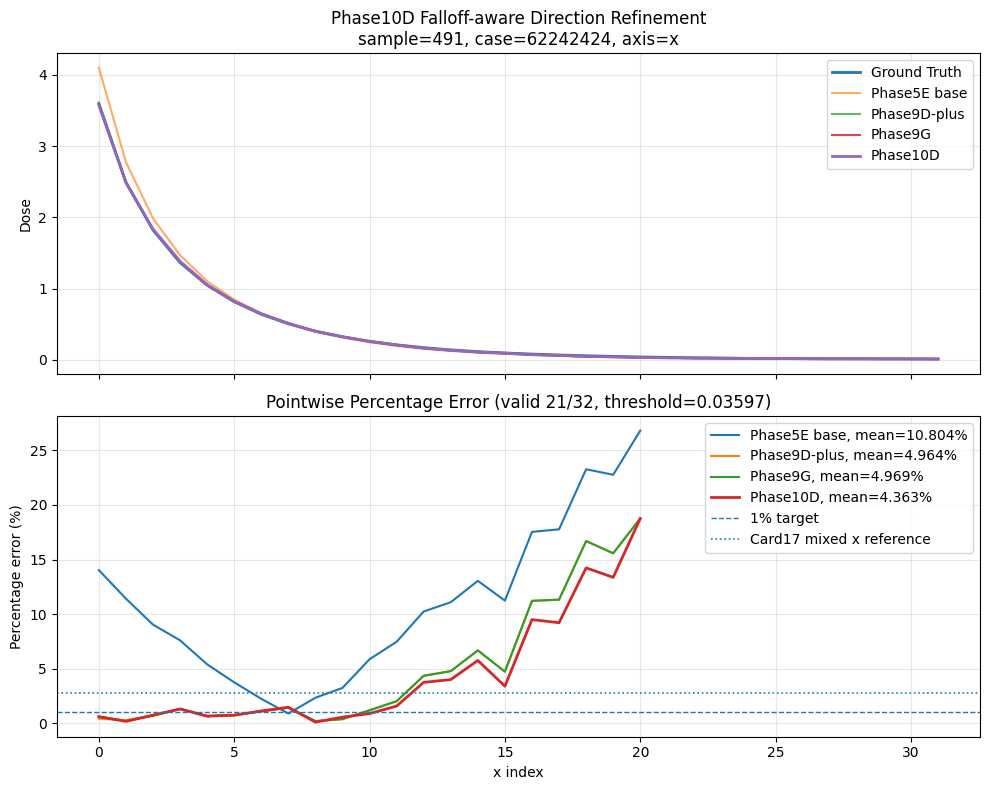

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10d_falloff_aware_direction_refinement/sample0491_case62242424_axisx_phase10d_card17_style.png
Summary:
Base:     mean=10.8043%, max=26.8212%
Phase9D:  mean=4.9641%, max=18.7602%
Phase9G:  mean=4.9690%, max=18.7602%
Phase10D: mean=4.3634%, max=18.7602%


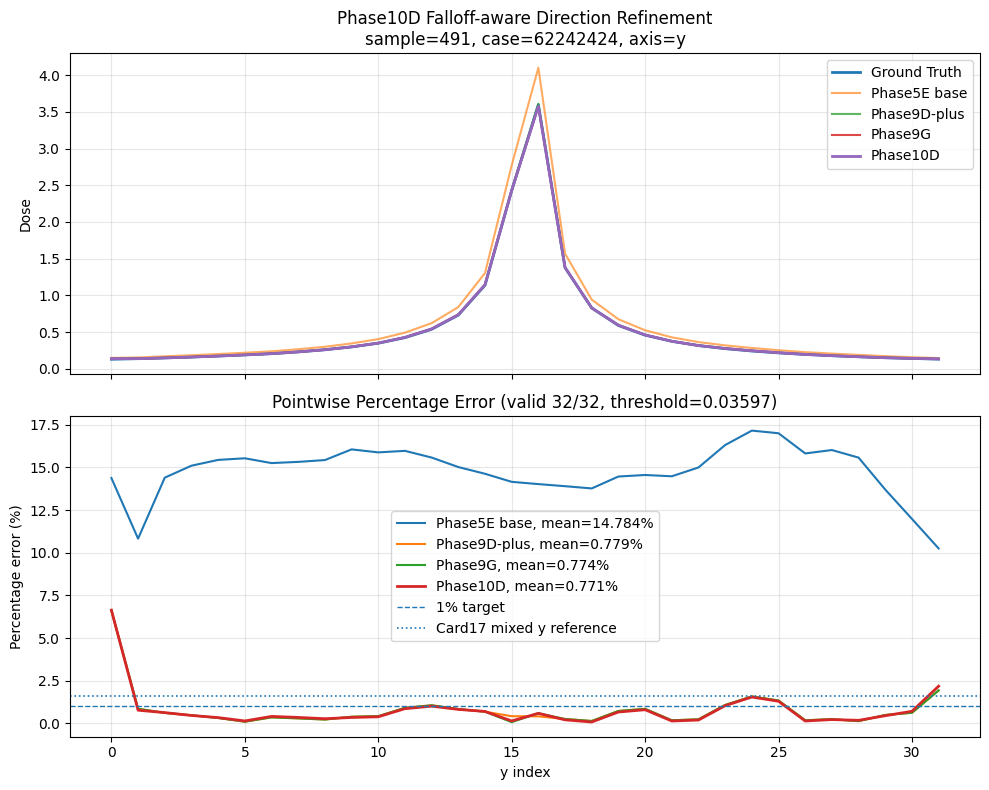

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10d_falloff_aware_direction_refinement/sample0491_case62242424_axisy_phase10d_card17_style.png
Summary:
Base:     mean=14.7845%, max=17.1619%
Phase9D:  mean=0.7789%, max=6.6190%
Phase9G:  mean=0.7738%, max=6.6190%
Phase10D: mean=0.7706%, max=6.6368%


,method,source,along_x_mean_pct,perpendicular_y_mean_pct,delta_vs_card17_mixed_along_x,delta_vs_card17_mixed_perp_y
0,Card17 Phase4 mixed weighted,historical_card17_csv,2.774812,1.614564,0.000000,0.000000
1,Phase9G deployable,current_corrected_pipeline,4.969029,0.773800,2.194217,-0.840764
2,Phase10D falloff-aware,phase10d,4.363384,0.770616,1.588572,-0.843948


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10d_falloff_aware_direction_refinement/sample491_phase10d_vs_card17_summary.csv


In [ ]:
# ============================================================
# Run sample491 x/y evaluation for Phase10D
# ============================================================

result_491_x_10d = generate_card17_style_phase10d_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10D_DIR,
)

result_491_y_10d = generate_card17_style_phase10d_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=PHASE10D_DIR,
)

phase10d_sample491_df = pd.DataFrame([
    {
        "method": "Card17 Phase4 mixed weighted",
        "source": "historical_card17_csv",
        "along_x_mean_pct": PHASE10D_CONFIG["card17_mixed_along_x"],
        "perpendicular_y_mean_pct": PHASE10D_CONFIG["card17_mixed_perp_y"],
    },
    {
        "method": "Phase9G deployable",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_10d["phase9g_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10d["phase9g_mean_pct"],
    },
    {
        "method": "Phase10D falloff-aware",
        "source": "phase10d",
        "along_x_mean_pct": result_491_x_10d["phase10d_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10d["phase10d_mean_pct"],
    },
])

phase10d_sample491_df["delta_vs_card17_mixed_along_x"] = (
    phase10d_sample491_df["along_x_mean_pct"]
    - PHASE10D_CONFIG["card17_mixed_along_x"]
)

phase10d_sample491_df["delta_vs_card17_mixed_perp_y"] = (
    phase10d_sample491_df["perpendicular_y_mean_pct"]
    - PHASE10D_CONFIG["card17_mixed_perp_y"]
)

display(phase10d_sample491_df)

phase10d_sample491_csv = PHASE10D_DIR / "sample491_phase10d_vs_card17_summary.csv"
phase10d_sample491_df.to_csv(phase10d_sample491_csv, index=False)

print("Saved:", phase10d_sample491_csv)

In [ ]:
# ============================================================
# Phase10E: Dual-branch gated direction-aware refinement
# Goal:
#   Further improve along-beam x while preserving perpendicular y/z
# ============================================================

PHASE10E_NAME = "ct2dose_phase10e_dual_branch_gated_refinement"

PHASE10E_DIR = PHASE9G_FINAL_DIR / PHASE10E_NAME
PHASE10E_DIR.mkdir(parents=True, exist_ok=True)

PHASE10E_CKPT_DIR = CHECKPOINT_DIR
PHASE10E_CKPT_DIR.mkdir(parents=True, exist_ok=True)

PHASE10E_CONFIG = {
    "seed": 42,

    # smoke test first
    "epochs": 1,
    "lr": 4e-5,
    "weight_decay": 1e-5,
    "max_train_batches": 300,
    "eval_max_batches": 80,

    "euler_steps": int(CONFIG["euler_steps"]),

    # bounded correction
    "along_delta_scale": 0.010,
    "safe_delta_scale": 0.004,

    # region/profile thresholds
    "threshold_frac": float(CONFIG.get("threshold_frac", 0.01)),
    "main_frac": 0.30,
    "core_frac": 0.70,
    "shoulder_low": 0.30,
    "shoulder_high": 0.80,
    "falloff_low_frac": 0.05,
    "falloff_high_frac": 0.45,

    # correction protection
    "core_protect_strength": 0.85,
    "tail_protect_strength": 0.20,

    # losses
    "lambda_voxel": 0.35,
    "lambda_along": 2.0,
    "lambda_along_slope": 1.0,
    "lambda_along_log": 2.5,
    "lambda_falloff_log": 4.5,
    "lambda_falloff_no_worse": 4.0,
    "lambda_perp_no_worse": 7.0,
    "lambda_core_no_worse": 3.5,
    "lambda_residual_l1": 0.10,
    "lambda_smooth": 0.08,
    "lambda_gate_reg": 0.02,

    # margins
    "perp_margin_abs": 0.00035,
    "core_margin_abs": 0.00035,
    "falloff_margin_log": 0.012,

    # model
    "base_ch": 16,

    # reference
    "card17_mixed_along_x": 2.774812,
    "card17_mixed_perp_y": 1.614564,
}

torch.manual_seed(PHASE10E_CONFIG["seed"])
np.random.seed(PHASE10E_CONFIG["seed"])

print("PHASE10E_DIR:", PHASE10E_DIR)
print(json.dumps(PHASE10E_CONFIG, indent=2))

PHASE10E_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10e_dual_branch_gated_refinement
{
  "seed": 42,
  "epochs": 1,
  "lr": 4e-05,
  "weight_decay": 1e-05,
  "max_train_batches": 300,
  "eval_max_batches": 80,
  "euler_steps": 10,
  "along_delta_scale": 0.01,
  "safe_delta_scale": 0.004,
  "threshold_frac": 0.01,
  "main_frac": 0.3,
  "core_frac": 0.7,
  "shoulder_low": 0.3,
  "shoulder_high": 0.8,
  "falloff_low_frac": 0.05,
  "falloff_high_frac": 0.45,
  "core_protect_strength": 0.85,
  "tail_protect_strength": 0.2,
  "lambda_voxel": 0.35,
  "lambda_along": 2.0,
  "lambda_along_slope": 1.0,
  "lambda_along_log": 2.5,
  "lambda_falloff_log": 4.5,
  "lambda_falloff_no_worse": 4.0,
  "lambda_perp_no_worse": 7.0,
  "lambda_core_no_worse": 3.5,
  "lambda_residual_l1": 0.1,
  "lambda_smooth": 0.08,
  "lambda_gate_reg": 0.02,
  "perp_margin_abs": 0.00035,
  "core_margin_abs": 0.00035,
  "fal

In [ ]:
# ============================================================
# Phase10E model: dual-branch gated refinement
# ============================================================

class DualBranchGatedRefineHead3D(nn.Module):
    def __init__(
        self,
        in_ch=11,
        base_ch=16,
        along_delta_scale=0.010,
        safe_delta_scale=0.004,
    ):
        super().__init__()

        self.along_delta_scale = float(along_delta_scale)
        self.safe_delta_scale = float(safe_delta_scale)

        self.shared = nn.Sequential(
            nn.Conv3d(in_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.along_branch = nn.Sequential(
            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.safe_branch = nn.Sequential(
            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.along_delta_head = nn.Conv3d(base_ch, 1, kernel_size=1)
        self.safe_delta_head = nn.Conv3d(base_ch, 1, kernel_size=1)
        self.gate_head = nn.Conv3d(base_ch, 1, kernel_size=1)

    def forward(self, ct, phase9g_pred):
        feat = make_phase10c_features(ct, phase9g_pred)
        h = self.shared(feat)

        h_along = self.along_branch(h)
        h_safe = self.safe_branch(h)

        along_delta = self.along_delta_scale * torch.tanh(self.along_delta_head(h_along))
        safe_delta = self.safe_delta_scale * torch.tanh(self.safe_delta_head(h_safe))

        learned_gate = torch.sigmoid(self.gate_head(h))

        rel, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(phase9g_pred)

        # Falloff-like region prior:
        # Encourage along branch in shoulder / controlled tail,
        # suppress it in high-dose core.
        falloff_prior = torch.clamp(
            0.15 * main_mask + 0.70 * shoulder_mask + 0.45 * tail_mask,
            min=0.0,
            max=1.0,
        )

        core_protection = 1.0 - PHASE10E_CONFIG["core_protect_strength"] * core_mask
        tail_protection = 1.0 - PHASE10E_CONFIG["tail_protect_strength"] * tail_mask

        protection = torch.clamp(core_protection * tail_protection, min=0.0, max=1.0)

        gate = learned_gate * falloff_prior * protection
        gate = torch.clamp(gate, min=0.0, max=1.0)

        delta = gate * along_delta + (1.0 - gate) * safe_delta

        # Extra protection: only allow corrections in meaningful dose regions.
        meaningful_region = torch.clamp(
            main_mask + 0.55 * shoulder_mask + 0.25 * tail_mask,
            min=0.0,
            max=1.0,
        )

        delta = delta * meaningful_region

        refined = phase9g_pred + delta
        refined = torch.clamp(refined, min=0.0)

        return refined, {
            "delta": delta,
            "along_delta": along_delta,
            "safe_delta": safe_delta,
            "gate": gate,
            "learned_gate": learned_gate,
            "falloff_prior": falloff_prior,
        }


phase10e_model = DualBranchGatedRefineHead3D(
    in_ch=11,
    base_ch=PHASE10E_CONFIG["base_ch"],
    along_delta_scale=PHASE10E_CONFIG["along_delta_scale"],
    safe_delta_scale=PHASE10E_CONFIG["safe_delta_scale"],
).to(device)

optimizer10e = torch.optim.AdamW(
    phase10e_model.parameters(),
    lr=PHASE10E_CONFIG["lr"],
    weight_decay=PHASE10E_CONFIG["weight_decay"],
)

print(phase10e_model)

DualBranchGatedRefineHead3D(
  (shared): Sequential(
    (0): Conv3d(11, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (2): SiLU()
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): SiLU()
  )
  (along_branch): Sequential(
    (0): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (2): SiLU()
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): SiLU()
  )
  (safe_branch): Sequential(
    (0): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (2): SiLU()
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): GroupNorm(4, 16, eps=1e-05, affine=Tr

In [ ]:
# ============================================================
# Phase10E losses
# ============================================================

def central_profiles_torch(v):
    B, C, D, H, W = v.shape
    cx, cy, cz = D // 2, H // 2, W // 2

    px = v[:, 0, :, cy, cz]
    py = v[:, 0, cx, :, cz]
    pz = v[:, 0, cx, cy, :]

    return px, py, pz


def masked_profile_l1(pred_p, gt_p, threshold_frac=0.01):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    err = torch.abs(pred_p - gt_p) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def profile_slope_l1(pred_p, gt_p, threshold_frac=0.01):
    dp = pred_p[:, 1:] - pred_p[:, :-1]
    dg = gt_p[:, 1:] - gt_p[:, :-1]

    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv

    mask = ((gt_p[:, 1:] > thr) | (gt_p[:, :-1] > thr)).float()

    err = torch.abs(dp - dg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def no_worse_profile_loss(new_p, old_p, gt_p, margin_abs=0.00035, threshold_frac=0.01):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    old_err = torch.abs(old_p - gt_p)
    new_err = torch.abs(new_p - gt_p)

    penalty = F.relu(new_err - old_err - margin_abs) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def log_profile_l1(pred_p, gt_p, threshold_frac=0.01, eps=1e-4):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    lp = torch.log(torch.clamp(pred_p, min=eps))
    lg = torch.log(torch.clamp(gt_p, min=eps))

    err = torch.abs(lp - lg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def falloff_mask_from_gt_profile_10e(gt_p):
    maxv = gt_p.max(dim=1, keepdim=True).values
    rel = gt_p / torch.clamp(maxv, min=1e-8)

    mask = (
        (rel >= PHASE10E_CONFIG["falloff_low_frac"])
        & (rel <= PHASE10E_CONFIG["falloff_high_frac"])
    ).float()

    return mask


def falloff_log_loss_10e(pred_x, gt_x, eps=1e-4):
    mask = falloff_mask_from_gt_profile_10e(gt_x)

    lp = torch.log(torch.clamp(pred_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    err = torch.abs(lp - lg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def falloff_no_worse_log_loss_10e(new_x, old_x, gt_x, eps=1e-4):
    mask = falloff_mask_from_gt_profile_10e(gt_x)

    ln = torch.log(torch.clamp(new_x, min=eps))
    lo = torch.log(torch.clamp(old_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    new_err = torch.abs(ln - lg)
    old_err = torch.abs(lo - lg)

    penalty = F.relu(
        new_err - old_err - PHASE10E_CONFIG["falloff_margin_log"]
    ) * mask

    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def smoothness_loss_3d(delta):
    gx = torch.abs(delta[:, :, 1:] - delta[:, :, :-1]).mean()
    gy = torch.abs(delta[:, :, :, 1:] - delta[:, :, :, :-1]).mean()
    gz = torch.abs(delta[:, :, :, :, 1:] - delta[:, :, :, :, :-1]).mean()
    return gx + gy + gz


def phase10e_loss(refined, phase9g_pred, gt, aux):
    voxel_l1 = torch.mean(torch.abs(refined - gt))

    new_x, new_y, new_z = central_profiles_torch(refined)
    old_x, old_y, old_z = central_profiles_torch(phase9g_pred)
    gt_x, gt_y, gt_z = central_profiles_torch(gt)

    along_loss = masked_profile_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10E_CONFIG["threshold_frac"],
    )

    along_slope = profile_slope_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10E_CONFIG["threshold_frac"],
    )

    along_log = log_profile_l1(
        new_x,
        gt_x,
        threshold_frac=PHASE10E_CONFIG["threshold_frac"],
    )

    falloff_log = falloff_log_loss_10e(new_x, gt_x)

    falloff_noworse = falloff_no_worse_log_loss_10e(
        new_x,
        old_x,
        gt_x,
    )

    perp_noworse_y = no_worse_profile_loss(
        new_y,
        old_y,
        gt_y,
        margin_abs=PHASE10E_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE10E_CONFIG["threshold_frac"],
    )

    perp_noworse_z = no_worse_profile_loss(
        new_z,
        old_z,
        gt_z,
        margin_abs=PHASE10E_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE10E_CONFIG["threshold_frac"],
    )

    perp_noworse = 0.5 * (perp_noworse_y + perp_noworse_z)

    rel_gt, main_mask, core_mask, shoulder_mask, tail_mask = make_dose_region_features(gt)

    old_core_err = torch.abs(phase9g_pred - gt)
    new_core_err = torch.abs(refined - gt)

    core_penalty = F.relu(
        new_core_err - old_core_err - PHASE10E_CONFIG["core_margin_abs"]
    ) * core_mask

    core_noworse = core_penalty.sum() / torch.clamp(core_mask.sum(), min=1.0)

    residual_l1 = torch.mean(torch.abs(aux["delta"]))
    smooth = smoothness_loss_3d(aux["delta"])

    # Gate regularization:
    # Avoid using the aggressive along branch everywhere.
    gate_reg = aux["gate"].mean()

    total = (
        PHASE10E_CONFIG["lambda_voxel"] * voxel_l1
        + PHASE10E_CONFIG["lambda_along"] * along_loss
        + PHASE10E_CONFIG["lambda_along_slope"] * along_slope
        + PHASE10E_CONFIG["lambda_along_log"] * along_log
        + PHASE10E_CONFIG["lambda_falloff_log"] * falloff_log
        + PHASE10E_CONFIG["lambda_falloff_no_worse"] * falloff_noworse
        + PHASE10E_CONFIG["lambda_perp_no_worse"] * perp_noworse
        + PHASE10E_CONFIG["lambda_core_no_worse"] * core_noworse
        + PHASE10E_CONFIG["lambda_residual_l1"] * residual_l1
        + PHASE10E_CONFIG["lambda_smooth"] * smooth
        + PHASE10E_CONFIG["lambda_gate_reg"] * gate_reg
    )

    return total, {
        "total": total.detach().item(),
        "voxel_l1": voxel_l1.detach().item(),
        "along_loss": along_loss.detach().item(),
        "along_slope": along_slope.detach().item(),
        "along_log": along_log.detach().item(),
        "falloff_log": falloff_log.detach().item(),
        "falloff_noworse": falloff_noworse.detach().item(),
        "perp_noworse": perp_noworse.detach().item(),
        "core_noworse": core_noworse.detach().item(),
        "residual_l1": residual_l1.detach().item(),
        "smooth": smooth.detach().item(),
        "gate_reg": gate_reg.detach().item(),
        "gate_mean": aux["gate"].detach().mean().item(),
        "gate_max": aux["gate"].detach().max().item(),
    }

In [ ]:
# ============================================================
# Phase10E prediction wrapper
# ============================================================

@torch.no_grad()
def predict_phase10e(ct, steps=None):
    if steps is None:
        steps = PHASE10E_CONFIG["euler_steps"]

    base_model.eval()
    model_9d_plus.eval()
    phase10e_model.eval()

    preds9 = predict_phase9g(ct, steps=steps)

    phase9g_pred = preds9["phase9g_pred"]

    refined, aux = phase10e_model(
        ct,
        phase9g_pred,
    )

    preds9["phase10e_pred"] = refined
    preds9["phase10e_aux"] = aux

    return preds9

In [ ]:
# ============================================================
# Phase10E train / eval loops
# ============================================================

def average_stats(stats_list):
    if len(stats_list) == 0:
        return {}

    keys = stats_list[0].keys()
    return {k: float(np.mean([s[k] for s in stats_list])) for k in keys}


def run_phase10e_train_epoch(epoch):
    phase10e_model.train()
    base_model.eval()
    model_9d_plus.eval()

    stats_list = []
    t0 = time.time()

    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= PHASE10E_CONFIG["max_train_batches"]:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        with torch.no_grad():
            preds9 = predict_phase9g(
                ct,
                steps=PHASE10E_CONFIG["euler_steps"],
            )
            phase9g_pred = preds9["phase9g_pred"]

        refined, aux = phase10e_model(ct, phase9g_pred)

        loss, stats = phase10e_loss(
            refined,
            phase9g_pred,
            gt,
            aux,
        )

        optimizer10e.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(phase10e_model.parameters(), max_norm=1.0)
        optimizer10e.step()

        stats_list.append(stats)

        if (batch_idx + 1) % 50 == 0:
            avg = average_stats(stats_list[-50:])
            print(
                f"epoch {epoch} batch {batch_idx+1} | "
                f"loss={avg['total']:.6f} | "
                f"along={avg['along_loss']:.6f} | "
                f"falloff={avg['falloff_log']:.6f} | "
                f"perpNW={avg['perp_noworse']:.6f} | "
                f"gate={avg['gate_mean']:.4f} | "
                f"res={avg['residual_l1']:.6f}"
            )

    out = average_stats(stats_list)
    out["elapsed_min"] = (time.time() - t0) / 60.0

    return out


@torch.no_grad()
def evaluate_phase10e_profile_metrics(loader, max_batches=80):
    phase10e_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        preds9 = predict_phase9g(
            ct,
            steps=PHASE10E_CONFIG["euler_steps"],
        )

        phase9g_pred = preds9["phase9g_pred"]
        refined, aux = phase10e_model(ct, phase9g_pred)

        B = ct.shape[0]

        for b in range(B):
            p9_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
            p10_profiles = extract_axis_profiles(refined[b], gt[b])

            for axis in ["x", "y", "z"]:
                gt_p = p9_profiles[axis]["gt"]

                p9_p = p9_profiles[axis]["pred"]
                p10_p = p10_profiles[axis]["pred"]

                _, p9_mean, p9_max, valid_count, thr = percentage_error_curve(
                    p9_p,
                    gt_p,
                    threshold_frac=PHASE10E_CONFIG["threshold_frac"],
                )

                _, p10_mean, p10_max, _, _ = percentage_error_curve(
                    p10_p,
                    gt_p,
                    threshold_frac=PHASE10E_CONFIG["threshold_frac"],
                )

                rows.append({
                    "batch_idx": batch_idx,
                    "sample_local_idx": b,
                    "axis": axis,
                    "phase9g_mean_pct": p9_mean,
                    "phase10e_mean_pct": p10_mean,
                    "phase9g_max_pct": p9_max,
                    "phase10e_max_pct": p10_max,
                    "delta_mean_pct": p10_mean - p9_mean,
                    "valid_count": valid_count,
                    "threshold": thr,
                })

        if (batch_idx + 1) % 20 == 0:
            print(f"eval processed batches: {batch_idx+1}")

    casewise_df = pd.DataFrame(rows)

    summary_df = (
        casewise_df
        .groupby("axis")
        .agg(
            phase9g_mean_pct=("phase9g_mean_pct", "mean"),
            phase10e_mean_pct=("phase10e_mean_pct", "mean"),
            delta_mean_pct=("delta_mean_pct", "mean"),
            phase9g_max_pct=("phase9g_max_pct", "mean"),
            phase10e_max_pct=("phase10e_max_pct", "mean"),
        )
        .reset_index()
    )

    return casewise_df, summary_df

In [ ]:
# ============================================================
# Train Phase10E
# ============================================================

training_rows_10e = []
best_score_10e = float("inf")
best_epoch_10e = None

best_ckpt_path_10e = PHASE10E_CKPT_DIR / f"{PHASE10E_NAME}_seed42_best.pt"
latest_ckpt_path_10e = PHASE10E_CKPT_DIR / f"{PHASE10E_NAME}_seed42_latest.pt"

for epoch in range(1, PHASE10E_CONFIG["epochs"] + 1):
    print("=" * 100)
    print(f"Phase10E Epoch {epoch}/{PHASE10E_CONFIG['epochs']}")

    train_stats = run_phase10e_train_epoch(epoch)

    val_casewise, val_summary = evaluate_phase10e_profile_metrics(
        val_loader,
        max_batches=PHASE10E_CONFIG["eval_max_batches"],
    )

    display(val_summary)

    x_row = val_summary[val_summary["axis"] == "x"].iloc[0]
    y_row = val_summary[val_summary["axis"] == "y"].iloc[0]
    z_row = val_summary[val_summary["axis"] == "z"].iloc[0]

    # Selection:
    # Minimize x, but strongly punish y/z worsening.
    score = (
        x_row["phase10e_mean_pct"]
        + 5.0 * max(0.0, y_row["phase10e_mean_pct"] - y_row["phase9g_mean_pct"])
        + 5.0 * max(0.0, z_row["phase10e_mean_pct"] - z_row["phase9g_mean_pct"])
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_stats.items()},
        "score": float(score),
    }

    for _, r in val_summary.iterrows():
        axis = r["axis"]
        row[f"val_{axis}_phase9g_mean_pct"] = r["phase9g_mean_pct"]
        row[f"val_{axis}_phase10e_mean_pct"] = r["phase10e_mean_pct"]
        row[f"val_{axis}_delta_mean_pct"] = r["delta_mean_pct"]

    training_rows_10e.append(row)

    log_df_10e = pd.DataFrame(training_rows_10e)
    display(log_df_10e.tail(1))

    torch.save(
        {
            "model_state_dict": phase10e_model.state_dict(),
            "optimizer_state_dict": optimizer10e.state_dict(),
            "config": PHASE10E_CONFIG,
            "epoch": epoch,
            "row": row,
        },
        latest_ckpt_path_10e,
    )

    if score < best_score_10e:
        best_score_10e = float(score)
        best_epoch_10e = epoch

        torch.save(
            {
                "model_state_dict": phase10e_model.state_dict(),
                "optimizer_state_dict": optimizer10e.state_dict(),
                "config": PHASE10E_CONFIG,
                "epoch": epoch,
                "row": row,
                "best_score": best_score_10e,
            },
            best_ckpt_path_10e,
        )

        print(f"New best saved: epoch={epoch}, score={best_score_10e:.6f}")

training_log_df_10e = pd.DataFrame(training_rows_10e)

training_log_csv_10e = PHASE10E_DIR / f"{PHASE10E_NAME}_training_log.csv"
training_log_df_10e.to_csv(training_log_csv_10e, index=False)

print("Finished Phase10E.")
print("Best epoch:", best_epoch_10e)
print("Best score:", best_score_10e)
print("Saved:", training_log_csv_10e)
print("Best ckpt:", best_ckpt_path_10e)

Phase10E Epoch 1/1
epoch 1 batch 50 | loss=0.799293 | along=0.003186 | falloff=0.113259 | perpNW=0.000140 | gate=0.1040 | res=0.000183
epoch 1 batch 100 | loss=0.825338 | along=0.003031 | falloff=0.119259 | perpNW=0.000034 | gate=0.1003 | res=0.000146
epoch 1 batch 150 | loss=0.834615 | along=0.003088 | falloff=0.118672 | perpNW=0.000034 | gate=0.1002 | res=0.000139
epoch 1 batch 200 | loss=0.885381 | along=0.003214 | falloff=0.127342 | perpNW=0.000027 | gate=0.0981 | res=0.000140
epoch 1 batch 250 | loss=0.920254 | along=0.002945 | falloff=0.132445 | perpNW=0.000040 | gate=0.0975 | res=0.000125
epoch 1 batch 300 | loss=0.859356 | along=0.003225 | falloff=0.123880 | perpNW=0.000064 | gate=0.0963 | res=0.000138
eval processed batches: 20
eval processed batches: 40
eval processed batches: 60
eval processed batches: 80


,axis,phase9g_mean_pct,phase10e_mean_pct,delta_mean_pct,phase9g_max_pct,phase10e_max_pct
0,x,8.032640,8.048000,0.015360,24.204922,24.286169
1,y,2.641446,2.610586,-0.030859,10.302707,10.250580
2,z,2.595759,2.544239,-0.051520,9.282511,9.119557


,epoch,train_total,train_voxel_l1,train_along_loss,train_along_slope,train_along_log,train_falloff_log,train_falloff_noworse,train_perp_noworse,train_core_noworse,...,score,val_x_phase9g_mean_pct,val_x_phase10e_mean_pct,val_x_delta_mean_pct,val_y_phase9g_mean_pct,val_y_phase10e_mean_pct,val_y_delta_mean_pct,val_z_phase9g_mean_pct,val_z_phase10e_mean_pct,val_z_delta_mean_pct
0,1,0.854039,0.003027,0.003115,0.002362,0.115793,0.122476,0.000239,0.000056,0.000114,...,8.048,8.03264,8.048,0.01536,2.641446,2.610586,-0.030859,2.595759,2.544239,-0.05152


New best saved: epoch=1, score=8.048000
Finished Phase10E.
Best epoch: 1
Best score: 8.048000385268589
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10e_dual_branch_gated_refinement/ct2dose_phase10e_dual_branch_gated_refinement_training_log.csv
Best ckpt: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase10e_dual_branch_gated_refinement_seed42_best.pt


In [ ]:
# ============================================================
# Load best Phase10E checkpoint
# ============================================================

best_ckpt_10e = torch.load(best_ckpt_path_10e, map_location=device)

phase10e_model.load_state_dict(best_ckpt_10e["model_state_dict"], strict=True)
phase10e_model.eval()

print("Loaded best Phase10E checkpoint:")
print(best_ckpt_path_10e)
print("Best epoch:", best_ckpt_10e.get("epoch"))
print("Best score:", best_ckpt_10e.get("best_score"))

Loaded best Phase10E checkpoint:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase10e_dual_branch_gated_refinement_seed42_best.pt
Best epoch: 1
Best score: 8.048000385268589


In [ ]:
# ============================================================
# Generate Card17-style Phase10E figure
# ============================================================

@torch.no_grad()
def generate_card17_style_phase10e_figure(
    loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10E_DIR,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    phase10e_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    global_idx = 0

    for batch_idx, batch in enumerate(loader):
        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)
        case_ids = batch.get("case_id", ["unknown"] * ct.shape[0])

        preds9 = predict_phase9g(ct, steps=PHASE10E_CONFIG["euler_steps"])

        base_pred = preds9["base_pred"]
        phase9d_pred = preds9["phase9d_pred"]
        phase9g_pred = preds9["phase9g_pred"]

        phase10e_pred, aux = phase10e_model(ct, phase9g_pred)

        for b in range(ct.shape[0]):
            if global_idx == sample_index_to_plot:
                case_id = case_ids[b] if isinstance(case_ids, list) else str(case_ids[b])

                base_profiles = extract_axis_profiles(base_pred[b], gt[b])
                phase9d_profiles = extract_axis_profiles(phase9d_pred[b], gt[b])
                phase9g_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
                phase10e_profiles = extract_axis_profiles(phase10e_pred[b], gt[b])

                gt_p = phase9g_profiles[axis_to_plot]["gt"]

                base_p = base_profiles[axis_to_plot]["pred"]
                phase9d_p = phase9d_profiles[axis_to_plot]["pred"]
                phase9g_p = phase9g_profiles[axis_to_plot]["pred"]
                phase10e_p = phase10e_profiles[axis_to_plot]["pred"]

                base_pct, base_mean, base_max, valid_count, thr = percentage_error_curve(
                    base_p,
                    gt_p,
                    threshold_frac=PHASE10E_CONFIG["threshold_frac"],
                )

                phase9d_pct, phase9d_mean, phase9d_max, _, _ = percentage_error_curve(
                    phase9d_p,
                    gt_p,
                    threshold_frac=PHASE10E_CONFIG["threshold_frac"],
                )

                phase9g_pct, phase9g_mean, phase9g_max, _, _ = percentage_error_curve(
                    phase9g_p,
                    gt_p,
                    threshold_frac=PHASE10E_CONFIG["threshold_frac"],
                )

                phase10e_pct, phase10e_mean, phase10e_max, _, _ = percentage_error_curve(
                    phase10e_p,
                    gt_p,
                    threshold_frac=PHASE10E_CONFIG["threshold_frac"],
                )

                x = np.arange(len(gt_p))

                fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

                axes[0].plot(x, gt_p, label="Ground Truth", linewidth=2)
                axes[0].plot(x, base_p, label="Phase5E base", alpha=0.65)
                axes[0].plot(x, phase9d_p, label="Phase9D-plus", alpha=0.75)
                axes[0].plot(x, phase9g_p, label="Phase9G", alpha=0.85)
                axes[0].plot(x, phase10e_p, label="Phase10E", linewidth=2)

                axes[0].set_title(
                    f"Phase10E Dual-branch Gated Refinement\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}, axis={axis_to_plot}"
                )
                axes[0].set_ylabel("Dose")
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                axes[1].plot(x, base_pct, label=f"Phase5E base, mean={base_mean:.3f}%")
                axes[1].plot(x, phase9d_pct, label=f"Phase9D-plus, mean={phase9d_mean:.3f}%")
                axes[1].plot(x, phase9g_pct, label=f"Phase9G, mean={phase9g_mean:.3f}%")
                axes[1].plot(x, phase10e_pct, label=f"Phase10E, mean={phase10e_mean:.3f}%", linewidth=2)

                axes[1].axhline(1.0, linestyle="--", linewidth=1, label="1% target")

                if axis_to_plot == "x":
                    axes[1].axhline(
                        PHASE10E_CONFIG["card17_mixed_along_x"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed x reference",
                    )

                if axis_to_plot == "y":
                    axes[1].axhline(
                        PHASE10E_CONFIG["card17_mixed_perp_y"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed y reference",
                    )

                axes[1].set_title(
                    f"Pointwise Percentage Error "
                    f"(valid {valid_count}/{len(gt_p)}, threshold={thr:.5f})"
                )
                axes[1].set_xlabel(f"{axis_to_plot} index")
                axes[1].set_ylabel("Percentage error (%)")
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                fig.tight_layout()

                out_path = save_dir / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_axis{axis_to_plot}_phase10e_card17_style.png"
                )

                fig.savefig(out_path, dpi=220, bbox_inches="tight")
                plt.show()

                print("Saved:", out_path)
                print("Summary:")
                print(f"Base:     mean={base_mean:.4f}%, max={base_max:.4f}%")
                print(f"Phase9D:  mean={phase9d_mean:.4f}%, max={phase9d_max:.4f}%")
                print(f"Phase9G:  mean={phase9g_mean:.4f}%, max={phase9g_max:.4f}%")
                print(f"Phase10E: mean={phase10e_mean:.4f}%, max={phase10e_max:.4f}%")

                return {
                    "path": out_path,
                    "sample_idx": sample_index_to_plot,
                    "case_id": case_id,
                    "axis": axis_to_plot,
                    "base_mean_pct": base_mean,
                    "phase9d_mean_pct": phase9d_mean,
                    "phase9g_mean_pct": phase9g_mean,
                    "phase10e_mean_pct": phase10e_mean,
                    "base_max_pct": base_max,
                    "phase9d_max_pct": phase9d_max,
                    "phase9g_max_pct": phase9g_max,
                    "phase10e_max_pct": phase10e_max,
                }

            global_idx += 1

    raise ValueError(f"sample_index_to_plot={sample_index_to_plot} not found.")

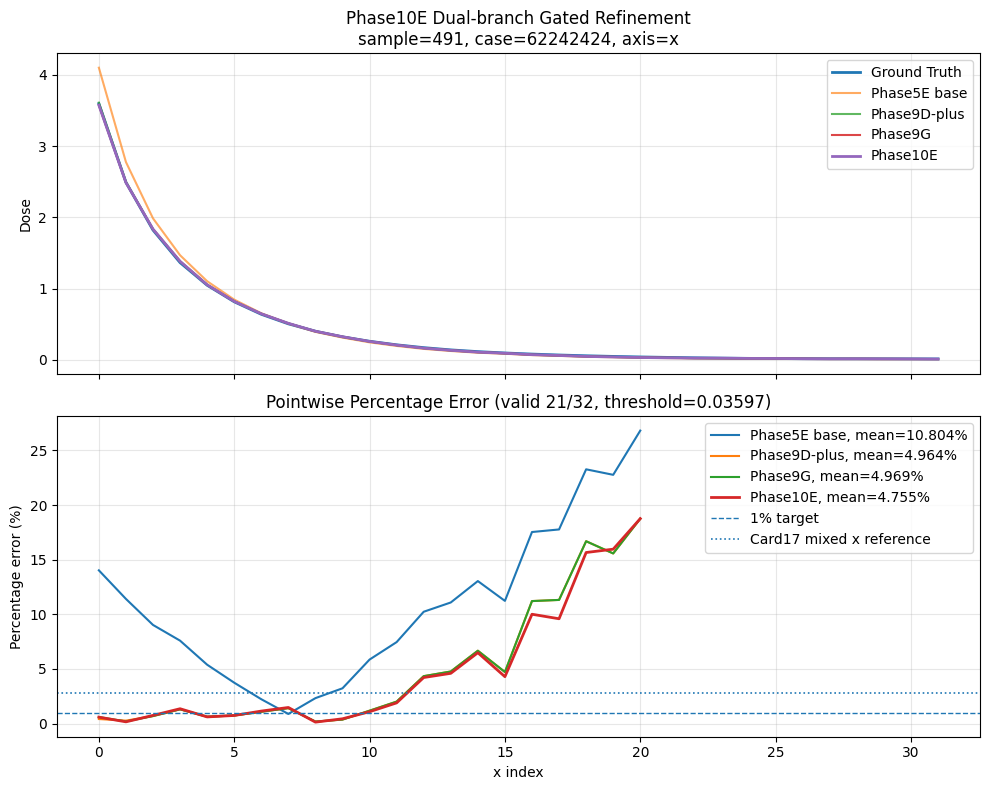

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10e_dual_branch_gated_refinement/sample0491_case62242424_axisx_phase10e_card17_style.png
Summary:
Base:     mean=10.8043%, max=26.8212%
Phase9D:  mean=4.9641%, max=18.7602%
Phase9G:  mean=4.9690%, max=18.7602%
Phase10E: mean=4.7554%, max=18.7602%


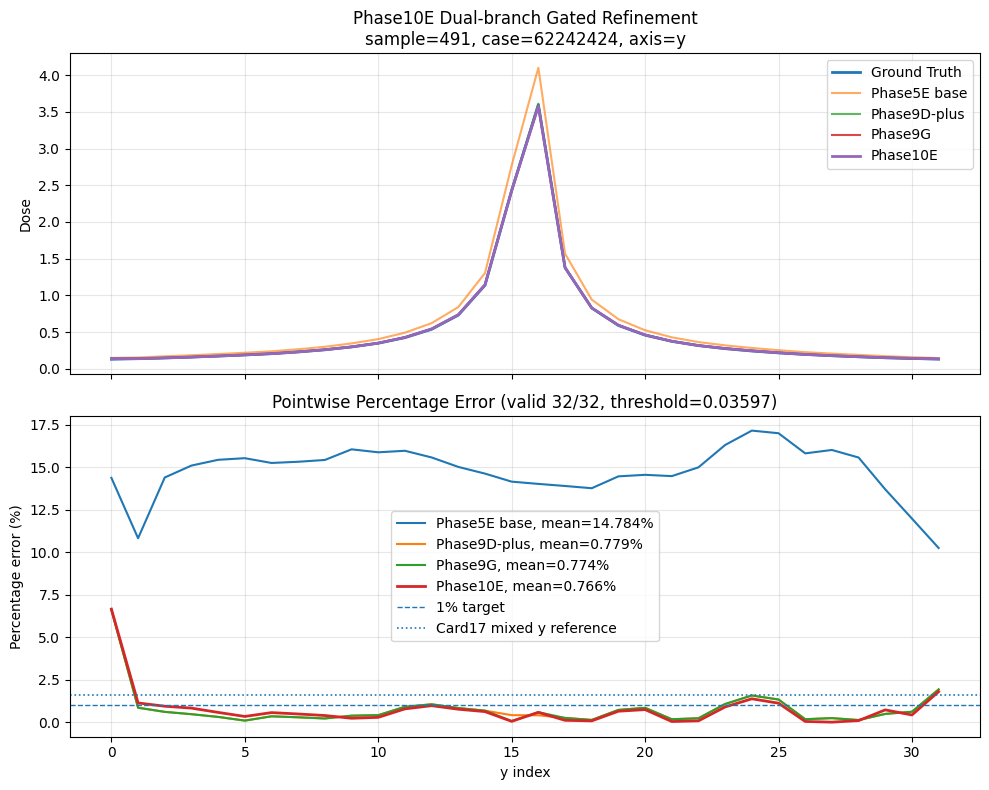

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10e_dual_branch_gated_refinement/sample0491_case62242424_axisy_phase10e_card17_style.png
Summary:
Base:     mean=14.7845%, max=17.1619%
Phase9D:  mean=0.7789%, max=6.6190%
Phase9G:  mean=0.7738%, max=6.6190%
Phase10E: mean=0.7658%, max=6.6600%


,method,source,along_x_mean_pct,perpendicular_y_mean_pct,delta_vs_card17_mixed_along_x,delta_vs_card17_mixed_perp_y
0,Card17 Phase4 mixed weighted,historical_card17_csv,2.774812,1.614564,0.000000,0.000000
1,Phase9G deployable,current_corrected_pipeline,4.969029,0.773800,2.194217,-0.840764
2,Phase10D falloff-aware,previous_best_direction_refinement,4.363384,0.770616,1.588572,-0.843948
3,Phase10E dual-branch gated,phase10e,4.755446,0.765824,1.980634,-0.848740


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase10e_dual_branch_gated_refinement/sample491_phase10e_vs_card17_summary.csv


In [ ]:
# ============================================================
# Run sample491 x/y evaluation for Phase10E
# ============================================================

result_491_x_10e = generate_card17_style_phase10e_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE10E_DIR,
)

result_491_y_10e = generate_card17_style_phase10e_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=PHASE10E_DIR,
)

phase10e_sample491_df = pd.DataFrame([
    {
        "method": "Card17 Phase4 mixed weighted",
        "source": "historical_card17_csv",
        "along_x_mean_pct": PHASE10E_CONFIG["card17_mixed_along_x"],
        "perpendicular_y_mean_pct": PHASE10E_CONFIG["card17_mixed_perp_y"],
    },
    {
        "method": "Phase9G deployable",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_10e["phase9g_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10e["phase9g_mean_pct"],
    },
    {
        "method": "Phase10D falloff-aware",
        "source": "previous_best_direction_refinement",
        "along_x_mean_pct": 4.363384,
        "perpendicular_y_mean_pct": 0.770616,
    },
    {
        "method": "Phase10E dual-branch gated",
        "source": "phase10e",
        "along_x_mean_pct": result_491_x_10e["phase10e_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_10e["phase10e_mean_pct"],
    },
])

phase10e_sample491_df["delta_vs_card17_mixed_along_x"] = (
    phase10e_sample491_df["along_x_mean_pct"]
    - PHASE10E_CONFIG["card17_mixed_along_x"]
)

phase10e_sample491_df["delta_vs_card17_mixed_perp_y"] = (
    phase10e_sample491_df["perpendicular_y_mean_pct"]
    - PHASE10E_CONFIG["card17_mixed_perp_y"]
)

display(phase10e_sample491_df)

phase10e_sample491_csv = PHASE10E_DIR / "sample491_phase10e_vs_card17_summary.csv"
phase10e_sample491_df.to_csv(phase10e_sample491_csv, index=False)

print("Saved:", phase10e_sample491_csv)

In [ ]:
# ============================================================
# Generate Phase10E Trello summary
# ============================================================

def _get_metric(df, method, col):
    return float(df.loc[df["method"] == method, col].iloc[0])


p9g_x = _get_metric(phase10e_sample491_df, "Phase9G deployable", "along_x_mean_pct")
p9g_y = _get_metric(phase10e_sample491_df, "Phase9G deployable", "perpendicular_y_mean_pct")

p10d_x = _get_metric(phase10e_sample491_df, "Phase10D falloff-aware", "along_x_mean_pct")
p10d_y = _get_metric(phase10e_sample491_df, "Phase10D falloff-aware", "perpendicular_y_mean_pct")

p10e_x = _get_metric(phase10e_sample491_df, "Phase10E dual-branch gated", "along_x_mean_pct")
p10e_y = _get_metric(phase10e_sample491_df, "Phase10E dual-branch gated", "perpendicular_y_mean_pct")

card17_x = PHASE10E_CONFIG["card17_mixed_along_x"]
card17_y = PHASE10E_CONFIG["card17_mixed_perp_y"]

text = f"""
Phase10E dual-branch gated refinement smoke test

Goal:
- Test whether a dual-branch gated refinement can further improve along-beam falloff while preserving Phase9G's perpendicular advantage.
- This extends Phase10D by separating an along-beam correction branch and a conservative safe branch, fused by a learned gate.

Design:
- Input: CT + Phase9G prediction + direction-aware features.
- Branch 1: along-beam/falloff correction.
- Branch 2: safe bounded correction.
- Gate: spatially controls how much along-branch correction is applied.
- Loss: along-beam profile/log/falloff losses + perpendicular no-worse + core no-worse + residual/smooth/gate regularization.

Card17 historical reference:
- along x: {card17_x:.3f}%
- perpendicular y: {card17_y:.3f}%

Phase9G:
- along x: {p9g_x:.3f}%
- perpendicular y: {p9g_y:.3f}%

Phase10D:
- along x: {p10d_x:.3f}%
- perpendicular y: {p10d_y:.3f}%

Phase10E:
- along x: {p10e_x:.3f}%
- perpendicular y: {p10e_y:.3f}%

Interpretation:
- If Phase10E further lowers along x while keeping y close to Phase9G/Phase10D, the dual-branch gating idea is promising.
- If Phase10E does not improve over Phase10D, then Phase10D remains the best current direction-aware refinement result.
"""

print(text)

summary_txt_10e = PHASE10E_DIR / "phase10e_trello_summary.txt"
with open(summary_txt_10e, "w") as f:
    f.write(text)

print("Saved:", summary_txt_10e)


Phase10E dual-branch gated refinement smoke test

Goal:
- Test whether a dual-branch gated refinement can further improve along-beam falloff while preserving Phase9G's perpendicular advantage.
- This extends Phase10D by separating an along-beam correction branch and a conservative safe branch, fused by a learned gate.

Design:
- Input: CT + Phase9G prediction + direction-aware features.
- Branch 1: along-beam/falloff correction.
- Branch 2: safe bounded correction.
- Gate: spatially controls how much along-branch correction is applied.
- Loss: along-beam profile/log/falloff losses + perpendicular no-worse + core no-worse + residual/smooth/gate regularization.

Card17 historical reference:
- along x: 2.775%
- perpendicular y: 1.615%

Phase9G:
- along x: 4.969%
- perpendicular y: 0.774%

Phase10D:
- along x: 4.363%
- perpendicular y: 0.771%

Phase10E:
- along x: 4.755%
- perpendicular y: 0.766%

Interpretation:
- If Phase10E further lowers along x while keeping y close to Phase9G/Phase1

In [ ]:
# ============================================================
# Add train_loader for Phase11A / training phases
# ============================================================

train_ds = CTDoseNpyDataset(TRAIN_JSON, dose_scale=DOSE_SCALE)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

batch = next(iter(train_loader))
print("train ct:", batch["ct"].shape, batch["ct"].min().item(), batch["ct"].max().item(), batch["ct"].mean().item())
print("train dose:", batch["dose"].shape, batch["dose"].min().item(), batch["dose"].max().item(), batch["dose"].mean().item())

Loaded 16000 records from /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
Dataset dose_scale: 1000.0
Train samples: 16000
Val samples: 4000
train ct: torch.Size([2, 1, 32, 32, 32]) 0.004603028297424316 1.0 0.3155195713043213
train dose: torch.Size([2, 1, 32, 32, 32]) 0.0007003135397098958 3.8320751190185547 0.04716796055436134


### 0. Phase11A Pre-flight check

In [ ]:
# ============================================================
# Phase11A Pre-flight check
# ============================================================

required_names = [
    "train_loader",
    "val_loader",
    "base_model",
    "model_9d_plus",
    "predict_phase9g",
    "extract_axis_profiles",
    "percentage_error_curve",
    "CONFIG",
    "PHASE9G_FINAL_DIR",
    "CHECKPOINT_DIR",
    "device",
]

missing = []
for name in required_names:
    if name not in globals():
        missing.append(name)

if missing:
    raise RuntimeError(f"Missing required variables/functions: {missing}")

print("Pre-flight check passed.")
print("CONFIG euler_steps:", CONFIG["euler_steps"])
print("CONFIG threshold_frac:", CONFIG.get("threshold_frac", "MISSING"))
print("Device:", device)

Pre-flight check passed.
CONFIG euler_steps: 10
CONFIG threshold_frac: 0.01
Device: cuda


### 1. Phase11A config

In [ ]:
# ============================================================
# Phase11A: WED-aware falloff-constrained bounded refinement
# ============================================================

from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PHASE11A_NAME = "ct2dose_phase11a_wed_aware_falloff_refinement"

PHASE11A_DIR = PHASE9G_FINAL_DIR / PHASE11A_NAME
PHASE11A_DIR.mkdir(parents=True, exist_ok=True)

PHASE11A_CKPT_DIR = CHECKPOINT_DIR
PHASE11A_CKPT_DIR.mkdir(parents=True, exist_ok=True)

PHASE11A_CONFIG = {
    "seed": 42,

    # smoke test first
    "epochs": 1,
    "lr": 4e-5,
    "weight_decay": 1e-5,
    "max_train_batches": 300,
    "eval_max_batches": 80,

    "euler_steps": int(CONFIG["euler_steps"]),

    # bounded correction
    "delta_scale": 0.008,

    # CT → approximate density
    "ct_norm_hu_offset": 1024.0,
    "ct_norm_hu_scale": 2048.0,
    "rho_min": 0.0,
    "rho_max": 2.2,
    "attenuation_beta": 2.0,

    # dose region thresholds
    "threshold_frac": float(CONFIG.get("threshold_frac", 0.01)),
    "main_frac": 0.30,
    "core_frac": 0.70,
    "shoulder_low": 0.30,
    "shoulder_high": 0.80,
    "falloff_low_frac": 0.05,
    "falloff_high_frac": 0.45,

    # protection
    "core_protect_strength": 0.82,
    "tail_protect_strength": 0.22,

    # losses
    "lambda_voxel": 0.35,
    "lambda_along": 1.8,
    "lambda_along_slope": 0.8,
    "lambda_along_log": 2.2,
    "lambda_falloff_log": 4.5,
    "lambda_wed_slope": 1.2,
    "lambda_falloff_no_worse": 4.0,
    "lambda_perp_no_worse": 7.0,
    "lambda_core_no_worse": 3.5,
    "lambda_residual_l1": 0.10,
    "lambda_smooth": 0.08,

    # margins
    "perp_margin_abs": 0.00035,
    "core_margin_abs": 0.00035,
    "falloff_margin_log": 0.012,

    # model
    "base_ch": 16,

    # references
    "card17_mixed_along_x": 2.774812,
    "card17_mixed_perp_y": 1.614564,
    "phase10d_along_x": 4.363384,
    "phase10d_perp_y": 0.770616,
}

torch.manual_seed(PHASE11A_CONFIG["seed"])
np.random.seed(PHASE11A_CONFIG["seed"])

print("PHASE11A_DIR:", PHASE11A_DIR)
print(json.dumps(PHASE11A_CONFIG, indent=2))

PHASE11A_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase11a_wed_aware_falloff_refinement
{
  "seed": 42,
  "epochs": 1,
  "lr": 4e-05,
  "weight_decay": 1e-05,
  "max_train_batches": 300,
  "eval_max_batches": 80,
  "euler_steps": 10,
  "delta_scale": 0.008,
  "ct_norm_hu_offset": 1024.0,
  "ct_norm_hu_scale": 2048.0,
  "rho_min": 0.0,
  "rho_max": 2.2,
  "attenuation_beta": 2.0,
  "threshold_frac": 0.01,
  "main_frac": 0.3,
  "core_frac": 0.7,
  "shoulder_low": 0.3,
  "shoulder_high": 0.8,
  "falloff_low_frac": 0.05,
  "falloff_high_frac": 0.45,
  "core_protect_strength": 0.82,
  "tail_protect_strength": 0.22,
  "lambda_voxel": 0.35,
  "lambda_along": 1.8,
  "lambda_along_slope": 0.8,
  "lambda_along_log": 2.2,
  "lambda_falloff_log": 4.5,
  "lambda_wed_slope": 1.2,
  "lambda_falloff_no_worse": 4.0,
  "lambda_perp_no_worse": 7.0,
  "lambda_core_no_worse": 3.5,
  "lambda_residual_l1": 0.1,


### 2. WED / cumulative attenuation feature builder

In [ ]:
# ============================================================
# Phase11A WED feature builder
# ============================================================

def estimate_relative_density_from_ct_norm(ct):
    """
    Approximate relative electron density from normalized CT.

    Assumption:
        ct_norm ~= (HU + 1024) / 2048

    Then:
        HU ~= ct_norm * 2048 - 1024
        rho_rel ~= 1 + HU / 1000

    This is a crude but physically meaningful feature.
    It is not meant to be a calibrated physics model.
    """
    hu = (
        ct * PHASE11A_CONFIG["ct_norm_hu_scale"]
        - PHASE11A_CONFIG["ct_norm_hu_offset"]
    )

    rho = 1.0 + hu / 1000.0

    rho = torch.clamp(
        rho,
        min=PHASE11A_CONFIG["rho_min"],
        max=PHASE11A_CONFIG["rho_max"],
    )

    return rho


def make_wed_features(ct):
    """
    Compute approximate WED-like cumulative density along x / D axis.

    Input:
        ct: [B,1,D,H,W]

    Returns:
        rho:              [B,1,D,H,W]
        wed_raw:          [B,1,D,H,W]
        wed_norm:         [B,1,D,H,W]
        attenuation_prior:[B,1,D,H,W]
    """
    rho = estimate_relative_density_from_ct_norm(ct)

    wed_raw = torch.cumsum(rho, dim=2)

    max_wed = wed_raw.flatten(1).max(dim=1).values.view(-1, 1, 1, 1, 1)
    wed_norm = wed_raw / torch.clamp(max_wed, min=1e-6)

    attenuation_prior = torch.exp(
        -PHASE11A_CONFIG["attenuation_beta"] * wed_norm
    )

    return rho, wed_raw, wed_norm, attenuation_prior


def make_coord_channels_like_11a(x):
    B, C, D, H, W = x.shape
    device = x.device
    dtype = x.dtype

    xd = torch.linspace(0.0, 1.0, D, device=device, dtype=dtype).view(1, 1, D, 1, 1)
    yy = torch.linspace(-1.0, 1.0, H, device=device, dtype=dtype).view(1, 1, 1, H, 1)
    zz = torch.linspace(-1.0, 1.0, W, device=device, dtype=dtype).view(1, 1, 1, 1, W)

    x_depth = xd.expand(B, 1, D, H, W)

    radial = torch.sqrt(yy ** 2 + zz ** 2)
    radial = radial / torch.clamp(radial.max(), min=1e-6)
    radial = radial.expand(B, 1, D, H, W)

    return x_depth, radial


def gradient_x_11a(v):
    gx = torch.zeros_like(v)

    if v.shape[2] > 2:
        gx[:, :, 1:-1] = 0.5 * (v[:, :, 2:] - v[:, :, :-2])
        gx[:, :, 0] = v[:, :, 1] - v[:, :, 0]
        gx[:, :, -1] = v[:, :, -1] - v[:, :, -2]

    return gx


def gradient_mag_3d_11a(v):
    gx = torch.zeros_like(v)
    gy = torch.zeros_like(v)
    gz = torch.zeros_like(v)

    if v.shape[2] > 2:
        gx[:, :, 1:-1] = 0.5 * (v[:, :, 2:] - v[:, :, :-2])

    if v.shape[3] > 2:
        gy[:, :, :, 1:-1] = 0.5 * (v[:, :, :, 2:] - v[:, :, :, :-2])

    if v.shape[4] > 2:
        gz[:, :, :, :, 1:-1] = 0.5 * (v[:, :, :, :, 2:] - v[:, :, :, :, :-2])

    return torch.sqrt(gx ** 2 + gy ** 2 + gz ** 2 + 1e-12)


def make_dose_region_features_11a(pred, eps=1e-6):
    B = pred.shape[0]
    maxv = pred.flatten(1).max(dim=1).values.view(B, 1, 1, 1, 1)
    rel = pred / torch.clamp(maxv, min=eps)

    main_mask = (rel > PHASE11A_CONFIG["main_frac"]).float()
    core_mask = (rel > PHASE11A_CONFIG["core_frac"]).float()

    shoulder_mask = (
        (rel > PHASE11A_CONFIG["shoulder_low"])
        & (rel <= PHASE11A_CONFIG["shoulder_high"])
    ).float()

    tail_mask = (
        (rel > 0.01)
        & (rel <= PHASE11A_CONFIG["main_frac"])
    ).float()

    falloff_pred_mask = (
        (rel >= PHASE11A_CONFIG["falloff_low_frac"])
        & (rel <= PHASE11A_CONFIG["falloff_high_frac"])
    ).float()

    return rel, main_mask, core_mask, shoulder_mask, tail_mask, falloff_pred_mask


def make_phase11a_features(ct, phase9g_pred):
    """
    Feature channels:
      0  ct
      1  phase9g_pred
      2  relative dose
      3  x_depth
      4  radial
      5  rho_rel
      6  wed_norm
      7  attenuation_prior
      8  main_mask
      9  core_mask
      10 shoulder_mask
      11 tail_mask
      12 falloff_pred_mask
      13 grad_x_pred
      14 grad_mag_pred
    """
    x_depth, radial = make_coord_channels_like_11a(phase9g_pred)
    rho, wed_raw, wed_norm, attenuation_prior = make_wed_features(ct)

    rel, main_mask, core_mask, shoulder_mask, tail_mask, falloff_pred_mask = (
        make_dose_region_features_11a(phase9g_pred)
    )

    gx = gradient_x_11a(phase9g_pred)
    gmag = gradient_mag_3d_11a(phase9g_pred)

    feat = torch.cat(
        [
            ct,
            phase9g_pred,
            rel,
            x_depth,
            radial,
            rho,
            wed_norm,
            attenuation_prior,
            main_mask,
            core_mask,
            shoulder_mask,
            tail_mask,
            falloff_pred_mask,
            gx,
            gmag,
        ],
        dim=1,
    )

    return feat

### 3. Phase11A model

In [ ]:
# ============================================================
# Phase11A model
# ============================================================

class WEDAwareFalloffRefineHead3D(nn.Module):
    def __init__(self, in_ch=15, base_ch=16, delta_scale=0.008):
        super().__init__()

        self.delta_scale = float(delta_scale)

        self.trunk = nn.Sequential(
            nn.Conv3d(in_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),

            nn.Conv3d(base_ch, base_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=base_ch),
            nn.SiLU(),
        )

        self.delta_head = nn.Conv3d(base_ch, 1, kernel_size=1)

    def forward(self, ct, phase9g_pred):
        feat = make_phase11a_features(ct, phase9g_pred)
        h = self.trunk(feat)

        raw_delta = self.delta_head(h)
        delta = self.delta_scale * torch.tanh(raw_delta)

        rel, main_mask, core_mask, shoulder_mask, tail_mask, falloff_pred_mask = (
            make_dose_region_features_11a(phase9g_pred)
        )

        # Region-aware mask:
        # Encourage correction in falloff/shoulder region,
        # protect core and avoid uncontrolled tail changes.
        core_protection = 1.0 - PHASE11A_CONFIG["core_protect_strength"] * core_mask
        tail_protection = 1.0 - PHASE11A_CONFIG["tail_protect_strength"] * tail_mask

        correction_region = torch.clamp(
            0.20 * main_mask
            + 0.65 * shoulder_mask
            + 0.80 * falloff_pred_mask
            + 0.25 * tail_mask,
            min=0.0,
            max=1.0,
        )

        correction_mask = correction_region * core_protection * tail_protection
        correction_mask = torch.clamp(correction_mask, min=0.0, max=1.0)

        bounded_delta = correction_mask * delta

        refined = phase9g_pred + bounded_delta
        refined = torch.clamp(refined, min=0.0)

        return refined, {
            "delta": bounded_delta,
            "raw_delta": raw_delta,
            "correction_mask": correction_mask,
        }


phase11a_model = WEDAwareFalloffRefineHead3D(
    in_ch=15,
    base_ch=PHASE11A_CONFIG["base_ch"],
    delta_scale=PHASE11A_CONFIG["delta_scale"],
).to(device)

optimizer11a = torch.optim.AdamW(
    phase11a_model.parameters(),
    lr=PHASE11A_CONFIG["lr"],
    weight_decay=PHASE11A_CONFIG["weight_decay"],
)

print(phase11a_model)

WEDAwareFalloffRefineHead3D(
  (trunk): Sequential(
    (0): Conv3d(15, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (2): SiLU()
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): GroupNorm(4, 16, eps=1e-05, affine=True)
    (5): SiLU()
    (6): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (7): GroupNorm(4, 16, eps=1e-05, affine=True)
    (8): SiLU()
    (9): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (10): GroupNorm(4, 16, eps=1e-05, affine=True)
    (11): SiLU()
  )
  (delta_head): Conv3d(16, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
)


### 4. Phase11A losses

In [ ]:
# ============================================================
# Phase11A losses
# ============================================================

def central_profiles_torch_11a(v):
    B, C, D, H, W = v.shape
    cx, cy, cz = D // 2, H // 2, W // 2

    px = v[:, 0, :, cy, cz]
    py = v[:, 0, cx, :, cz]
    pz = v[:, 0, cx, cy, :]

    return px, py, pz


def central_wed_profile_torch_11a(ct):
    """
    Return central WED normalized profile [B,D]
    """
    _, _, wed_norm, _ = make_wed_features(ct)

    B, C, D, H, W = wed_norm.shape
    cy, cz = H // 2, W // 2

    return wed_norm[:, 0, :, cy, cz]


def masked_profile_l1_11a(pred_p, gt_p, threshold_frac=0.01):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    err = torch.abs(pred_p - gt_p) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def profile_slope_l1_11a(pred_p, gt_p, threshold_frac=0.01):
    dp = pred_p[:, 1:] - pred_p[:, :-1]
    dg = gt_p[:, 1:] - gt_p[:, :-1]

    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv

    mask = ((gt_p[:, 1:] > thr) | (gt_p[:, :-1] > thr)).float()

    err = torch.abs(dp - dg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def no_worse_profile_loss_11a(new_p, old_p, gt_p, margin_abs=0.00035, threshold_frac=0.01):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    old_err = torch.abs(old_p - gt_p)
    new_err = torch.abs(new_p - gt_p)

    penalty = F.relu(new_err - old_err - margin_abs) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def log_profile_l1_11a(pred_p, gt_p, threshold_frac=0.01, eps=1e-4):
    maxv = gt_p.max(dim=1, keepdim=True).values
    thr = threshold_frac * maxv
    mask = (gt_p > thr).float()

    lp = torch.log(torch.clamp(pred_p, min=eps))
    lg = torch.log(torch.clamp(gt_p, min=eps))

    err = torch.abs(lp - lg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def falloff_mask_from_gt_profile_11a(gt_p):
    maxv = gt_p.max(dim=1, keepdim=True).values
    rel = gt_p / torch.clamp(maxv, min=1e-8)

    mask = (
        (rel >= PHASE11A_CONFIG["falloff_low_frac"])
        & (rel <= PHASE11A_CONFIG["falloff_high_frac"])
    ).float()

    return mask


def falloff_log_loss_11a(pred_x, gt_x, eps=1e-4):
    mask = falloff_mask_from_gt_profile_11a(gt_x)

    lp = torch.log(torch.clamp(pred_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    err = torch.abs(lp - lg) * mask
    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def falloff_no_worse_log_loss_11a(new_x, old_x, gt_x, eps=1e-4):
    mask = falloff_mask_from_gt_profile_11a(gt_x)

    ln = torch.log(torch.clamp(new_x, min=eps))
    lo = torch.log(torch.clamp(old_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    new_err = torch.abs(ln - lg)
    old_err = torch.abs(lo - lg)

    penalty = F.relu(
        new_err - old_err - PHASE11A_CONFIG["falloff_margin_log"]
    ) * mask

    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (penalty.sum(dim=1) / denom).mean()


def wed_slope_log_loss_11a(pred_x, gt_x, wed_x, eps=1e-4):
    """
    Compare d log(dose) / d WED along beam.
    This is the most physics-inspired part.
    """
    lp = torch.log(torch.clamp(pred_x, min=eps))
    lg = torch.log(torch.clamp(gt_x, min=eps))

    dlp = lp[:, 1:] - lp[:, :-1]
    dlg = lg[:, 1:] - lg[:, :-1]

    dw = wed_x[:, 1:] - wed_x[:, :-1]
    dw = torch.clamp(dw, min=1e-4)

    slope_p = dlp / dw
    slope_g = dlg / dw

    maxv = gt_x.max(dim=1, keepdim=True).values
    thr = PHASE11A_CONFIG["threshold_frac"] * maxv

    dose_mask = ((gt_x[:, 1:] > thr) | (gt_x[:, :-1] > thr)).float()
    falloff_mask = falloff_mask_from_gt_profile_11a(gt_x)
    falloff_pair_mask = torch.clamp(
        falloff_mask[:, 1:] + falloff_mask[:, :-1],
        min=0.0,
        max=1.0,
    )

    mask = dose_mask * falloff_pair_mask

    err = torch.abs(slope_p - slope_g) * mask

    # Robust clamp to avoid huge gradients from rare unstable points
    err = torch.clamp(err, max=10.0)

    denom = torch.clamp(mask.sum(dim=1), min=1.0)

    return (err.sum(dim=1) / denom).mean()


def smoothness_loss_3d_11a(delta):
    gx = torch.abs(delta[:, :, 1:] - delta[:, :, :-1]).mean()
    gy = torch.abs(delta[:, :, :, 1:] - delta[:, :, :, :-1]).mean()
    gz = torch.abs(delta[:, :, :, :, 1:] - delta[:, :, :, :, :-1]).mean()
    return gx + gy + gz


def phase11a_loss(refined, phase9g_pred, gt, ct, aux):
    voxel_l1 = torch.mean(torch.abs(refined - gt))

    new_x, new_y, new_z = central_profiles_torch_11a(refined)
    old_x, old_y, old_z = central_profiles_torch_11a(phase9g_pred)
    gt_x, gt_y, gt_z = central_profiles_torch_11a(gt)
    wed_x = central_wed_profile_torch_11a(ct)

    along_loss = masked_profile_l1_11a(
        new_x,
        gt_x,
        threshold_frac=PHASE11A_CONFIG["threshold_frac"],
    )

    along_slope = profile_slope_l1_11a(
        new_x,
        gt_x,
        threshold_frac=PHASE11A_CONFIG["threshold_frac"],
    )

    along_log = log_profile_l1_11a(
        new_x,
        gt_x,
        threshold_frac=PHASE11A_CONFIG["threshold_frac"],
    )

    falloff_log = falloff_log_loss_11a(new_x, gt_x)

    wed_slope = wed_slope_log_loss_11a(
        new_x,
        gt_x,
        wed_x,
    )

    falloff_noworse = falloff_no_worse_log_loss_11a(
        new_x,
        old_x,
        gt_x,
    )

    perp_noworse_y = no_worse_profile_loss_11a(
        new_y,
        old_y,
        gt_y,
        margin_abs=PHASE11A_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE11A_CONFIG["threshold_frac"],
    )

    perp_noworse_z = no_worse_profile_loss_11a(
        new_z,
        old_z,
        gt_z,
        margin_abs=PHASE11A_CONFIG["perp_margin_abs"],
        threshold_frac=PHASE11A_CONFIG["threshold_frac"],
    )

    perp_noworse = 0.5 * (perp_noworse_y + perp_noworse_z)

    rel_gt, main_mask, core_mask, shoulder_mask, tail_mask, falloff_pred_mask = (
        make_dose_region_features_11a(gt)
    )

    old_core_err = torch.abs(phase9g_pred - gt)
    new_core_err = torch.abs(refined - gt)

    core_penalty = F.relu(
        new_core_err - old_core_err - PHASE11A_CONFIG["core_margin_abs"]
    ) * core_mask

    core_noworse = core_penalty.sum() / torch.clamp(core_mask.sum(), min=1.0)

    residual_l1 = torch.mean(torch.abs(aux["delta"]))
    smooth = smoothness_loss_3d_11a(aux["delta"])

    total = (
        PHASE11A_CONFIG["lambda_voxel"] * voxel_l1
        + PHASE11A_CONFIG["lambda_along"] * along_loss
        + PHASE11A_CONFIG["lambda_along_slope"] * along_slope
        + PHASE11A_CONFIG["lambda_along_log"] * along_log
        + PHASE11A_CONFIG["lambda_falloff_log"] * falloff_log
        + PHASE11A_CONFIG["lambda_wed_slope"] * wed_slope
        + PHASE11A_CONFIG["lambda_falloff_no_worse"] * falloff_noworse
        + PHASE11A_CONFIG["lambda_perp_no_worse"] * perp_noworse
        + PHASE11A_CONFIG["lambda_core_no_worse"] * core_noworse
        + PHASE11A_CONFIG["lambda_residual_l1"] * residual_l1
        + PHASE11A_CONFIG["lambda_smooth"] * smooth
    )

    return total, {
        "total": total.detach().item(),
        "voxel_l1": voxel_l1.detach().item(),
        "along_loss": along_loss.detach().item(),
        "along_slope": along_slope.detach().item(),
        "along_log": along_log.detach().item(),
        "falloff_log": falloff_log.detach().item(),
        "wed_slope": wed_slope.detach().item(),
        "falloff_noworse": falloff_noworse.detach().item(),
        "perp_noworse": perp_noworse.detach().item(),
        "core_noworse": core_noworse.detach().item(),
        "residual_l1": residual_l1.detach().item(),
        "smooth": smooth.detach().item(),
    }

### 5. Prediction wrapper

In [ ]:
# ============================================================
# Phase11A prediction wrapper
# ============================================================

@torch.no_grad()
def predict_phase11a(ct, steps=None):
    if steps is None:
        steps = PHASE11A_CONFIG["euler_steps"]

    base_model.eval()
    model_9d_plus.eval()
    phase11a_model.eval()

    preds9 = predict_phase9g(ct, steps=steps)

    phase9g_pred = preds9["phase9g_pred"]

    refined, aux = phase11a_model(
        ct,
        phase9g_pred,
    )

    preds9["phase11a_pred"] = refined
    preds9["phase11a_aux"] = aux

    return preds9

### 6. Train / eval loops

In [ ]:
# ============================================================
# Phase11A train / eval loops
# ============================================================

def average_stats(stats_list):
    if len(stats_list) == 0:
        return {}

    keys = stats_list[0].keys()
    return {k: float(np.mean([s[k] for s in stats_list])) for k in keys}


def run_phase11a_train_epoch(epoch):
    phase11a_model.train()
    base_model.eval()
    model_9d_plus.eval()

    stats_list = []
    t0 = time.time()

    for batch_idx, batch in enumerate(train_loader):
        if batch_idx >= PHASE11A_CONFIG["max_train_batches"]:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        with torch.no_grad():
            preds9 = predict_phase9g(
                ct,
                steps=PHASE11A_CONFIG["euler_steps"],
            )
            phase9g_pred = preds9["phase9g_pred"]

        refined, aux = phase11a_model(ct, phase9g_pred)

        loss, stats = phase11a_loss(
            refined,
            phase9g_pred,
            gt,
            ct,
            aux,
        )

        optimizer11a.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(phase11a_model.parameters(), max_norm=1.0)
        optimizer11a.step()

        stats_list.append(stats)

        if (batch_idx + 1) % 50 == 0:
            avg = average_stats(stats_list[-50:])
            print(
                f"epoch {epoch} batch {batch_idx+1} | "
                f"loss={avg['total']:.6f} | "
                f"along={avg['along_loss']:.6f} | "
                f"falloff={avg['falloff_log']:.6f} | "
                f"wed={avg['wed_slope']:.6f} | "
                f"perpNW={avg['perp_noworse']:.6f} | "
                f"res={avg['residual_l1']:.6f}"
            )

    out = average_stats(stats_list)
    out["elapsed_min"] = (time.time() - t0) / 60.0

    return out


@torch.no_grad()
def evaluate_phase11a_profile_metrics(loader, max_batches=80):
    phase11a_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)

        preds9 = predict_phase9g(
            ct,
            steps=PHASE11A_CONFIG["euler_steps"],
        )

        phase9g_pred = preds9["phase9g_pred"]

        refined, aux = phase11a_model(ct, phase9g_pred)

        B = ct.shape[0]

        for b in range(B):
            p9_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
            p11_profiles = extract_axis_profiles(refined[b], gt[b])

            for axis in ["x", "y", "z"]:
                gt_p = p9_profiles[axis]["gt"]

                p9_p = p9_profiles[axis]["pred"]
                p11_p = p11_profiles[axis]["pred"]

                _, p9_mean, p9_max, valid_count, thr = percentage_error_curve(
                    p9_p,
                    gt_p,
                    threshold_frac=PHASE11A_CONFIG["threshold_frac"],
                )

                _, p11_mean, p11_max, _, _ = percentage_error_curve(
                    p11_p,
                    gt_p,
                    threshold_frac=PHASE11A_CONFIG["threshold_frac"],
                )

                rows.append({
                    "batch_idx": batch_idx,
                    "sample_local_idx": b,
                    "axis": axis,
                    "phase9g_mean_pct": p9_mean,
                    "phase11a_mean_pct": p11_mean,
                    "phase9g_max_pct": p9_max,
                    "phase11a_max_pct": p11_max,
                    "delta_mean_pct": p11_mean - p9_mean,
                    "valid_count": valid_count,
                    "threshold": thr,
                })

        if (batch_idx + 1) % 20 == 0:
            print(f"eval processed batches: {batch_idx+1}")

    casewise_df = pd.DataFrame(rows)

    summary_df = (
        casewise_df
        .groupby("axis")
        .agg(
            phase9g_mean_pct=("phase9g_mean_pct", "mean"),
            phase11a_mean_pct=("phase11a_mean_pct", "mean"),
            delta_mean_pct=("delta_mean_pct", "mean"),
            phase9g_max_pct=("phase9g_max_pct", "mean"),
            phase11a_max_pct=("phase11a_max_pct", "mean"),
        )
        .reset_index()
    )

    return casewise_df, summary_df

### 7. Train Phase11A

In [ ]:
# ============================================================
# Train Phase11A
# ============================================================

training_rows_11a = []
best_score_11a = float("inf")
best_epoch_11a = None

best_ckpt_path_11a = PHASE11A_CKPT_DIR / f"{PHASE11A_NAME}_seed42_best.pt"
latest_ckpt_path_11a = PHASE11A_CKPT_DIR / f"{PHASE11A_NAME}_seed42_latest.pt"

for epoch in range(1, PHASE11A_CONFIG["epochs"] + 1):
    print("=" * 100)
    print(f"Phase11A Epoch {epoch}/{PHASE11A_CONFIG['epochs']}")

    train_stats = run_phase11a_train_epoch(epoch)

    val_casewise, val_summary = evaluate_phase11a_profile_metrics(
        val_loader,
        max_batches=PHASE11A_CONFIG["eval_max_batches"],
    )

    display(val_summary)

    x_row = val_summary[val_summary["axis"] == "x"].iloc[0]
    y_row = val_summary[val_summary["axis"] == "y"].iloc[0]
    z_row = val_summary[val_summary["axis"] == "z"].iloc[0]

    score = (
        x_row["phase11a_mean_pct"]
        + 5.0 * max(0.0, y_row["phase11a_mean_pct"] - y_row["phase9g_mean_pct"])
        + 5.0 * max(0.0, z_row["phase11a_mean_pct"] - z_row["phase9g_mean_pct"])
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_stats.items()},
        "score": float(score),
    }

    for _, r in val_summary.iterrows():
        axis = r["axis"]
        row[f"val_{axis}_phase9g_mean_pct"] = r["phase9g_mean_pct"]
        row[f"val_{axis}_phase11a_mean_pct"] = r["phase11a_mean_pct"]
        row[f"val_{axis}_delta_mean_pct"] = r["delta_mean_pct"]

    training_rows_11a.append(row)

    log_df_11a = pd.DataFrame(training_rows_11a)
    display(log_df_11a.tail(1))

    torch.save(
        {
            "model_state_dict": phase11a_model.state_dict(),
            "optimizer_state_dict": optimizer11a.state_dict(),
            "config": PHASE11A_CONFIG,
            "epoch": epoch,
            "row": row,
        },
        latest_ckpt_path_11a,
    )

    if score < best_score_11a:
        best_score_11a = float(score)
        best_epoch_11a = epoch

        torch.save(
            {
                "model_state_dict": phase11a_model.state_dict(),
                "optimizer_state_dict": optimizer11a.state_dict(),
                "config": PHASE11A_CONFIG,
                "epoch": epoch,
                "row": row,
                "best_score": best_score_11a,
            },
            best_ckpt_path_11a,
        )

        print(f"New best saved: epoch={epoch}, score={best_score_11a:.6f}")

training_log_df_11a = pd.DataFrame(training_rows_11a)

training_log_csv_11a = PHASE11A_DIR / f"{PHASE11A_NAME}_training_log.csv"
training_log_df_11a.to_csv(training_log_csv_11a, index=False)

print("Finished Phase11A.")
print("Best epoch:", best_epoch_11a)
print("Best score:", best_score_11a)
print("Saved:", training_log_csv_11a)
print("Best ckpt:", best_ckpt_path_11a)

Phase11A Epoch 1/1
epoch 1 batch 50 | loss=5.466773 | along=0.003430 | falloff=0.116113 | wed=3.896792 | perpNW=0.000411 | res=0.000461
epoch 1 batch 100 | loss=5.678812 | along=0.003157 | falloff=0.123859 | wed=4.048177 | perpNW=0.000190 | res=0.000320
epoch 1 batch 150 | loss=5.833600 | along=0.003297 | falloff=0.119821 | wed=4.195399 | perpNW=0.000115 | res=0.000335
epoch 1 batch 200 | loss=5.680806 | along=0.003023 | falloff=0.122045 | wed=4.055881 | perpNW=0.000135 | res=0.000310
epoch 1 batch 250 | loss=5.073231 | along=0.002838 | falloff=0.114381 | wed=3.603821 | perpNW=0.000101 | res=0.000301
epoch 1 batch 300 | loss=5.961977 | along=0.003098 | falloff=0.120612 | wed=4.304166 | perpNW=0.000081 | res=0.000324
eval processed batches: 20
eval processed batches: 40
eval processed batches: 60
eval processed batches: 80


,axis,phase9g_mean_pct,phase11a_mean_pct,delta_mean_pct,phase9g_max_pct,phase11a_max_pct
0,x,8.032640,7.856574,-0.176066,24.204922,24.009644
1,y,2.641446,2.632334,-0.009112,10.302707,9.985480
2,z,2.595759,2.557490,-0.038269,9.282511,9.058223


,epoch,train_total,train_voxel_l1,train_along_loss,train_along_slope,train_along_log,train_falloff_log,train_wed_slope,train_falloff_noworse,train_perp_noworse,...,score,val_x_phase9g_mean_pct,val_x_phase11a_mean_pct,val_x_delta_mean_pct,val_y_phase9g_mean_pct,val_y_phase11a_mean_pct,val_y_delta_mean_pct,val_z_phase9g_mean_pct,val_z_phase11a_mean_pct,val_z_delta_mean_pct
0,1,5.615866,0.003068,0.003141,0.002332,0.111978,0.119472,4.017373,0.000292,0.000172,...,7.856574,8.03264,7.856574,-0.176066,2.641446,2.632334,-0.009112,2.595759,2.55749,-0.038269


New best saved: epoch=1, score=7.856574
Finished Phase11A.
Best epoch: 1
Best score: 7.856574142882401
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase11a_wed_aware_falloff_refinement/ct2dose_phase11a_wed_aware_falloff_refinement_training_log.csv
Best ckpt: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase11a_wed_aware_falloff_refinement_seed42_best.pt


### 8. Load best checkpoint

In [ ]:
# ============================================================
# Load best Phase11A checkpoint
# ============================================================

best_ckpt_11a = torch.load(best_ckpt_path_11a, map_location=device)

phase11a_model.load_state_dict(best_ckpt_11a["model_state_dict"], strict=True)
phase11a_model.eval()

print("Loaded best Phase11A checkpoint:")
print(best_ckpt_path_11a)
print("Best epoch:", best_ckpt_11a.get("epoch"))
print("Best score:", best_ckpt_11a.get("best_score"))

Loaded best Phase11A checkpoint:
/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase11a_wed_aware_falloff_refinement_seed42_best.pt
Best epoch: 1
Best score: 7.856574142882401


### 9. Card17-style figure for Phase11A

In [ ]:
# ============================================================
# Generate Card17-style Phase11A figure
# ============================================================

@torch.no_grad()
def generate_card17_style_phase11a_figure(
    loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE11A_DIR,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    phase11a_model.eval()
    base_model.eval()
    model_9d_plus.eval()

    global_idx = 0

    for batch_idx, batch in enumerate(loader):
        ct = batch["ct"].to(device, non_blocking=True)
        gt = batch["dose"].to(device, non_blocking=True)
        case_ids = batch.get("case_id", ["unknown"] * ct.shape[0])

        preds9 = predict_phase9g(ct, steps=PHASE11A_CONFIG["euler_steps"])

        base_pred = preds9["base_pred"]
        phase9d_pred = preds9["phase9d_pred"]
        phase9g_pred = preds9["phase9g_pred"]

        phase11a_pred, aux = phase11a_model(ct, phase9g_pred)

        for b in range(ct.shape[0]):
            if global_idx == sample_index_to_plot:
                case_id = case_ids[b] if isinstance(case_ids, list) else str(case_ids[b])

                base_profiles = extract_axis_profiles(base_pred[b], gt[b])
                phase9d_profiles = extract_axis_profiles(phase9d_pred[b], gt[b])
                phase9g_profiles = extract_axis_profiles(phase9g_pred[b], gt[b])
                phase11a_profiles = extract_axis_profiles(phase11a_pred[b], gt[b])

                gt_p = phase9g_profiles[axis_to_plot]["gt"]

                base_p = base_profiles[axis_to_plot]["pred"]
                phase9d_p = phase9d_profiles[axis_to_plot]["pred"]
                phase9g_p = phase9g_profiles[axis_to_plot]["pred"]
                phase11a_p = phase11a_profiles[axis_to_plot]["pred"]

                base_pct, base_mean, base_max, valid_count, thr = percentage_error_curve(
                    base_p,
                    gt_p,
                    threshold_frac=PHASE11A_CONFIG["threshold_frac"],
                )

                phase9d_pct, phase9d_mean, phase9d_max, _, _ = percentage_error_curve(
                    phase9d_p,
                    gt_p,
                    threshold_frac=PHASE11A_CONFIG["threshold_frac"],
                )

                phase9g_pct, phase9g_mean, phase9g_max, _, _ = percentage_error_curve(
                    phase9g_p,
                    gt_p,
                    threshold_frac=PHASE11A_CONFIG["threshold_frac"],
                )

                phase11a_pct, phase11a_mean, phase11a_max, _, _ = percentage_error_curve(
                    phase11a_p,
                    gt_p,
                    threshold_frac=PHASE11A_CONFIG["threshold_frac"],
                )

                x = np.arange(len(gt_p))

                fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

                axes[0].plot(x, gt_p, label="Ground Truth", linewidth=2)
                axes[0].plot(x, base_p, label="Phase5E base", alpha=0.65)
                axes[0].plot(x, phase9d_p, label="Phase9D-plus", alpha=0.75)
                axes[0].plot(x, phase9g_p, label="Phase9G", alpha=0.85)
                axes[0].plot(x, phase11a_p, label="Phase11A WED-aware", linewidth=2)

                axes[0].set_title(
                    f"Phase11A WED-aware Falloff Refinement\n"
                    f"sample={sample_index_to_plot}, case={str(case_id)[:8]}, axis={axis_to_plot}"
                )
                axes[0].set_ylabel("Dose")
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                axes[1].plot(x, base_pct, label=f"Phase5E base, mean={base_mean:.3f}%")
                axes[1].plot(x, phase9d_pct, label=f"Phase9D-plus, mean={phase9d_mean:.3f}%")
                axes[1].plot(x, phase9g_pct, label=f"Phase9G, mean={phase9g_mean:.3f}%")
                axes[1].plot(x, phase11a_pct, label=f"Phase11A, mean={phase11a_mean:.3f}%", linewidth=2)

                axes[1].axhline(1.0, linestyle="--", linewidth=1, label="1% target")

                if axis_to_plot == "x":
                    axes[1].axhline(
                        PHASE11A_CONFIG["card17_mixed_along_x"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed x reference",
                    )

                if axis_to_plot == "y":
                    axes[1].axhline(
                        PHASE11A_CONFIG["card17_mixed_perp_y"],
                        linestyle=":",
                        linewidth=1.2,
                        label="Card17 mixed y reference",
                    )

                axes[1].set_title(
                    f"Pointwise Percentage Error "
                    f"(valid {valid_count}/{len(gt_p)}, threshold={thr:.5f})"
                )
                axes[1].set_xlabel(f"{axis_to_plot} index")
                axes[1].set_ylabel("Percentage error (%)")
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                fig.tight_layout()

                out_path = save_dir / (
                    f"sample{sample_index_to_plot:04d}_case{str(case_id)[:8]}"
                    f"_axis{axis_to_plot}_phase11a_card17_style.png"
                )

                fig.savefig(out_path, dpi=220, bbox_inches="tight")
                plt.show()

                print("Saved:", out_path)
                print("Summary:")
                print(f"Base:     mean={base_mean:.4f}%, max={base_max:.4f}%")
                print(f"Phase9D:  mean={phase9d_mean:.4f}%, max={phase9d_max:.4f}%")
                print(f"Phase9G:  mean={phase9g_mean:.4f}%, max={phase9g_max:.4f}%")
                print(f"Phase11A: mean={phase11a_mean:.4f}%, max={phase11a_max:.4f}%")

                return {
                    "path": out_path,
                    "sample_idx": sample_index_to_plot,
                    "case_id": case_id,
                    "axis": axis_to_plot,
                    "base_mean_pct": base_mean,
                    "phase9d_mean_pct": phase9d_mean,
                    "phase9g_mean_pct": phase9g_mean,
                    "phase11a_mean_pct": phase11a_mean,
                    "base_max_pct": base_max,
                    "phase9d_max_pct": phase9d_max,
                    "phase9g_max_pct": phase9g_max,
                    "phase11a_max_pct": phase11a_max,
                }

            global_idx += 1

    raise ValueError(f"sample_index_to_plot={sample_index_to_plot} not found.")

### 10. Run sample491 x/y evaluation

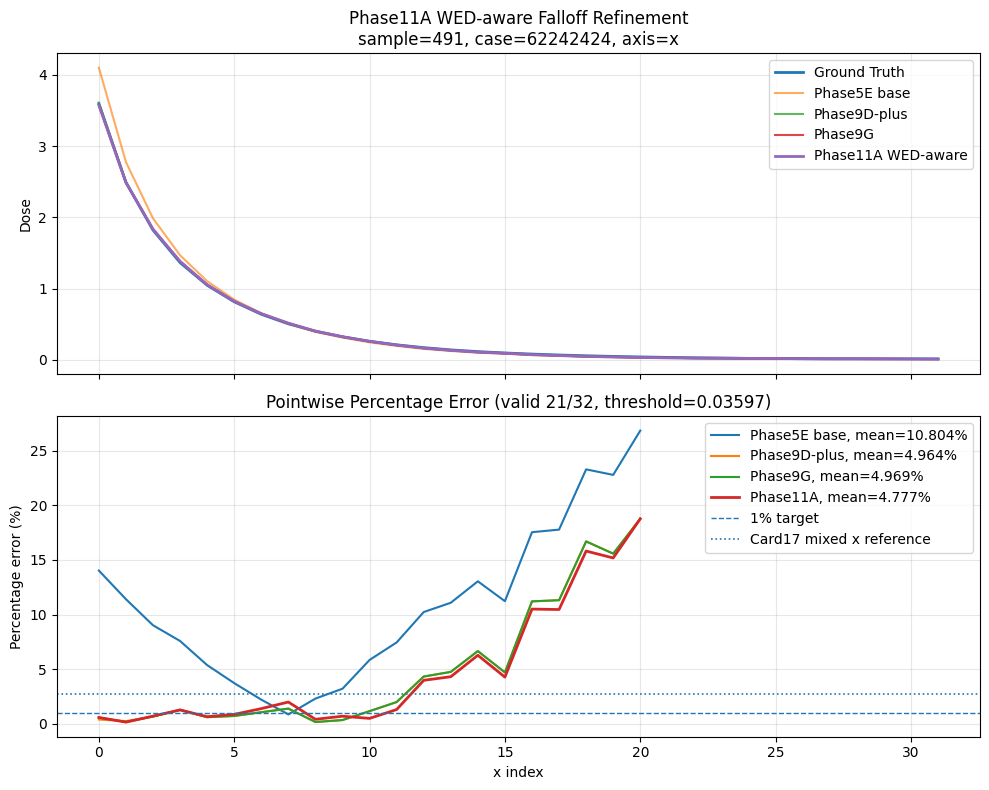

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase11a_wed_aware_falloff_refinement/sample0491_case62242424_axisx_phase11a_card17_style.png
Summary:
Base:     mean=10.8043%, max=26.8212%
Phase9D:  mean=4.9641%, max=18.7602%
Phase9G:  mean=4.9690%, max=18.7602%
Phase11A: mean=4.7770%, max=18.7602%


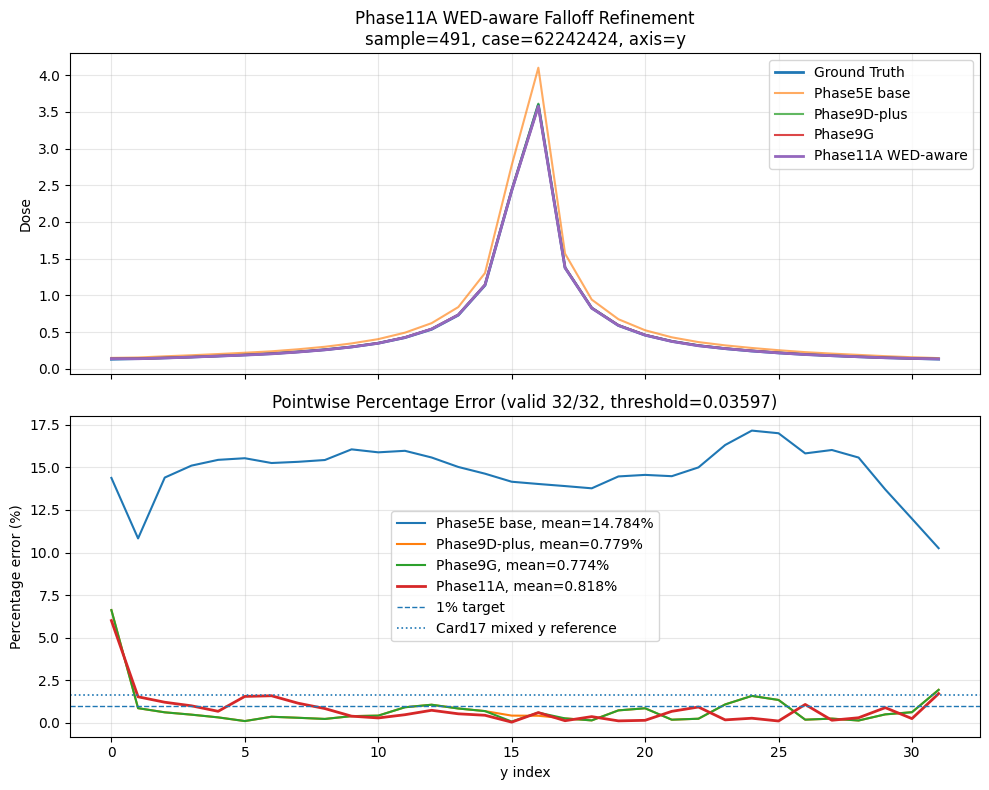

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase11a_wed_aware_falloff_refinement/sample0491_case62242424_axisy_phase11a_card17_style.png
Summary:
Base:     mean=14.7845%, max=17.1619%
Phase9D:  mean=0.7789%, max=6.6190%
Phase9G:  mean=0.7738%, max=6.6190%
Phase11A: mean=0.8181%, max=6.0022%


,method,source,along_x_mean_pct,perpendicular_y_mean_pct,delta_vs_card17_mixed_along_x,delta_vs_card17_mixed_perp_y
0,Card17 Phase4 mixed weighted,historical_card17_csv,2.774812,1.614564,0.000000,0.000000
1,Phase9G deployable,current_corrected_pipeline,4.969029,0.773800,2.194217,-0.840764
2,Phase10D falloff-aware,previous_best_direction_refinement,4.363384,0.770616,1.588572,-0.843948
3,Phase11A WED-aware,phase11a,4.776968,0.818125,2.002156,-0.796439


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase9g_deployable_core_calibration/final_card17_style_figures/ct2dose_phase11a_wed_aware_falloff_refinement/sample491_phase11a_vs_card17_summary.csv


In [ ]:
# ============================================================
# Run sample491 x/y evaluation for Phase11A
# ============================================================

result_491_x_11a = generate_card17_style_phase11a_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="x",
    save_dir=PHASE11A_DIR,
)

result_491_y_11a = generate_card17_style_phase11a_figure(
    val_loader,
    sample_index_to_plot=491,
    axis_to_plot="y",
    save_dir=PHASE11A_DIR,
)

phase11a_sample491_df = pd.DataFrame([
    {
        "method": "Card17 Phase4 mixed weighted",
        "source": "historical_card17_csv",
        "along_x_mean_pct": PHASE11A_CONFIG["card17_mixed_along_x"],
        "perpendicular_y_mean_pct": PHASE11A_CONFIG["card17_mixed_perp_y"],
    },
    {
        "method": "Phase9G deployable",
        "source": "current_corrected_pipeline",
        "along_x_mean_pct": result_491_x_11a["phase9g_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_11a["phase9g_mean_pct"],
    },
    {
        "method": "Phase10D falloff-aware",
        "source": "previous_best_direction_refinement",
        "along_x_mean_pct": PHASE11A_CONFIG["phase10d_along_x"],
        "perpendicular_y_mean_pct": PHASE11A_CONFIG["phase10d_perp_y"],
    },
    {
        "method": "Phase11A WED-aware",
        "source": "phase11a",
        "along_x_mean_pct": result_491_x_11a["phase11a_mean_pct"],
        "perpendicular_y_mean_pct": result_491_y_11a["phase11a_mean_pct"],
    },
])

phase11a_sample491_df["delta_vs_card17_mixed_along_x"] = (
    phase11a_sample491_df["along_x_mean_pct"]
    - PHASE11A_CONFIG["card17_mixed_along_x"]
)

phase11a_sample491_df["delta_vs_card17_mixed_perp_y"] = (
    phase11a_sample491_df["perpendicular_y_mean_pct"]
    - PHASE11A_CONFIG["card17_mixed_perp_y"]
)

display(phase11a_sample491_df)

phase11a_sample491_csv = PHASE11A_DIR / "sample491_phase11a_vs_card17_summary.csv"
phase11a_sample491_df.to_csv(phase11a_sample491_csv, index=False)

print("Saved:", phase11a_sample491_csv)

### 11. Trello summary

In [ ]:
# ============================================================
# Generate Phase11A Trello summary
# ============================================================

def _get_metric(df, method, col):
    return float(df.loc[df["method"] == method, col].iloc[0])


p9g_x = _get_metric(phase11a_sample491_df, "Phase9G deployable", "along_x_mean_pct")
p9g_y = _get_metric(phase11a_sample491_df, "Phase9G deployable", "perpendicular_y_mean_pct")

p10d_x = _get_metric(phase11a_sample491_df, "Phase10D falloff-aware", "along_x_mean_pct")
p10d_y = _get_metric(phase11a_sample491_df, "Phase10D falloff-aware", "perpendicular_y_mean_pct")

p11_x = _get_metric(phase11a_sample491_df, "Phase11A WED-aware", "along_x_mean_pct")
p11_y = _get_metric(phase11a_sample491_df, "Phase11A WED-aware", "perpendicular_y_mean_pct")

card17_x = PHASE11A_CONFIG["card17_mixed_along_x"]
card17_y = PHASE11A_CONFIG["card17_mixed_perp_y"]

text = f"""
Phase11A WED-aware falloff-constrained refinement smoke test

Motivation:
- The remaining along-beam issue is likely a path-integral / material attenuation problem.
- Phase10D used x-depth and falloff-aware log-profile losses, but it did not explicitly model upstream material path.
- Phase11A adds approximate water-equivalent depth (WED) and attenuation-prior features derived from CT.

Design:
- Input: CT + Phase9G prediction + direction-aware + WED-aware features.
- Added WED features:
  - approximate relative density from normalized CT
  - cumulative density along x
  - normalized WED
  - attenuation prior exp(-beta * WED)
- Output: small bounded residual added to Phase9G.
- Loss:
  - along-beam profile loss
  - along-beam log-profile loss
  - falloff-region log loss
  - WED-normalized log-slope loss
  - falloff no-worse
  - perpendicular no-worse
  - core no-worse

Card17 historical reference:
- along x: {card17_x:.3f}%
- perpendicular y: {card17_y:.3f}%

Phase9G:
- along x: {p9g_x:.3f}%
- perpendicular y: {p9g_y:.3f}%

Phase10D:
- along x: {p10d_x:.3f}%
- perpendicular y: {p10d_y:.3f}%

Phase11A:
- along x: {p11_x:.3f}%
- perpendicular y: {p11_y:.3f}%

Interpretation:
- If Phase11A improves over Phase10D on along x while preserving perpendicular y, WED-aware path information is helpful.
- If Phase11A does not improve over Phase10D, then the current approximate WED feature or WED-slope loss needs refinement.
"""

print(text)

summary_txt_11a = PHASE11A_DIR / "phase11a_trello_summary.txt"
with open(summary_txt_11a, "w") as f:
    f.write(text)

print("Saved:", summary_txt_11a)


Phase11A WED-aware falloff-constrained refinement smoke test

Motivation:
- The remaining along-beam issue is likely a path-integral / material attenuation problem.
- Phase10D used x-depth and falloff-aware log-profile losses, but it did not explicitly model upstream material path.
- Phase11A adds approximate water-equivalent depth (WED) and attenuation-prior features derived from CT.

Design:
- Input: CT + Phase9G prediction + direction-aware + WED-aware features.
- Added WED features:
  - approximate relative density from normalized CT
  - cumulative density along x
  - normalized WED
  - attenuation prior exp(-beta * WED)
- Output: small bounded residual added to Phase9G.
- Loss:
  - along-beam profile loss
  - along-beam log-profile loss
  - falloff-region log loss
  - WED-normalized log-slope loss
  - falloff no-worse
  - perpendicular no-worse
  - core no-worse

Card17 historical reference:
- along x: 2.775%
- perpendicular y: 1.615%

Phase9G:
- along x: 4.969%
- perpendicular y